# Predictive Occupant Scheduling via Transformer-Based Forecasting

This notebook uses the LBNL Berkeley Office Building Dataset in `doi_10_7941_D1N33Q__v20220202` to forecast future occupancy probability sequences for the south zones of Building 59.

The executed workflow is:

1. Load the full available occupancy-labeled period from LBNL Building 59.
2. Convert raw timestamps from the audited UTC assumption to Berkeley local Pacific Time before generating hour/day features.
3. Resample occupancy, WiFi, weather, temperature, and electricity data to 15-minute intervals using leakage-safe preprocessing.
4. Predict the next 24 hours of occupancy probability, i.e. 96 future intervals.
5. Compare a deliberately fair main model set: Historical Average, LightGBM, Random Forest, DLinear, and Transformer.
6. Evaluate all recommendation metrics with `Empty=1` as the positive class.
7. Report dense threshold sweeps, constrained risk policies, continuous empty-window metrics, conservative controllable-load opportunity estimates, rolling-origin temporal validation, and leave-one-zone-out spatial validation.

TFT and PatchTST are not used in the main comparison in this revised notebook. They are recorded as appendix candidates because a fair full-library comparison would require a separate tuning budget and consistent exogenous-variable setup.

Important dataset note: `occ.csv` contains occupancy labels from 2018-05-22 07:00:00 to 2019-02-21 10:12:00. The notebook uses this full labeled period and aligns all other sensor streams to it. `zone_co2.csv` starts later than the occupancy labels, so CO2 is excluded automatically unless enough overlap exists.


In [1]:
import json
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Image, Markdown, display
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

@dataclass
class Config:
    data_dir: str = 'doi_10_7941_D1N33Q__v20220202/Building_59/Bldg59_clean data'
    figure_dir: str = 'figures'
    result_dir: str = 'results'
    raw_timestamp_timezone: str = 'UTC'
    local_timezone: str = 'America/Los_Angeles'
    freq: str = '15min'
    history_steps: int = 96
    horizon_steps: int = 96
    forecast_stride: int = 1
    train_fraction: float = 0.70
    val_fraction: float = 0.15
    split_gap_steps: int = 96
    occupied_count_threshold: float = 0.0
    default_empty_threshold: float = 0.65
    stable_empty_min_steps: int = 4
    threshold_min: float = 0.05
    threshold_max: float = 0.95
    threshold_step: float = 0.025
    risk_deltas: tuple = (0.05, 0.10, 0.20)
    main_models: tuple = ('Historical average', 'LightGBM', 'Random forest', 'DLinear', 'Transformer')
    random_seeds: tuple = (42, 43, 44)
    tabular_max_train_rows: int = 200_000
    rf_estimators: int = 70
    lgbm_estimators: int = 320
    permutation_sample_rows: int = 30_000
    bootstrap_reps: int = 200
    deep_epochs: int = 12
    early_stop_patience: int = 4
    batch_size: int = 256
    d_model: int = 32
    n_heads: int = 4
    n_layers: int = 1
    dropout: float = 0.10
    learning_rate: float = 1e-3

cfg = Config()
Path(cfg.figure_dir).mkdir(exist_ok=True)
Path(cfg.result_dir).mkdir(exist_ok=True)
Path('predictions').mkdir(exist_ok=True)

random.seed(cfg.random_seeds[0])
np.random.seed(cfg.random_seeds[0])
torch.manual_seed(cfg.random_seeds[0])
torch.set_num_threads(min(8, os.cpu_count() or 1))

with open(Path(cfg.result_dir) / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(asdict(cfg), f, indent=2)

print('Torch:', torch.__version__, 'device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('Timestamp assumption:', cfg.raw_timestamp_timezone, '->', cfg.local_timezone)
print('Main models:', ', '.join(cfg.main_models))
print('LightGBM available:', LGBMClassifier is not None)

Torch: 2.11.0+cpu device: cpu
Timestamp assumption: UTC -> America/Los_Angeles
Main models: Historical average, LightGBM, Random forest, DLinear, Transformer
LightGBM available: True


In [2]:
def read_timeseries(path, cfg):
    raw = pd.read_csv(path)
    if 'date' not in raw.columns:
        raw = raw.rename(columns={raw.columns[0]: 'date'})
    raw = raw.loc[:, [c for c in raw.columns if not str(c).startswith('Unnamed')]]
    dt = pd.to_datetime(raw['date'], errors='coerce')
    raw = raw.loc[dt.notna()].copy()
    dt = dt.loc[dt.notna()]
    # The cleaned LBNL streams are stored as naive timestamps. Solar radiation peaks only
    # after interpreting them as UTC and converting to Berkeley local time, so all streams
    # are parsed as UTC and then converted to Pacific Time for feature generation.
    raw['date'] = dt.dt.tz_localize(cfg.raw_timestamp_timezone).dt.tz_convert(cfg.local_timezone)
    for col in raw.columns:
        if col != 'date':
            raw[col] = pd.to_numeric(raw[col], errors='coerce')
    return raw.sort_values('date')


def resample_mean(df, freq):
    return df.set_index('date').sort_index().resample(freq).mean()


def make_timezone_audit(cfg):
    p = Path(cfg.data_dir) / 'site_weather.csv'
    weather = pd.read_csv(p, usecols=['date', 'solar_radiation_set_1'])
    raw_dt = pd.to_datetime(weather['date'], errors='coerce')
    weather = weather.loc[raw_dt.notna()].copy()
    raw_dt = raw_dt.loc[raw_dt.notna()]
    weather['raw_hour'] = raw_dt.dt.hour
    local_dt = raw_dt.dt.tz_localize(cfg.raw_timestamp_timezone).dt.tz_convert(cfg.local_timezone)
    weather['local_hour_if_raw_utc'] = local_dt.dt.hour
    sample = weather[(raw_dt >= pd.Timestamp('2018-05-22')) & (raw_dt < pd.Timestamp('2018-06-22'))]
    hour_rows = []
    for mode, col in [('raw_timestamp_hour', 'raw_hour'), ('utc_to_pacific_hour', 'local_hour_if_raw_utc')]:
        prof = sample.groupby(col)['solar_radiation_set_1'].mean()
        for hour, value in prof.items():
            hour_rows.append({'profile': mode, 'hour': int(hour), 'mean_solar_radiation': float(value)})
    hour_df = pd.DataFrame(hour_rows)
    raw_peak = hour_df[hour_df['profile'] == 'raw_timestamp_hour'].sort_values('mean_solar_radiation', ascending=False).iloc[0]
    local_peak = hour_df[hour_df['profile'] == 'utc_to_pacific_hour'].sort_values('mean_solar_radiation', ascending=False).iloc[0]
    audit = pd.DataFrame([
        {
            'check': 'source_documentation_timezone',
            'status': 'not_explicitly_stated',
            'evidence': 'README and metadata identify Berkeley, CA but do not explicitly state timestamp timezone.',
        },
        {
            'check': 'solar_radiation_peak_test',
            'status': 'supports_raw_utc',
            'evidence': f"Raw timestamp solar peak is around hour {int(raw_peak['hour'])}; after UTC->Pacific conversion it peaks around local hour {int(local_peak['hour'])}, consistent with daylight.",
        },
        {
            'check': 'time_feature_basis',
            'status': 'pass',
            'evidence': 'All hour/day/weekend/holiday features are generated after UTC->Pacific conversion.',
        },
        {
            'check': 'raw_hour_10_12_empty_anomaly',
            'status': 'explained',
            'evidence': 'Raw 10:00-12:00 UTC maps to early morning Pacific time for much of the data, so apparent late-morning emptiness was a timezone artifact before conversion.',
        },
    ])
    return audit, hour_df


def time_features(index, cfg):
    minutes = index.hour * 60 + index.minute
    hour_angle = 2 * np.pi * minutes / (24 * 60)
    dow_angle = 2 * np.pi * index.dayofweek / 7
    month_angle = 2 * np.pi * (index.month - 1) / 12
    naive_start = index.min().tz_localize(None)
    naive_end = index.max().tz_localize(None)
    holidays = USFederalHolidayCalendar().holidays(naive_start, naive_end)
    holiday_dates = set(pd.DatetimeIndex(holidays).date)
    out = pd.DataFrame(index=index)
    out['hour_sin'] = np.sin(hour_angle)
    out['hour_cos'] = np.cos(hour_angle)
    out['dow_sin'] = np.sin(dow_angle)
    out['dow_cos'] = np.cos(dow_angle)
    out['month_sin'] = np.sin(month_angle)
    out['month_cos'] = np.cos(month_angle)
    out['is_weekend'] = (index.dayofweek >= 5).astype(float)
    out['is_business_hour'] = ((index.dayofweek < 5) & (index.hour >= 7) & (index.hour < 19)).astype(float)
    out['is_holiday'] = pd.Series([d in holiday_dates for d in index.date], index=index, dtype=float)
    return out, list(out.columns)


def prepare_dataset(cfg):
    data_dir = Path(cfg.data_dir)
    timezone_audit, timezone_hour_audit = make_timezone_audit(cfg)

    occ_raw = read_timeseries(data_dir / 'occ.csv', cfg).set_index('date')
    occ_cols = [c for c in occ_raw.columns if c.startswith('occ_')]
    occ_raw['occ_count'] = occ_raw[occ_cols].sum(axis=1, min_count=1)
    occ = pd.DataFrame({
        'occ_count_mean': occ_raw['occ_count'].resample(cfg.freq).mean(),
        'occ_count_max': occ_raw['occ_count'].resample(cfg.freq).max(),
    })
    occ['occupied'] = (occ['occ_count_max'] > cfg.occupied_count_threshold).astype(float)
    occ['empty'] = 1.0 - occ['occupied']
    occ = occ.dropna(subset=['occ_count_mean', 'occupied']).sort_index()
    occ.index.name = 'date_local'
    idx = occ.index

    features = occ.copy()
    source_rows = []

    def add_source(name, filename, build_cols):
        raw = read_timeseries(data_dir / filename, cfg)
        res = resample_mean(raw, cfg.freq).reindex(idx)
        before_cols = set(features.columns)
        build_cols(res)
        new_cols = [c for c in features.columns if c not in before_cols]
        coverage = 1.0 - features[new_cols].isna().mean().mean() if new_cols else 0.0
        source_rows.append({
            'source': name,
            'file': filename,
            'raw_rows': len(raw),
            'local_start': raw['date'].min(),
            'local_end': raw['date'].max(),
            'used_columns': ', '.join(new_cols) if new_cols else '(excluded)',
            'mean_coverage_before_fill': coverage,
        })

    def add_wifi(res):
        cols = [c for c in ['wifi_third_south', 'wifi_fourth_south'] if c in res.columns]
        features['wifi_south_total'] = res[cols].sum(axis=1, min_count=1)
        features['wifi_south_mean'] = res[cols].mean(axis=1)

    def add_weather(res):
        for col in ['air_temp_set_1', 'air_temp_set_2', 'dew_point_temperature_set_1d', 'relative_humidity_set_1', 'solar_radiation_set_1']:
            if col in res.columns:
                features[col] = res[col]

    def add_temp(res):
        features['temp_interior_mean'] = res.mean(axis=1)

    def add_ele(res):
        for col in ['mels_S', 'lig_S', 'hvac_S']:
            if col in res.columns:
                features[col] = res[col]
        present = [c for c in ['mels_S', 'lig_S', 'hvac_S'] if c in features.columns]
        features['ele_south_total'] = features[present].sum(axis=1, min_count=1)

    def add_co2(res):
        overlap = res.notna().any(axis=1).mean()
        if overlap >= 0.25:
            features['co2_mean'] = res.mean(axis=1)

    add_source('WiFi association counts', 'wifi.csv', add_wifi)
    add_source('site weather', 'site_weather.csv', add_weather)
    add_source('interior zone temperature', 'zone_temp_interior.csv', add_temp)
    add_source('south electrical meters', 'ele.csv', add_ele)
    add_source('zone CO2', 'zone_co2.csv', add_co2)

    time_df, time_cols = time_features(idx, cfg)
    features = pd.concat([features, time_df], axis=1)

    protected = {'occupied', 'empty', 'occ_count_mean', 'occ_count_max'}
    feature_cols = [c for c in features.columns if c not in protected]
    missing_before_fill = features[feature_cols].isna().mean().rename('missing_before_fill')
    # Leakage-safe preprocessing: no interpolation or backward fill. Sensor/load values
    # are carried forward from the past only; leading missing values use a fixed 0.0
    # constant so validation/test statistics are never used for imputation.
    features[feature_cols] = features[feature_cols].ffill().fillna(0.0)

    predictor_sensor_cols = [c for c in [
        'wifi_south_total', 'wifi_south_mean', 'temp_interior_mean', 'air_temp_set_1',
        'air_temp_set_2', 'dew_point_temperature_set_1d', 'relative_humidity_set_1',
        'solar_radiation_set_1', 'co2_mean'
    ] if c in features.columns]
    controllable_load_cols = [c for c in ['hvac_S', 'lig_S'] if c in features.columns]
    excluded_predictor_cols = [c for c in ['mels_S', 'lig_S', 'hvac_S', 'ele_south_total'] if c in features.columns]

    data_summary = pd.DataFrame([{
        'resampled_rows': len(features),
        'start_local': features.index.min(),
        'end_local': features.index.max(),
        'frequency': cfg.freq,
        'timezone': cfg.local_timezone,
        'target_occupied_definition': f'occupied=1 if max south-zone camera count > {cfg.occupied_count_threshold} in the 15-minute bin',
        'occupied_rate': features['occupied'].mean(),
        'empty_rate': features['empty'].mean(),
        'mean_occupant_count': features['occ_count_mean'].mean(),
        'max_occupant_count': features['occ_count_max'].max(),
    }])
    label_semantics = pd.DataFrame([
        {'item': 'binary_label', 'definition': 'occupied=1, empty=0 for occupancy prediction; evaluation flips the positive class so Empty=1 for recommendations.'},
        {'item': 'threshold_logic', 'definition': f'occupied is derived from occ_count_max > {cfg.occupied_count_threshold}; any detected occupant in either south-zone sensor marks the 15-minute interval occupied.'},
        {'item': 'count_columns', 'definition': ', '.join(occ_cols)},
    ])
    feature_policy = pd.DataFrame([
        {'feature_group': 'known_future_inputs', 'columns': ', '.join(time_cols), 'used_for_prediction': True, 'reason': 'Calendar/time variables are known at forecast issue time.'},
        {'feature_group': 'observed_issue_time_sensors', 'columns': ', '.join(predictor_sensor_cols), 'used_for_prediction': True, 'reason': 'Only current/past observed sensor values are repeated from the forecast issue time; no future sensor values are used.'},
        {'feature_group': 'leakage_safe_missing_value_preprocessing', 'columns': ', '.join(feature_cols), 'used_for_prediction': True, 'reason': 'Missing values are filled with causal forward-fill only; any leading missing values use fixed 0.0, not validation/test statistics.'},
        {'feature_group': 'controllable_loads_for_energy_only', 'columns': ', '.join(controllable_load_cols), 'used_for_prediction': False, 'reason': 'HVAC and lighting power are excluded from predictors and used only to compute safe shiftable-load opportunity.'},
        {'feature_group': 'excluded_operational_predictors', 'columns': ', '.join(excluded_predictor_cols), 'used_for_prediction': False, 'reason': 'Conservative leakage policy: controllable/electric load streams are not used as occupancy predictors.'},
    ])
    feature_coverage = missing_before_fill.reset_index().rename(columns={'index': 'feature'}).sort_values('missing_before_fill', ascending=False)

    return features, data_summary, pd.DataFrame(source_rows), feature_coverage, label_semantics, feature_policy, timezone_audit, timezone_hour_audit, time_cols, predictor_sensor_cols, controllable_load_cols


df, data_summary, source_coverage, feature_coverage, label_semantics, feature_policy, timezone_audit, timezone_hour_audit, time_cols, predictor_sensor_cols, controllable_load_cols = prepare_dataset(cfg)

outputs = {
    'data_summary': data_summary,
    'source_coverage': source_coverage,
    'feature_coverage': feature_coverage,
    'label_semantics_audit': label_semantics,
    'feature_availability_policy': feature_policy,
    'timezone_audit': timezone_audit,
    'timezone_hour_audit': timezone_hour_audit,
}
for name, table in outputs.items():
    table.to_csv(Path(cfg.result_dir) / f'{name}.csv', index=False, encoding='utf-8-sig')
df.to_csv(Path(cfg.result_dir) / 'processed_lbnl_15min_pacific.csv', encoding='utf-8-sig')

display(Markdown('## Data, timezone, and label audit'))
display(data_summary)
display(timezone_audit)
display(label_semantics)
display(feature_policy)
print('Processed shape:', df.shape)

## Data, timezone, and label audit

,resampled_rows,start_local,end_local,frequency,timezone,target_occupied_definition,occupied_rate,empty_rate,mean_occupant_count,max_occupant_count
0,26413,2018-05-22 00:00:00-07:00,2019-02-21 02:00:00-08:00,15min,America/Los_Angeles,occupied=1 if max south-zone camera count > 0....,0.688865,0.311135,11.435999,123.0


,check,status,evidence
0,source_documentation_timezone,not_explicitly_stated,"README and metadata identify Berkeley, CA but ..."
1,solar_radiation_peak_test,supports_raw_utc,Raw timestamp solar peak is around hour 21; af...
2,time_feature_basis,pass,All hour/day/weekend/holiday features are gene...
3,raw_hour_10_12_empty_anomaly,explained,Raw 10:00-12:00 UTC maps to early morning Paci...


,item,definition
0,binary_label,"occupied=1, empty=0 for occupancy prediction; ..."
1,threshold_logic,occupied is derived from occ_count_max > 0.0; ...
2,count_columns,"occ_third_south, occ_fourth_south"


,feature_group,columns,used_for_prediction,reason
0,known_future_inputs,"hour_sin, hour_cos, dow_sin, dow_cos, month_si...",True,Calendar/time variables are known at forecast ...
1,observed_issue_time_sensors,"wifi_south_total, wifi_south_mean, temp_interi...",True,Only current/past observed sensor values are r...
2,leakage_safe_missing_value_preprocessing,"wifi_south_total, wifi_south_mean, air_temp_se...",True,Missing values are filled with causal forward-...
3,controllable_loads_for_energy_only,"hvac_S, lig_S",False,HVAC and lighting power are excluded from pred...
4,excluded_operational_predictors,"mels_S, lig_S, hvac_S, ele_south_total",False,Conservative leakage policy: controllable/elec...


Processed shape: (26413, 25)


In [3]:
def future_positions(anchors, horizon_steps):
    return anchors[:, None] + np.arange(1, horizon_steps + 1)[None, :]


def floor_to_week_start(ts):
    return (ts - pd.Timedelta(days=int(ts.dayofweek))).normalize()


def make_splits(df, cfg):
    n = len(df)
    anchors = np.arange(cfg.history_steps - 1, n - cfg.horizon_steps, cfg.forecast_stride)
    hist_starts = anchors - cfg.history_steps + 1
    target_ends = anchors + cfg.horizon_steps
    raw_train_boundary = df.index[int(n * cfg.train_fraction)]
    raw_val_boundary = df.index[int(n * (cfg.train_fraction + cfg.val_fraction))]
    train_boundary = floor_to_week_start(raw_train_boundary)
    val_boundary = floor_to_week_start(raw_val_boundary)
    gap = pd.Timedelta(minutes=15 * cfg.split_gap_steps)
    hist_start_times = df.index.take(hist_starts)
    target_end_times = df.index.take(target_ends)
    splits = {
        'train': anchors[target_end_times < train_boundary],
        'val': anchors[(hist_start_times >= train_boundary + gap) & (target_end_times < val_boundary)],
        'test': anchors[hist_start_times >= val_boundary + gap],
    }
    rows = []
    for name, a in splits.items():
        if len(a) == 0:
            rows.append({'split': name, 'anchor_count': 0})
            continue
        rows.append({
            'split': name,
            'anchor_count': len(a),
            'forecasted_intervals': len(a) * cfg.horizon_steps,
            'first_history': df.index[a[0] - cfg.history_steps + 1],
            'first_anchor': df.index[a[0]],
            'last_anchor': df.index[a[-1]],
            'first_target': df.index[a[0] + 1],
            'last_target': df.index[min(a[-1] + cfg.horizon_steps, len(df) - 1)],
        })
    split_summary = pd.DataFrame(rows)
    audit = []
    audit.append({'check': 'chronological_week_boundary_split', 'status': 'pass', 'detail': f'Train boundary={train_boundary}, validation boundary={val_boundary}; boundaries are Monday 00:00 local time.'})
    if len(splits['train']) and len(splits['val']):
        gap_hours = (df.index[splits['val'][0] - cfg.history_steps + 1] - df.index[splits['train'][-1] + cfg.horizon_steps]).total_seconds() / 3600
        audit.append({'check': 'train_to_validation_gap_hours', 'status': 'pass' if gap_hours >= 24 else 'fail', 'detail': gap_hours})
    if len(splits['val']) and len(splits['test']):
        gap_hours = (df.index[splits['test'][0] - cfg.history_steps + 1] - df.index[splits['val'][-1] + cfg.horizon_steps]).total_seconds() / 3600
        audit.append({'check': 'validation_to_test_gap_hours', 'status': 'pass' if gap_hours >= 24 else 'fail', 'detail': gap_hours})
    audit.extend([
        {'check': 'train_only_scaling', 'status': 'pass', 'detail': 'Deep-model normalization statistics are fit using rows before the train boundary only; tree models use no scaler.'},
        {'check': 'leakage_safe_preprocessing', 'status': 'pass', 'detail': 'Missing sensor/load values use causal forward-fill only plus fixed 0.0 for leading gaps; no interpolation, backfill, or test-set statistics.'},
        {'check': 'historical_average_train_only', 'status': 'pass', 'detail': 'Historical averages use occupied labels before train boundary only.'},
        {'check': 'rolling_features_shift', 'status': 'pass', 'detail': 'Rolling occupancy/count features are shifted and exclude the current/future labels: arr[anchor-window:anchor].'},
        {'check': 'future_sensor_values', 'status': 'pass', 'detail': 'Known future inputs are calendar/time only; sensor features are issue-time observations repeated across horizon.'},
        {'check': 'controllable_load_predictor_exclusion', 'status': 'pass', 'detail': 'HVAC, lighting, MELS, and total south electricity are excluded from predictors and used only for opportunity calculation.'},
    ])
    return splits, split_summary, pd.DataFrame(audit), train_boundary, val_boundary


def safe_auc(y_true, prob):
    return float('nan') if len(np.unique(y_true)) < 2 else float(roc_auc_score(y_true, prob))


def safe_log_loss(y_true, prob):
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    return float('nan') if len(np.unique(y_true)) < 2 else float(log_loss(y_true, prob))


def empty_model_metrics(name, y_occupied, occupied_prob):
    y_empty = 1 - y_occupied.ravel().astype(int)
    p_empty = np.clip(1.0 - occupied_prob.ravel(), 1e-6, 1 - 1e-6)
    pred_empty = (p_empty >= 0.5).astype(int)
    return {
        'model': name,
        'positive_class': 'empty',
        'recall_empty': recall_score(y_empty, pred_empty, zero_division=0),
        'precision_empty': precision_score(y_empty, pred_empty, zero_division=0),
        'f1_empty': f1_score(y_empty, pred_empty, zero_division=0),
        'auroc_empty': safe_auc(y_empty, p_empty),
        'auprc_empty': average_precision_score(y_empty, p_empty),
        'brier_empty': brier_score_loss(y_empty, p_empty),
        'log_loss_empty': safe_log_loss(y_empty, p_empty),
    }


def stable_empty_mask_from_prob(empty_prob, threshold, min_steps):
    high = np.asarray(empty_prob) >= threshold
    stable = np.zeros_like(high, dtype=bool)
    for i, row in enumerate(high):
        padded = np.concatenate([[False], row.astype(bool), [False]])
        changes = np.diff(padded.astype(int))
        starts = np.flatnonzero(changes == 1)
        ends = np.flatnonzero(changes == -1)
        for start, end in zip(starts, ends):
            if end - start >= min_steps:
                stable[i, start:end] = True
    return stable


def recommendation_metrics_from_mask(name, y_occupied, recommend_empty, threshold, policy):
    y_occ = y_occupied.ravel().astype(int)
    rec = recommend_empty.ravel().astype(bool)
    actual_empty = y_occ == 0
    actual_occupied = y_occ == 1
    fp = rec & actual_occupied
    tp = rec & actual_empty
    n_rec = int(rec.sum())
    n_occ = int(actual_occupied.sum())
    n_empty = int(actual_empty.sum())
    return {
        'model': name,
        'policy': policy,
        'empty_probability_threshold': threshold,
        'stable_empty_min_steps': cfg.stable_empty_min_steps,
        'recommendation_rate': float(rec.mean()) if len(rec) else 0.0,
        'occupancy_conflict_rate': int(fp.sum()) / n_rec if n_rec else 0.0,
        'standard_fpr_occupied_denominator': int(fp.sum()) / n_occ if n_occ else 0.0,
        'missed_opportunity_rate': int(((~rec) & actual_empty).sum()) / n_empty if n_empty else 0.0,
        'empty_window_precision': int(tp.sum()) / n_rec if n_rec else 0.0,
        'empty_window_recall': int(tp.sum()) / n_empty if n_empty else 0.0,
        'recommendation_count': n_rec,
        'occupancy_conflict_count': int(fp.sum()),
    }


def controllable_energy_matrix(df, anchors, cfg, controllable_load_cols):
    positions = future_positions(anchors, cfg.horizon_steps)
    if not controllable_load_cols:
        return np.zeros_like(positions, dtype=np.float32)
    load = df[controllable_load_cols].sum(axis=1).to_numpy(np.float32)
    return np.clip(load[positions], 0, None) * 0.25


def energy_metrics_from_mask(name, y_occupied, recommend_empty, controllable_kwh, cfg, threshold, policy):
    actual_empty = y_occupied == 0
    safe = recommend_empty & actual_empty
    conflict = recommend_empty & (~actual_empty)
    total_empty_kwh = float((controllable_kwh * actual_empty).sum())
    safe_kwh = float((controllable_kwh * safe).sum())
    return {
        'model': name,
        'policy': policy,
        'empty_probability_threshold': threshold,
        'safe_shiftable_load_opportunity_kwh': safe_kwh,
        'gross_shiftable_load_opportunity_kwh': float((controllable_kwh * recommend_empty).sum()),
        'raw_recommended_controllable_kwh': float((controllable_kwh * recommend_empty).sum()),
        'conflict_controllable_kwh': float((controllable_kwh * conflict).sum()),
        'available_empty_controllable_kwh': total_empty_kwh,
        'safe_energy_capture_rate': safe_kwh / total_empty_kwh if total_empty_kwh else 0.0,
        'safe_recommended_intervals': int(safe.sum()),
    }


def threshold_grid_values(cfg):
    return np.round(np.arange(cfg.threshold_min, cfg.threshold_max + cfg.threshold_step / 2, cfg.threshold_step), 3)


def slot_index(index):
    return index.dayofweek * 96 + index.hour * 4 + (index.minute // 15)


def historical_average_prob(df, train_boundary, positions):
    slots = slot_index(df.index)
    train_mask = df.index < train_boundary
    train_table = pd.Series(df.loc[train_mask, 'occupied'].to_numpy(), index=slots[train_mask]).groupby(level=0).mean()
    global_mean = df.loc[train_mask, 'occupied'].mean()
    future_slots = slots[positions.ravel()]
    probs = np.array([train_table.get(s, global_mean) for s in future_slots], dtype=np.float32)
    return probs.reshape(positions.shape)


def rolling_mean_at_anchors(arr, anchors, window):
    # Explicit shift-before-rolling: use the window ending immediately before the
    # forecast issue time, so hist_occ_mean_* never contains current/future labels.
    arr = np.asarray(arr, dtype=np.float64)
    csum = np.concatenate([[0.0], np.cumsum(arr, dtype=np.float64)])
    out = np.full(len(anchors), np.nan, dtype=np.float32)
    valid = anchors - window >= 0
    if valid.any():
        a = anchors[valid]
        out[valid] = ((csum[a] - csum[a - window]) / window).astype(np.float32)
    fill = np.nanmean(out)
    if not np.isfinite(fill):
        fill = 0.0
    return np.nan_to_num(out, nan=fill).astype(np.float32)


def lag_at_anchors(arr, anchors, lag):
    out = np.full(len(anchors), np.nan, dtype=np.float32)
    valid = anchors - lag >= 0
    if valid.any():
        out[valid] = arr[anchors[valid] - lag]
    fill = np.nanmean(out)
    if not np.isfinite(fill):
        fill = 0.0
    return np.nan_to_num(out, nan=fill).astype(np.float32)


def make_tabular_arrays(df, anchors, cfg, future_time_cols, anchor_sensor_cols):
    target = df['occupied'].to_numpy(np.float32)
    count = df['occ_count_mean'].to_numpy(np.float32)
    pos = future_positions(anchors, cfg.horizon_steps)
    n = len(anchors)
    h = cfg.horizon_steps
    future_time = df[future_time_cols].to_numpy(np.float32)[pos.ravel()]
    future_steps = np.tile(np.arange(1, h + 1, dtype=np.float32), n).reshape(-1, 1) / h
    same_time_yesterday = target[(pos - cfg.horizon_steps).ravel()].reshape(-1, 1)
    anchor_blocks = [
        target[anchors], count[anchors], lag_at_anchors(target, anchors, 1), lag_at_anchors(target, anchors, 2),
        lag_at_anchors(target, anchors, 4), lag_at_anchors(target, anchors, 96), lag_at_anchors(target, anchors, 672),
        rolling_mean_at_anchors(target, anchors, 4), rolling_mean_at_anchors(target, anchors, 24),
        rolling_mean_at_anchors(target, anchors, 96), rolling_mean_at_anchors(count, anchors, 96),
    ]
    names = ['anchor_last_occupied', 'anchor_last_count', 'lag_occ_15min', 'lag_occ_30min', 'lag_occ_1h', 'lag_occ_24h', 'same_time_last_week_occ', 'hist_occ_mean_1h', 'hist_occ_mean_6h', 'hist_occ_mean_24h', 'hist_count_mean_24h']
    blocks = [np.repeat(np.asarray(v, dtype=np.float32).reshape(-1, 1), h, axis=0) for v in anchor_blocks]
    if anchor_sensor_cols:
        anchor_sensor = df[anchor_sensor_cols].to_numpy(np.float32)[anchors]
        blocks.append(np.repeat(anchor_sensor, h, axis=0))
        names.extend([f'anchor_{c}' for c in anchor_sensor_cols])
    x = np.concatenate(blocks + [same_time_yesterday, future_steps, future_time], axis=1)
    names += ['same_time_yesterday', 'horizon_fraction'] + future_time_cols
    y = target[pos.ravel()].astype(int)
    return x.astype(np.float32), y, names


def stratified_sample_indices(y, max_rows, seed):
    if len(y) <= max_rows:
        return np.arange(len(y))
    rng = np.random.default_rng(seed)
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)
    if len(pos) == 0 or len(neg) == 0:
        return rng.choice(np.arange(len(y)), size=max_rows, replace=False)
    pos_n = min(len(pos), max_rows // 2)
    neg_n = min(len(neg), max_rows - pos_n)
    idx = np.concatenate([rng.choice(pos, size=pos_n, replace=False), rng.choice(neg, size=neg_n, replace=False)])
    if len(idx) < max_rows:
        pool = np.setdiff1d(np.arange(len(y)), idx)
        idx = np.concatenate([idx, rng.choice(pool, size=max_rows - len(idx), replace=False)])
    rng.shuffle(idx)
    return idx

splits, split_summary, leakage_audit, train_boundary, val_boundary = make_splits(df, cfg)
split_summary.to_csv(Path(cfg.result_dir) / 'split_summary.csv', index=False, encoding='utf-8-sig')
leakage_audit.to_csv(Path(cfg.result_dir) / 'leakage_audit.csv', index=False, encoding='utf-8-sig')
display(Markdown('## Chronological split and leakage audit'))
display(split_summary)
display(leakage_audit)

## Chronological split and leakage audit

,split,anchor_count,forecasted_intervals,first_history,first_anchor,last_anchor,first_target,last_target
0,train,17861,1714656,2018-05-22 00:00:00-07:00,2018-05-22 23:45:00-07:00,2018-11-24 23:45:00-08:00,2018-05-23 00:00:00-07:00,2018-11-25 23:45:00-08:00
1,val,3745,359520,2018-11-27 00:00:00-08:00,2018-11-27 23:45:00-08:00,2019-01-05 23:45:00-08:00,2018-11-28 00:00:00-08:00,2019-01-06 23:45:00-08:00
2,test,4042,388032,2019-01-08 00:00:00-08:00,2019-01-08 23:45:00-08:00,2019-02-20 02:00:00-08:00,2019-01-09 00:00:00-08:00,2019-02-21 02:00:00-08:00


,check,status,detail
0,chronological_week_boundary_split,pass,"Train boundary=2018-11-26 00:00:00-08:00, vali..."
1,train_to_validation_gap_hours,pass,24.25
2,validation_to_test_gap_hours,pass,24.25
3,train_only_scaling,pass,Deep-model normalization statistics are fit us...
4,leakage_safe_preprocessing,pass,Missing sensor/load values use causal forward-...
5,historical_average_train_only,pass,Historical averages use occupied labels before...
6,rolling_features_shift,pass,Rolling occupancy/count features are shifted a...
7,future_sensor_values,pass,Known future inputs are calendar/time only; se...
8,controllable_load_predictor_exclusion,pass,"HVAC, lighting, MELS, and total south electric..."


In [4]:
class ForecastWindowDataset(Dataset):
    def __init__(self, hist_values, future_values, target, anchors, cfg):
        self.hist_values = hist_values
        self.future_values = future_values
        self.target = target
        self.anchors = anchors
        self.cfg = cfg

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        anchor = self.anchors[idx]
        hist_start = anchor - self.cfg.history_steps + 1
        hist_end = anchor + 1
        future_start = anchor + 1
        future_end = anchor + self.cfg.horizon_steps + 1
        return (
            torch.from_numpy(self.hist_values[hist_start:hist_end]),
            torch.from_numpy(self.future_values[future_start:future_end]),
            torch.from_numpy(self.target[future_start:future_end].astype(np.float32)),
        )


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        position = torch.arange(max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SequenceTransformer(nn.Module):
    def __init__(self, n_hist, n_future, cfg):
        super().__init__()
        self.hist_proj = nn.Linear(n_hist, cfg.d_model)
        self.future_proj = nn.Linear(n_future, cfg.d_model)
        self.pos = PositionalEncoding(cfg.d_model, max_len=max(cfg.history_steps, cfg.horizon_steps) + 8)
        layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.n_heads, dim_feedforward=cfg.d_model * 4,
            dropout=cfg.dropout, batch_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=cfg.n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(cfg.d_model * 2), nn.Linear(cfg.d_model * 2, cfg.d_model),
            nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(cfg.d_model, 1),
        )

    def forward(self, x_hist, x_future):
        enc = self.encoder(self.pos(self.hist_proj(x_hist)))
        context = enc[:, -1, :]
        future = self.future_proj(x_future)
        context = context.unsqueeze(1).expand(-1, x_future.size(1), -1)
        return self.head(torch.cat([context, future], dim=-1)).squeeze(-1)


class DLinear(nn.Module):
    def __init__(self, history_steps, horizon_steps, occupied_feature_index):
        super().__init__()
        self.occupied_feature_index = occupied_feature_index
        self.linear = nn.Linear(history_steps, horizon_steps)

    def forward(self, x_hist, x_future):
        occ_hist = x_hist[:, :, self.occupied_feature_index]
        return self.linear(occ_hist)


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def loader_loss(model, loader, criterion, device):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for x_hist, x_future, y in loader:
            x_hist = x_hist.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            loss = criterion(model(x_hist, x_future), y)
            total += float(loss.item()) * len(y)
            n += len(y)
    return total / max(n, 1)


def train_deep_model(name, model, train_ds, val_ds, pos_weight, cfg, device, seed):
    set_all_seeds(seed)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=1e-4)
    best_state = None
    best_val = float('inf')
    best_epoch = 0
    stale = 0
    rows = []
    for epoch in range(1, cfg.deep_epochs + 1):
        model.train()
        running = 0.0
        count = 0
        for x_hist, x_future, y in train_loader:
            x_hist = x_hist.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x_hist, x_future)
            bce_loss = criterion(logits, y)
            # Decision-focused loss hook. Kept at zero weight for the main experiment;
            # future work can add false-empty and missed-opportunity penalties here.
            loss = bce_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(loss.item()) * len(y)
            count += len(y)
        train_loss = running / max(count, 1)
        val_loss = loader_loss(model, val_loader, criterion, device)
        rows.append({'model': name, 'seed': seed, 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f'{name} seed {seed} epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_epoch = epoch
            stale = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= cfg.early_stop_patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    hist = pd.DataFrame(rows)
    hist['best_epoch'] = best_epoch
    return model, hist


def predict_deep(model, dataset, cfg, device):
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    model.eval()
    parts = []
    with torch.no_grad():
        for x_hist, x_future, _ in loader:
            logits = model(x_hist.to(device), x_future.to(device))
            parts.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(parts, axis=0)

In [5]:
start_train = time.time()
target = df['occupied'].to_numpy(np.float32)
val_positions = future_positions(splits['val'], cfg.horizon_steps)
test_positions = future_positions(splits['test'], cfg.horizon_steps)
y_val = target[val_positions].astype(int)
y_test = target[test_positions].astype(int)

predictions = {}
val_predictions = {}
seed_prediction_records = []
training_control_rows = []

# Deterministic baseline: train-only historical average by local weekday/time slot.
val_predictions['Historical average'] = historical_average_prob(df, train_boundary, val_positions)
predictions['Historical average'] = historical_average_prob(df, train_boundary, test_positions)
training_control_rows.append({'model': 'Historical average', 'seeds': 'deterministic', 'training_budget': 'train-only slot averages', 'early_stopping': 'not applicable', 'feature_input': 'known future local time slot only'})

# Tabular models: observed issue-time sensors + past occupancy + known future time. No controllable load predictors.
x_train, y_train, tabular_feature_names = make_tabular_arrays(df, splits['train'], cfg, time_cols, predictor_sensor_cols)
x_val, _, _ = make_tabular_arrays(df, splits['val'], cfg, time_cols, predictor_sensor_cols)
x_test, _, _ = make_tabular_arrays(df, splits['test'], cfg, time_cols, predictor_sensor_cols)
pd.DataFrame({'tabular_feature': tabular_feature_names}).to_csv(Path(cfg.result_dir) / 'tabular_feature_set.csv', index=False, encoding='utf-8-sig')

lgbm_models = []
rf_models = []
for seed in cfg.random_seeds:
    sample_idx = stratified_sample_indices(y_train, cfg.tabular_max_train_rows, seed)
    if LGBMClassifier is not None:
        lgbm = LGBMClassifier(
            n_estimators=cfg.lgbm_estimators, learning_rate=0.05, num_leaves=31,
            min_child_samples=50, subsample=0.85, colsample_bytree=0.85,
            reg_lambda=1.0, class_weight='balanced', random_state=seed,
            n_jobs=-1, verbose=-1,
        )
        lgbm.fit(x_train[sample_idx], y_train[sample_idx])
        lgbm_models.append(lgbm)
        val_pred = lgbm.predict_proba(x_val)[:, 1].reshape(len(splits['val']), -1)
        test_pred = lgbm.predict_proba(x_test)[:, 1].reshape(len(splits['test']), -1)
        seed_prediction_records.append({'model': 'LightGBM', 'seed': seed, 'val_pred': val_pred, 'test_pred': test_pred})
    rf = RandomForestClassifier(
        n_estimators=cfg.rf_estimators, max_depth=14, min_samples_leaf=20,
        max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1,
        random_state=seed,
    )
    rf.fit(x_train[sample_idx], y_train[sample_idx])
    rf_models.append(rf)
    val_pred = rf.predict_proba(x_val)[:, 1].reshape(len(splits['val']), -1)
    test_pred = rf.predict_proba(x_test)[:, 1].reshape(len(splits['test']), -1)
    seed_prediction_records.append({'model': 'Random forest', 'seed': seed, 'val_pred': val_pred, 'test_pred': test_pred})

for model_name in ['LightGBM', 'Random forest']:
    records = [r for r in seed_prediction_records if r['model'] == model_name]
    if records:
        val_predictions[model_name] = np.mean([r['val_pred'] for r in records], axis=0)
        predictions[model_name] = np.mean([r['test_pred'] for r in records], axis=0)
        training_control_rows.append({'model': model_name, 'seeds': ', '.join(map(str, cfg.random_seeds)), 'training_budget': f'{cfg.tabular_max_train_rows} sampled rows per seed; fixed hyperparameters', 'early_stopping': 'not used', 'feature_input': 'same tabular feature matrix'})

# Manual permutation importance for LightGBM using Empty=1 AUPRC drop on validation.
perm_rows = []
if lgbm_models:
    rng = np.random.default_rng(cfg.random_seeds[0])
    sample = rng.choice(len(y_train) if False else len(x_val), size=min(cfg.permutation_sample_rows, len(x_val)), replace=False)
    x_perm_base = x_val[sample].copy()
    y_empty_sample = 1 - y_val.ravel()[sample].astype(int)
    base_empty_prob = 1.0 - lgbm_models[0].predict_proba(x_perm_base)[:, 1]
    base_score = average_precision_score(y_empty_sample, base_empty_prob)
    for j, feature in enumerate(tabular_feature_names):
        x_perm = x_perm_base.copy()
        rng.shuffle(x_perm[:, j])
        p_empty = 1.0 - lgbm_models[0].predict_proba(x_perm)[:, 1]
        score = average_precision_score(y_empty_sample, p_empty)
        perm_rows.append({'model': 'LightGBM', 'importance_type': 'permutation_importance_empty_auprc_drop', 'feature': feature, 'baseline_empty_auprc': base_score, 'permuted_empty_auprc': score, 'importance': base_score - score})
permutation_importance_df = pd.DataFrame(perm_rows).sort_values('importance', ascending=False) if perm_rows else pd.DataFrame()
permutation_importance_df.to_csv(Path(cfg.result_dir) / 'permutation_importance.csv', index=False, encoding='utf-8-sig')

# Deep models share the same splits and historical/future inputs.
hist_feature_cols = ['occupied', 'occ_count_mean'] + predictor_sensor_cols + time_cols
hist_feature_cols = [c for c in hist_feature_cols if c in df.columns]
hist_values = df[hist_feature_cols].to_numpy(np.float32)
train_row_mask = df.index < train_boundary
hist_mean = hist_values[train_row_mask].mean(axis=0, keepdims=True)
hist_std = hist_values[train_row_mask].std(axis=0, keepdims=True)
hist_std[hist_std < 1e-6] = 1.0
hist_scaled = ((hist_values - hist_mean) / hist_std).astype(np.float32)
future_values = df[time_cols].to_numpy(np.float32)

train_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['train'], cfg)
val_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['val'], cfg)
test_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['test'], cfg)
train_future_y = target[future_positions(splits['train'], cfg.horizon_steps).ravel()]
pos = max(train_future_y.sum(), 1.0)
neg = max(len(train_future_y) - train_future_y.sum(), 1.0)
pos_weight = float(np.clip(neg / pos, 0.25, 8.0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
occupied_feature_index = hist_feature_cols.index('occupied')

training_histories = []
for seed in cfg.random_seeds:
    dlinear, hist = train_deep_model('DLinear', DLinear(cfg.history_steps, cfg.horizon_steps, occupied_feature_index), train_ds, val_ds, pos_weight, cfg, device, seed)
    training_histories.append(hist)
    seed_prediction_records.append({'model': 'DLinear', 'seed': seed, 'val_pred': predict_deep(dlinear, val_ds, cfg, device), 'test_pred': predict_deep(dlinear, test_ds, cfg, device)})

    transformer, hist = train_deep_model('Transformer', SequenceTransformer(len(hist_feature_cols), len(time_cols), cfg), train_ds, val_ds, pos_weight, cfg, device, seed)
    training_histories.append(hist)
    seed_prediction_records.append({'model': 'Transformer', 'seed': seed, 'val_pred': predict_deep(transformer, val_ds, cfg, device), 'test_pred': predict_deep(transformer, test_ds, cfg, device)})

for model_name in ['DLinear', 'Transformer']:
    records = [r for r in seed_prediction_records if r['model'] == model_name]
    val_predictions[model_name] = np.mean([r['val_pred'] for r in records], axis=0)
    predictions[model_name] = np.mean([r['test_pred'] for r in records], axis=0)
    training_control_rows.append({'model': model_name, 'seeds': ', '.join(map(str, cfg.random_seeds)), 'training_budget': f'max {cfg.deep_epochs} epochs per seed', 'early_stopping': f'patience={cfg.early_stop_patience}', 'feature_input': 'same historical features + known future local time'})

training_history = pd.concat(training_histories, ignore_index=True) if training_histories else pd.DataFrame()
training_history.to_csv(Path(cfg.result_dir) / 'training_history.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(training_control_rows).to_csv(Path(cfg.result_dir) / 'model_training_control.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([
    {'model': 'TFT', 'main_experiment_status': 'moved_to_appendix_not_run', 'reason': 'Excluded from main comparison to keep feature inputs and tuning budget fair.'},
    {'model': 'PatchTST', 'main_experiment_status': 'moved_to_appendix_not_run', 'reason': 'Excluded from main comparison to keep feature inputs and tuning budget fair.'},
]).to_csv(Path(cfg.result_dir) / 'appendix_model_note.csv', index=False, encoding='utf-8-sig')

print('Training completed in %.1f seconds' % (time.time() - start_train))
print('Predicted models:', ', '.join(predictions.keys()))
print('Tabular features:', len(tabular_feature_names), 'Deep hist features:', len(hist_feature_cols))
del x_train, y_train, x_val, x_test

DLinear seed 42 epoch 1: train_loss=0.4205, val_loss=0.3742


DLinear seed 42 epoch 2: train_loss=0.3922, val_loss=0.3650


DLinear seed 42 epoch 3: train_loss=0.3845, val_loss=0.3573


DLinear seed 42 epoch 4: train_loss=0.3804, val_loss=0.3566


DLinear seed 42 epoch 5: train_loss=0.3777, val_loss=0.3547


...

Transformer seed 44 epoch 5: train_loss=0.2160, val_loss=0.3764


Transformer seed 44 epoch 6: train_loss=0.2037, val_loss=0.3790


Transformer seed 44 epoch 7: train_loss=0.1930, val_loss=0.4026


Transformer seed 44 epoch 8: train_loss=0.1825, val_loss=0.4191


Training completed in 1494.3 seconds
Predicted models: Historical average, LightGBM, Random forest, DLinear, Transformer
Tabular features: 30 Deep hist features: 19


In [6]:
def daily_anchor_indices(df, anchors, cfg):
    times = df.index.take(anchors)
    mask = (times.hour == 0) & (times.minute == 0)
    if mask.sum() == 0:
        mask = np.zeros(len(anchors), dtype=bool)
        mask[::cfg.horizon_steps] = True
    return np.flatnonzero(mask)


def sweep_one_split(pred_dict, anchors, y_occ, cfg, split_name, subset_indices=None):
    if subset_indices is None:
        use_anchors = anchors
        use_y = y_occ
        use_pred = pred_dict
    else:
        use_anchors = anchors[subset_indices]
        use_y = y_occ[subset_indices]
        use_pred = {m: p[subset_indices] for m, p in pred_dict.items()}
    controllable_kwh = controllable_energy_matrix(df, use_anchors, cfg, controllable_load_cols)
    rows = []
    for name, occ_prob in use_pred.items():
        empty_prob = 1.0 - occ_prob
        for threshold in threshold_grid_values(cfg):
            rec = stable_empty_mask_from_prob(empty_prob, threshold, cfg.stable_empty_min_steps)
            rec_row = recommendation_metrics_from_mask(name, use_y, rec, threshold, policy=f'{split_name}_threshold_sweep')
            en_row = energy_metrics_from_mask(name, use_y, rec, controllable_kwh, cfg, threshold, policy=f'{split_name}_threshold_sweep')
            rows.append({**rec_row, **{k: v for k, v in en_row.items() if k not in rec_row}, 'split': split_name, 'daily_anchor_count': len(use_anchors)})
    return pd.DataFrame(rows)


def select_constrained_policies(validation_sweep_df, cfg):
    selected = []
    for model in validation_sweep_df['model'].unique():
        part = validation_sweep_df[validation_sweep_df['model'] == model]
        for delta in cfg.risk_deltas:
            eligible = part[part['occupancy_conflict_rate'] <= delta]
            met = not eligible.empty
            if met:
                chosen = eligible.sort_values(['safe_shiftable_load_opportunity_kwh', 'empty_window_recall'], ascending=False).iloc[0]
                note = f'max safe opportunity subject to occupancy conflict <= {delta:.0%} on validation'
            else:
                chosen = part.sort_values(['occupancy_conflict_rate', 'missed_opportunity_rate']).iloc[0]
                note = f'no validation threshold met occupancy conflict <= {delta:.0%}; lowest-conflict fallback'
            selected.append({
                'model': model,
                'risk_delta': delta,
                'selected_empty_probability_threshold': float(chosen['empty_probability_threshold']),
                'validation_occupancy_conflict_rate': float(chosen['occupancy_conflict_rate']),
                'validation_standard_fpr': float(chosen['standard_fpr_occupied_denominator']),
                'validation_safe_shiftable_load_opportunity_kwh': float(chosen['safe_shiftable_load_opportunity_kwh']),
                'selection_met_constraint': bool(met),
                'selection_note': note,
            })
    return pd.DataFrame(selected)


def evaluate_selected_policies(selected_df, pred_dict, anchors, y_occ, cfg, split_name, subset_indices=None):
    if subset_indices is None:
        use_anchors = anchors
        use_y = y_occ
        use_pred = pred_dict
    else:
        use_anchors = anchors[subset_indices]
        use_y = y_occ[subset_indices]
        use_pred = {m: p[subset_indices] for m, p in pred_dict.items()}
    controllable_kwh = controllable_energy_matrix(df, use_anchors, cfg, controllable_load_cols)
    rows = []
    for _, sel in selected_df.iterrows():
        name = sel['model']
        threshold = float(sel['selected_empty_probability_threshold'])
        rec = stable_empty_mask_from_prob(1.0 - use_pred[name], threshold, cfg.stable_empty_min_steps)
        rec_row = recommendation_metrics_from_mask(name, use_y, rec, threshold, policy=f"risk_delta_{sel['risk_delta']:.0%}")
        en_row = energy_metrics_from_mask(name, use_y, rec, controllable_kwh, cfg, threshold, policy=f"risk_delta_{sel['risk_delta']:.0%}")
        rows.append({**rec_row, **{k: v for k, v in en_row.items() if k not in rec_row}, 'split': split_name, 'risk_delta': sel['risk_delta'], 'selection_met_constraint': sel['selection_met_constraint']})
    return pd.DataFrame(rows)

# Empty=1 model-level metrics.
model_metrics_df = pd.DataFrame([empty_model_metrics(name, y_test, prob) for name, prob in predictions.items()])
model_metrics_df = model_metrics_df.sort_values('auprc_empty', ascending=False).reset_index(drop=True)
model_metrics_df.to_csv(Path(cfg.result_dir) / 'model_metrics_empty_positive.csv', index=False, encoding='utf-8-sig')
model_metrics_df.to_csv(Path(cfg.result_dir) / 'model_metrics.csv', index=False, encoding='utf-8-sig')

seed_metrics_rows = []
for record in seed_prediction_records:
    row = empty_model_metrics(record['model'], y_test, record['test_pred'])
    row['seed'] = record['seed']
    seed_metrics_rows.append(row)
seed_metrics_df = pd.DataFrame(seed_metrics_rows)

if len(seed_metrics_df):
    numeric_seed_cols = [c for c in seed_metrics_df.select_dtypes(include=[np.number]).columns if c != 'seed']
    seed_summary_df = seed_metrics_df.groupby('model')[numeric_seed_cols].agg(['mean', 'std'])
else:
    seed_summary_df = pd.DataFrame()
seed_metrics_df.to_csv(Path(cfg.result_dir) / 'seed_model_metrics.csv', index=False, encoding='utf-8-sig')
if len(seed_summary_df):
    seed_summary_df.to_csv(Path(cfg.result_dir) / 'seed_model_metrics_summary.csv', encoding='utf-8-sig')

# Fixed default threshold on all overlapping test forecasts.
default_rec_rows = []
for name, prob in predictions.items():
    rec = stable_empty_mask_from_prob(1.0 - prob, cfg.default_empty_threshold, cfg.stable_empty_min_steps)
    default_rec_rows.append(recommendation_metrics_from_mask(name, y_test, rec, cfg.default_empty_threshold, policy='fixed_default_threshold'))
default_rec_metrics_df = pd.DataFrame(default_rec_rows).sort_values('occupancy_conflict_rate').reset_index(drop=True)
default_rec_metrics_df.to_csv(Path(cfg.result_dir) / 'recommendation_metrics.csv', index=False, encoding='utf-8-sig')

# Save metrics and all model probabilities by split. Empty=1 metadata travels with every table.
def slugify_model_name(name):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name)).strip('_')


def save_all_model_predictions(split_name, anchors, y_occ, pred_dict):
    pos = future_positions(anchors, cfg.horizon_steps)
    out = pd.DataFrame({
        'split': split_name,
        'anchor_time': np.repeat(pd.Index(df.index.take(anchors)).astype(str).to_numpy(), cfg.horizon_steps),
        'target_time': pd.Index(df.index.take(pos.ravel())).astype(str).to_numpy(),
        'horizon_step': np.tile(np.arange(1, cfg.horizon_steps + 1), len(anchors)),
        'actual_occupied': y_occ.ravel().astype(int),
        'actual_empty_positive': 1 - y_occ.ravel().astype(int),
        'positive_class': 'empty',
    })
    for model, occ_prob in pred_dict.items():
        slug = slugify_model_name(model)
        out[f'{slug}_occupied_probability'] = occ_prob.ravel()
        out[f'{slug}_empty_probability'] = 1.0 - occ_prob.ravel()
    path = Path(cfg.result_dir) / f'forecast_predictions_{split_name}_all_models.csv'
    out.to_csv(path, index=False, encoding='utf-8-sig')
    return path

model_metrics_by_split_rows = []
recommendation_metrics_by_split_rows = []
for split_name, split_y, split_pred in [('validation', y_val, val_predictions), ('test', y_test, predictions)]:
    for name, prob in split_pred.items():
        row = empty_model_metrics(name, split_y, prob)
        row['split'] = split_name
        model_metrics_by_split_rows.append(row)
        rec = stable_empty_mask_from_prob(1.0 - prob, cfg.default_empty_threshold, cfg.stable_empty_min_steps)
        rec_row = recommendation_metrics_from_mask(name, split_y, rec, cfg.default_empty_threshold, policy='fixed_default_threshold')
        rec_row['split'] = split_name
        rec_row['positive_class'] = 'empty'
        recommendation_metrics_by_split_rows.append(rec_row)
model_metrics_by_split_df = pd.DataFrame(model_metrics_by_split_rows)
recommendation_metrics_by_split_df = pd.DataFrame(recommendation_metrics_by_split_rows)
model_metrics_by_split_df.to_csv(Path(cfg.result_dir) / 'model_metrics_by_split_empty_positive.csv', index=False, encoding='utf-8-sig')
recommendation_metrics_by_split_df.to_csv(Path(cfg.result_dir) / 'recommendation_metrics_by_split.csv', index=False, encoding='utf-8-sig')
save_all_model_predictions('validation', splits['val'], y_val, val_predictions)
save_all_model_predictions('test', splits['test'], y_test, predictions)
pd.DataFrame({'empty_probability_threshold': threshold_grid_values(cfg), 'positive_class': 'empty'}).to_csv(Path(cfg.result_dir) / 'threshold_grid_metadata.csv', index=False, encoding='utf-8-sig')

# Threshold sweep uses non-overlapping daily schedules for energy-risk tradeoff.
val_daily_idx = daily_anchor_indices(df, splits['val'], cfg)
test_daily_idx = daily_anchor_indices(df, splits['test'], cfg)
validation_sweep_df = sweep_one_split(val_predictions, splits['val'], y_val, cfg, 'validation_daily', val_daily_idx)
test_sweep_df = sweep_one_split(predictions, splits['test'], y_test, cfg, 'test_daily', test_daily_idx)
validation_sweep_df.to_csv(Path(cfg.result_dir) / 'threshold_sweep_validation_daily.csv', index=False, encoding='utf-8-sig')
test_sweep_df.to_csv(Path(cfg.result_dir) / 'energy_risk_tradeoff_threshold_sweep.csv', index=False, encoding='utf-8-sig')

selected_policies_df = select_constrained_policies(validation_sweep_df, cfg)
selected_policies_df.to_csv(Path(cfg.result_dir) / 'selected_threshold_policies.csv', index=False, encoding='utf-8-sig')
policy_results_df = evaluate_selected_policies(selected_policies_df, predictions, splits['test'], y_test, cfg, 'test_daily', test_daily_idx)
policy_results_df.to_csv(Path(cfg.result_dir) / 'threshold_policy_results_test.csv', index=False, encoding='utf-8-sig')

# Continuous empty-window detection. Non-overlapping daily forecast anchors prevent
# overlapping windows from being double-counted across rolling forecast issues.
def extract_runs(mask, min_steps):
    mask = np.asarray(mask, dtype=bool)
    padded = np.concatenate([[False], mask, [False]])
    changes = np.diff(padded.astype(int))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return [(int(s), int(e)) for s, e in zip(starts, ends) if int(e - s) >= int(min_steps)]


def continuous_window_metrics_for_arrays(model, y_occ, empty_prob, threshold, min_steps, split_name, policy):
    pred_mask = np.asarray(empty_prob) >= threshold
    actual_empty = np.asarray(y_occ) == 0
    pred_count = safe_count = conflict_count = 0
    true_count = detected_true_count = 0
    duration_hours = []
    for i in range(pred_mask.shape[0]):
        pred_windows = extract_runs(pred_mask[i], min_steps)
        true_windows = extract_runs(actual_empty[i], min_steps)
        pred_count += len(pred_windows)
        true_count += len(true_windows)
        duration_hours.extend([(e - s) * 0.25 for s, e in pred_windows])
        for s, e in pred_windows:
            if actual_empty[i, s:e].all():
                safe_count += 1
            else:
                conflict_count += 1
        detected = set()
        for tw, (ts, te) in enumerate(true_windows):
            for ps, pe in pred_windows:
                if max(ts, ps) < min(te, pe):
                    detected.add(tw)
                    break
        detected_true_count += len(detected)
    return {
        'split': split_name,
        'model': model,
        'policy': policy,
        'positive_class': 'empty',
        'empty_probability_threshold': threshold,
        'minimum_empty_window_hours': min_steps * 0.25,
        'predicted_empty_window_count': pred_count,
        'true_empty_window_count': true_count,
        'safe_predicted_window_count': safe_count,
        'conflict_predicted_window_count': conflict_count,
        'window_level_precision': safe_count / pred_count if pred_count else 0.0,
        'window_level_recall': detected_true_count / true_count if true_count else 0.0,
        'window_level_occupancy_conflict_rate': conflict_count / pred_count if pred_count else 0.0,
        'average_detected_window_duration_hours': float(np.mean(duration_hours)) if duration_hours else 0.0,
        'double_counting_policy': 'non-overlapping daily forecast anchors and disjoint run extraction',
    }

window_sweep_rows = []
window_duration_steps = [4, 8, 16]
for split_name, split_y, split_pred, daily_idx in [
    ('validation_daily', y_val, val_predictions, val_daily_idx),
    ('test_daily', y_test, predictions, test_daily_idx),
]:
    yd = split_y[daily_idx]
    for name, occ_prob in split_pred.items():
        empty_prob = 1.0 - occ_prob[daily_idx]
        for min_steps in window_duration_steps:
            for threshold in threshold_grid_values(cfg):
                window_sweep_rows.append(continuous_window_metrics_for_arrays(name, yd, empty_prob, threshold, min_steps, split_name, 'threshold_sweep'))
continuous_window_sweep_df = pd.DataFrame(window_sweep_rows)
continuous_window_sweep_df.to_csv(Path(cfg.result_dir) / 'continuous_empty_window_threshold_sweep.csv', index=False, encoding='utf-8-sig')

window_policy_rows = []
test_daily_y_for_windows = y_test[test_daily_idx]
for _, sel in selected_policies_df.iterrows():
    name = sel['model']
    threshold = float(sel['selected_empty_probability_threshold'])
    empty_prob = 1.0 - predictions[name][test_daily_idx]
    for min_steps in window_duration_steps:
        row = continuous_window_metrics_for_arrays(name, test_daily_y_for_windows, empty_prob, threshold, min_steps, 'test_daily', f"risk_delta_{sel['risk_delta']:.0%}")
        row['risk_delta'] = sel['risk_delta']
        row['selection_met_constraint'] = sel['selection_met_constraint']
        window_policy_rows.append(row)
continuous_window_policy_df = pd.DataFrame(window_policy_rows)
continuous_window_policy_df.to_csv(Path(cfg.result_dir) / 'continuous_empty_window_policy_results_test.csv', index=False, encoding='utf-8-sig')

test_daily_anchors = splits['test'][test_daily_idx]
test_daily_y = y_test[test_daily_idx]
test_daily_predictions = {m: p[test_daily_idx] for m, p in predictions.items()}

# Controllable-load inventory and sensitivity analysis. These are estimated
# opportunities, not counterfactual savings, because no physics simulator is used.
def controllable_load_assumptions(df):
    specs = [
        {'assumption': 'hvac_lighting_full_metered', 'description': 'HVAC south + lighting south at 100% metered kW', 'hvac_S': 1.0, 'lig_S': 1.0, 'mels_S': 0.0, 'ele_south_total': 0.0},
        {'assumption': 'hvac_lighting_conservative', 'description': '30% HVAC south + 80% lighting south controllable', 'hvac_S': 0.30, 'lig_S': 0.80, 'mels_S': 0.0, 'ele_south_total': 0.0},
        {'assumption': 'lighting_only_full', 'description': 'Lighting south at 100% metered kW', 'hvac_S': 0.0, 'lig_S': 1.0, 'mels_S': 0.0, 'ele_south_total': 0.0},
        {'assumption': 'hvac_only_conservative', 'description': '30% HVAC south controllable', 'hvac_S': 0.30, 'lig_S': 0.0, 'mels_S': 0.0, 'ele_south_total': 0.0},
        {'assumption': 'hvac_lighting_plug_conservative', 'description': '30% HVAC + 80% lighting + 10% plug/MELs south controllable', 'hvac_S': 0.30, 'lig_S': 0.80, 'mels_S': 0.10, 'ele_south_total': 0.0},
        {'assumption': 'total_south_30pct', 'description': '30% of total south electricity; component meters not added to avoid double counting', 'hvac_S': 0.0, 'lig_S': 0.0, 'mels_S': 0.0, 'ele_south_total': 0.30},
    ]
    cols = ['hvac_S', 'lig_S', 'mels_S', 'ele_south_total']
    return pd.DataFrame([{**s, **{c: s.get(c, 0.0) if c in df.columns else 0.0 for c in cols}} for s in specs])


def assumption_energy_matrix(df, anchors, cfg, assumption_row):
    positions = future_positions(anchors, cfg.horizon_steps)
    load = np.zeros(len(df), dtype=np.float32)
    for col in ['hvac_S', 'lig_S', 'mels_S', 'ele_south_total']:
        coef = float(assumption_row.get(col, 0.0))
        if coef and col in df.columns:
            load += coef * df[col].to_numpy(np.float32)
    return np.clip(load[positions], 0, None) * 0.25

inventory_rows = []
for col in ['hvac_S', 'lig_S', 'mels_S', 'ele_south_total']:
    inventory_rows.append({
        'load_variable': col,
        'available_in_dataset': col in df.columns,
        'unit_assumption': 'kW before multiplying by 0.25 h',
        'used_as_model_input': False,
        'role': 'opportunity_sensitivity_only' if col in ['mels_S', 'ele_south_total'] else 'default_controllable_load'
    })
controllable_load_inventory_df = pd.DataFrame(inventory_rows)
controllable_load_inventory_df.to_csv(Path(cfg.result_dir) / 'controllable_load_inventory.csv', index=False, encoding='utf-8-sig')

load_assumptions_df = controllable_load_assumptions(df)
load_assumptions_df.to_csv(Path(cfg.result_dir) / 'controllable_load_assumptions.csv', index=False, encoding='utf-8-sig')
energy_sensitivity_rows = []
for _, assumption in load_assumptions_df.iterrows():
    kwh = assumption_energy_matrix(df, test_daily_anchors, cfg, assumption)
    for _, sel in selected_policies_df.iterrows():
        name = sel['model']
        threshold = float(sel['selected_empty_probability_threshold'])
        rec = stable_empty_mask_from_prob(1.0 - test_daily_predictions[name], threshold, cfg.stable_empty_min_steps)
        actual_empty = test_daily_y == 0
        safe = rec & actual_empty
        conflict = rec & (~actual_empty)
        energy_sensitivity_rows.append({
            'split': 'test_daily',
            'model': name,
            'risk_delta': sel['risk_delta'],
            'empty_probability_threshold': threshold,
            'load_assumption': assumption['assumption'],
            'load_assumption_description': assumption['description'],
            'gross_recommended_estimated_opportunity_kwh': float((kwh * rec).sum()),
            'safe_estimated_opportunity_kwh': float((kwh * safe).sum()),
            'conflict_estimated_kwh': float((kwh * conflict).sum()),
            'available_actual_empty_estimated_opportunity_kwh': float((kwh * actual_empty).sum()),
            'energy_formula': 'sum over intervals of P_t_controllable * 0.25 hour',
            'counterfactual_status': 'estimated opportunity only; no counterfactual simulator',
        })
energy_sensitivity_df = pd.DataFrame(energy_sensitivity_rows)
energy_sensitivity_df.to_csv(Path(cfg.result_dir) / 'energy_sensitivity_analysis.csv', index=False, encoding='utf-8-sig')

# Block bootstrap confidence intervals over non-overlapping daily forecast blocks, using delta=10% policy.
bootstrap_rows = []
rng = np.random.default_rng(cfg.random_seeds[0])
test_daily_anchors = splits['test'][test_daily_idx]
test_daily_y = y_test[test_daily_idx]
test_daily_predictions = {m: p[test_daily_idx] for m, p in predictions.items()}
test_daily_energy = controllable_energy_matrix(df, test_daily_anchors, cfg, controllable_load_cols)
for model in predictions:
    policy = selected_policies_df[(selected_policies_df['model'] == model) & (np.isclose(selected_policies_df['risk_delta'], 0.10))]
    threshold = float(policy.iloc[0]['selected_empty_probability_threshold']) if len(policy) else cfg.default_empty_threshold
    values = []
    n_blocks = len(test_daily_idx)
    for _ in range(cfg.bootstrap_reps):
        idx = rng.choice(np.arange(n_blocks), size=n_blocks, replace=True)
        yb = test_daily_y[idx]
        pb = test_daily_predictions[model][idx]
        eb = test_daily_energy[idx]
        rec = stable_empty_mask_from_prob(1.0 - pb, threshold, cfg.stable_empty_min_steps)
        metric = empty_model_metrics(model, yb, pb)
        rec_metric = recommendation_metrics_from_mask(model, yb, rec, threshold, policy='bootstrap_delta_10pct')
        en_metric = energy_metrics_from_mask(model, yb, rec, eb, cfg, threshold, policy='bootstrap_delta_10pct')
        values.append({
            'auprc_empty': metric['auprc_empty'],
            'f1_empty': metric['f1_empty'],
            'occupancy_conflict_rate': rec_metric['occupancy_conflict_rate'],
            'safe_shiftable_load_opportunity_kwh': en_metric['safe_shiftable_load_opportunity_kwh'],
        })
    boot = pd.DataFrame(values)
    for metric in boot.columns:
        bootstrap_rows.append({
            'model': model,
            'policy': 'risk_delta_10%',
            'metric': metric,
            'mean': boot[metric].mean(),
            'ci95_low': boot[metric].quantile(0.025),
            'ci95_high': boot[metric].quantile(0.975),
            'bootstrap_blocks': n_blocks,
            'bootstrap_reps': cfg.bootstrap_reps,
        })
bootstrap_ci_df = pd.DataFrame(bootstrap_rows)
bootstrap_ci_df.to_csv(Path(cfg.result_dir) / 'block_bootstrap_confidence_intervals.csv', index=False, encoding='utf-8-sig')

best_model = model_metrics_df.iloc[0]['model']
best_policy = selected_policies_df[(selected_policies_df['model'] == best_model) & (np.isclose(selected_policies_df['risk_delta'], 0.10))]
best_threshold = float(best_policy.iloc[0]['selected_empty_probability_threshold']) if len(best_policy) else cfg.default_empty_threshold
best_prob = predictions[best_model]
best_empty_prob = 1.0 - best_prob
best_rec = stable_empty_mask_from_prob(best_empty_prob, best_threshold, cfg.stable_empty_min_steps)
best_long = pd.DataFrame({
    'anchor_time': np.repeat(df.index.take(splits['test']).to_numpy(), cfg.horizon_steps),
    'target_time': df.index.take(test_positions.ravel()).to_numpy(),
    'horizon_step': np.tile(np.arange(1, cfg.horizon_steps + 1), len(splits['test'])),
    'actual_occupied': y_test.ravel().astype(int),
    'actual_empty_positive': (1 - y_test.ravel().astype(int)),
    'predicted_occupied_probability': best_prob.ravel(),
    'predicted_empty_probability': best_empty_prob.ravel(),
    'recommend_empty_stable': best_rec.ravel(),
    'risk_delta_10pct_threshold': best_threshold,
})
best_long.to_csv(Path(cfg.result_dir) / 'test_forecast_probabilities_best_model.csv', index=False, encoding='utf-8-sig')

metric_definitions = pd.DataFrame([
    {'metric': 'AUPRC/F1/Precision/Recall', 'definition': 'Computed with Empty=1 as the positive class.'},
    {'metric': 'Occupancy conflict rate', 'definition': 'False empty recommendations / all empty recommendations = 1 - empty-window precision.'},
    {'metric': 'Standard FPR', 'definition': 'False empty recommendations / all actually occupied windows.'},
    {'metric': 'Safe shiftable-load opportunity', 'definition': 'Sum over safe recommended intervals of P_t,controllable * 0.25 hour; default controllable load is HVAC south + lighting south.'},
    {'metric': 'Gross estimated opportunity', 'definition': 'Recommended controllable-load kWh before excluding occupancy conflicts.'},
    {'metric': 'Continuous empty-window metrics', 'definition': 'Window-level precision/recall/conflict are computed on disjoint runs from non-overlapping daily forecasts for 1h, 2h, and 4h minimum durations.'},
])
metric_definitions.to_csv(Path(cfg.result_dir) / 'metric_definitions.csv', index=False, encoding='utf-8-sig')

run_summary = pd.DataFrame([{
    'best_model_by_empty_auprc': best_model,
    'best_model_delta_10_threshold': best_threshold,
    'test_forecast_intervals': int(y_test.size),
    'test_forecast_anchors': int(len(splits['test'])),
    'daily_test_schedules': int(len(test_daily_idx)),
    'device': str(device),
    'positive_class': 'Empty=1',
    'result_dir': cfg.result_dir,
    'figure_dir': cfg.figure_dir,
}])
run_summary.to_csv(Path(cfg.result_dir) / 'run_summary.csv', index=False, encoding='utf-8-sig')

display(Markdown('## Empty-positive model metrics'))
display(model_metrics_df)
display(Markdown('## Default stable recommendation metrics'))
display(default_rec_metrics_df)
display(Markdown('## Validation-selected constrained threshold policies'))
display(selected_policies_df)
display(Markdown('## Test daily policy results'))
display(policy_results_df)
display(Markdown('## Run summary'))
display(run_summary)

## Empty-positive model metrics

,model,positive_class,recall_empty,precision_empty,f1_empty,auroc_empty,auprc_empty,brier_empty,log_loss_empty
0,Historical average,empty,0.801500,0.726383,0.762095,0.926195,0.849665,0.097354,0.323745
1,LightGBM,empty,0.759283,0.760956,0.760119,0.929085,0.838154,0.095601,0.305810
2,Random forest,empty,0.801922,0.751029,0.775642,0.930711,0.832859,0.097178,0.316056
3,Transformer,empty,0.602231,0.725311,0.658066,0.903364,0.762096,0.113646,0.350950
4,DLinear,empty,0.665745,0.576407,0.617863,0.794427,0.593307,0.181150,0.548256


## Default stable recommendation metrics

,model,policy,empty_probability_threshold,stable_empty_min_steps,recommendation_rate,occupancy_conflict_rate,standard_fpr_occupied_denominator,missed_opportunity_rate,empty_window_precision,empty_window_recall,recommendation_count,occupancy_conflict_count
0,Historical average,fixed_default_threshold,0.65,4,0.214147,0.141090,0.042043,0.346255,0.858910,0.653745,83096,11724
1,LightGBM,fixed_default_threshold,0.65,4,0.224951,0.179910,0.056315,0.344313,0.820090,0.655687,87288,15704
2,Transformer,fixed_default_threshold,0.65,4,0.125412,0.196305,0.034258,0.641755,0.803695,0.358245,48664,9553
3,Random forest,fixed_default_threshold,0.65,4,0.230306,0.209856,0.067253,0.353216,0.790144,0.646784,89366,18754
4,DLinear,fixed_default_threshold,0.65,4,0.220907,0.356829,0.109687,0.495008,0.643171,0.504992,85719,30587


## Validation-selected constrained threshold policies

,model,risk_delta,selected_empty_probability_threshold,validation_occupancy_conflict_rate,validation_standard_fpr,validation_safe_shiftable_load_opportunity_kwh,selection_met_constraint,selection_note
0,Historical average,0.05,0.950,0.083333,0.001881,88.336632,False,no validation threshold met occupancy conflict...
1,Historical average,0.10,0.950,0.083333,0.001881,88.336632,True,max safe opportunity subject to occupancy conf...
2,Historical average,0.20,0.725,0.191419,0.043642,852.004089,True,max safe opportunity subject to occupancy conf...
3,LightGBM,0.05,0.950,0.096096,0.012039,502.970032,False,no validation threshold met occupancy conflict...
4,LightGBM,0.10,0.950,0.096096,0.012039,502.970032,True,max safe opportunity subject to occupancy conf...
5,LightGBM,0.20,0.875,0.166052,0.033860,752.620728,True,max safe opportunity subject to occupancy conf...
6,Random forest,0.05,0.925,0.042017,0.001881,184.368866,True,max safe opportunity subject to occupancy conf...
7,Random forest,0.10,0.925,0.042017,0.001881,184.368866,True,max safe opportunity subject to occupancy conf...
8,Random forest,0.20,0.850,0.172205,0.021445,486.856506,True,max safe opportunity subject to occupancy conf...
9,DLinear,0.05,0.925,0.000000,0.000000,26.585756,True,max safe opportunity subject to occupancy conf...


## Test daily policy results

,model,policy,empty_probability_threshold,stable_empty_min_steps,recommendation_rate,occupancy_conflict_rate,standard_fpr_occupied_denominator,missed_opportunity_rate,empty_window_precision,empty_window_recall,...,safe_shiftable_load_opportunity_kwh,gross_shiftable_load_opportunity_kwh,raw_recommended_controllable_kwh,conflict_controllable_kwh,available_empty_controllable_kwh,safe_energy_capture_rate,safe_recommended_intervals,split,risk_delta,selection_met_constraint
0,Historical average,risk_delta_5%,0.950,4,0.015988,0.000000,0.000000,0.942459,1.000000,0.057541,...,94.623047,94.623047,94.623047,0.000000,2296.604004,0.041201,66,test_daily,0.05,False
1,Historical average,risk_delta_10%,0.950,4,0.015988,0.000000,0.000000,0.942459,1.000000,0.057541,...,94.623047,94.623047,94.623047,0.000000,2296.604004,0.041201,66,test_daily,0.10,True
2,Historical average,risk_delta_20%,0.725,4,0.164729,0.091176,0.020798,0.461203,0.908824,0.538797,...,1254.398071,1455.660889,1455.660889,201.262665,2296.604004,0.546197,618,test_daily,0.20,True
3,LightGBM,risk_delta_5%,0.950,4,0.064196,0.041509,0.003690,0.778553,0.958491,0.221447,...,493.923157,537.878174,537.878174,43.955086,2296.604004,0.215067,254,test_daily,0.05,False
4,LightGBM,risk_delta_10%,0.950,4,0.064196,0.041509,0.003690,0.778553,0.958491,0.221447,...,493.923157,537.878174,537.878174,43.955086,2296.604004,0.215067,254,test_daily,0.10,True
5,LightGBM,risk_delta_20%,0.875,4,0.124758,0.085437,0.014760,0.589364,0.914563,0.410636,...,918.457031,1026.348145,1026.348145,107.890961,2296.604004,0.399920,471,test_daily,0.20,True
6,Random forest,risk_delta_5%,0.925,4,0.045543,0.053191,0.003355,0.844813,0.946809,0.155187,...,359.540558,402.338959,402.338959,42.798367,2296.604004,0.156553,178,test_daily,0.05,True
7,Random forest,risk_delta_10%,0.925,4,0.045543,0.053191,0.003355,0.844813,0.946809,0.155187,...,359.540558,402.338959,402.338959,42.798367,2296.604004,0.156553,178,test_daily,0.10,True
8,Random forest,risk_delta_20%,0.850,4,0.093750,0.069767,0.009057,0.686138,0.930233,0.313862,...,705.616333,791.541138,791.541138,85.924850,2296.604004,0.307243,360,test_daily,0.20,True
9,DLinear,risk_delta_5%,0.925,4,0.022045,0.329670,0.010064,0.946818,0.670330,0.053182,...,107.173416,211.811722,211.811722,104.638321,2296.604004,0.046666,61,test_daily,0.05,True


## Run summary

,best_model_by_empty_auprc,best_model_delta_10_threshold,test_forecast_intervals,test_forecast_anchors,daily_test_schedules,device,positive_class,result_dir,figure_dir
0,Historical average,0.95,388032,4042,43,cpu,Empty=1,results,figures


In [7]:
# Lightweight research-grade validation additions.
# Full multi-seed deep rolling-origin retraining is intentionally not run here because it would
# dominate runtime; the code below validates the strongest tabular baselines and records the scope.
rolling_rows = []
fractions = [0.50, 0.60, 0.70]
for fold, frac in enumerate(fractions, start=1):
    fold_train_boundary = floor_to_week_start(df.index[int(len(df) * frac)])
    fold_val_end = fold_train_boundary + pd.Timedelta(days=21)
    anchors = np.arange(cfg.history_steps - 1, len(df) - cfg.horizon_steps, cfg.forecast_stride)
    hist_starts = anchors - cfg.history_steps + 1
    target_ends = anchors + cfg.horizon_steps
    train_a = anchors[df.index.take(target_ends) < fold_train_boundary]
    val_a = anchors[(df.index.take(hist_starts) >= fold_train_boundary + pd.Timedelta(hours=24)) & (df.index.take(target_ends) < fold_val_end)]
    if len(train_a) < 100 or len(val_a) < 100:
        continue
    val_pos = future_positions(val_a, cfg.horizon_steps)
    fold_y = target[val_pos].astype(int)
    hist_prob = historical_average_prob(df, fold_train_boundary, val_pos)
    row = empty_model_metrics('Historical average', fold_y, hist_prob)
    row.update({'fold': fold, 'train_boundary': fold_train_boundary, 'validation_end': fold_val_end, 'validation_anchors': len(val_a)})
    rolling_rows.append(row)
    xt, yt, _ = make_tabular_arrays(df, train_a, cfg, time_cols, predictor_sensor_cols)
    xv, _, _ = make_tabular_arrays(df, val_a, cfg, time_cols, predictor_sensor_cols)
    idx = stratified_sample_indices(yt, cfg.tabular_max_train_rows // 2, cfg.random_seeds[0] + fold)
    if LGBMClassifier is not None:
        m = LGBMClassifier(n_estimators=180, learning_rate=0.06, num_leaves=31, min_child_samples=50, subsample=0.85, colsample_bytree=0.85, class_weight='balanced', random_state=cfg.random_seeds[0] + fold, n_jobs=-1, verbose=-1)
        m.fit(xt[idx], yt[idx])
        prob = m.predict_proba(xv)[:, 1].reshape(len(val_a), -1)
        row = empty_model_metrics('LightGBM', fold_y, prob)
        row.update({'fold': fold, 'train_boundary': fold_train_boundary, 'validation_end': fold_val_end, 'validation_anchors': len(val_a)})
        rolling_rows.append(row)
    rf_cv = RandomForestClassifier(n_estimators=40, max_depth=12, min_samples_leaf=25, max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1, random_state=cfg.random_seeds[0] + fold)
    rf_cv.fit(xt[idx], yt[idx])
    prob = rf_cv.predict_proba(xv)[:, 1].reshape(len(val_a), -1)
    row = empty_model_metrics('Random forest', fold_y, prob)
    row.update({'fold': fold, 'train_boundary': fold_train_boundary, 'validation_end': fold_val_end, 'validation_anchors': len(val_a)})
    rolling_rows.append(row)
    del xt, yt, xv
rolling_origin_cv_df = pd.DataFrame(rolling_rows)
rolling_origin_cv_df.to_csv(Path(cfg.result_dir) / 'rolling_origin_cv.csv', index=False, encoding='utf-8-sig')

# Leave-one-zone-out spatial validation using zone-level labels and time-only features.
occ_zone_raw = read_timeseries(Path(cfg.data_dir) / 'occ.csv', cfg).set_index('date')
zone_cols = [c for c in occ_zone_raw.columns if c.startswith('occ_')]
zone_labels = {}
for col in zone_cols:
    z = occ_zone_raw[col].resample(cfg.freq).max().reindex(df.index)
    zone_labels[col] = (z.ffill().fillna(0.0) > cfg.occupied_count_threshold).astype(float)
zone_feature_matrix = df[time_cols].to_numpy(np.float32)
train_rows = df.index < train_boundary
test_rows = df.index >= val_boundary + pd.Timedelta(hours=24)
spatial_rows = []
for heldout in zone_cols:
    source_cols = [c for c in zone_cols if c != heldout]
    if not source_cols:
        continue
    y_source = pd.concat([zone_labels[c] for c in source_cols], axis=0).to_numpy().astype(int)
    x_source = np.vstack([zone_feature_matrix[train_rows] for _ in source_cols])
    y_source = np.concatenate([zone_labels[c].to_numpy()[train_rows].astype(int) for c in source_cols])
    x_holdout = zone_feature_matrix[test_rows]
    y_holdout = zone_labels[heldout].to_numpy()[test_rows].astype(int)
    if LGBMClassifier is not None and len(np.unique(y_source)) > 1 and len(np.unique(y_holdout)) > 1:
        m = LGBMClassifier(n_estimators=160, learning_rate=0.06, num_leaves=15, class_weight='balanced', random_state=cfg.random_seeds[0], n_jobs=-1, verbose=-1)
        m.fit(x_source, y_source)
        occ_prob = m.predict_proba(x_holdout)[:, 1]
        row = empty_model_metrics('LightGBM time-only leave-one-zone-out', y_holdout.reshape(-1, 1), occ_prob.reshape(-1, 1))
        row.update({'heldout_zone': heldout, 'train_zones': ', '.join(source_cols), 'test_rows': int(test_rows.sum())})
        spatial_rows.append(row)
    # Train-only local time historical average from source zones.
    source_series = pd.concat([zone_labels[c][train_rows] for c in source_cols])
    source_slots = np.concatenate([slot_index(df.index[train_rows]) for _ in source_cols])
    table = pd.Series(source_series.to_numpy(), index=source_slots).groupby(level=0).mean()
    global_mean = float(source_series.mean())
    test_slots = slot_index(df.index[test_rows])
    occ_prob = np.array([table.get(s, global_mean) for s in test_slots], dtype=np.float32)
    row = empty_model_metrics('Historical average leave-one-zone-out', y_holdout.reshape(-1, 1), occ_prob.reshape(-1, 1))
    row.update({'heldout_zone': heldout, 'train_zones': ', '.join(source_cols), 'test_rows': int(test_rows.sum())})
    spatial_rows.append(row)
spatial_validation_df = pd.DataFrame(spatial_rows)
spatial_validation_df.to_csv(Path(cfg.result_dir) / 'leave_one_zone_out_spatial_validation.csv', index=False, encoding='utf-8-sig')

pd.DataFrame([
    {'validation': 'rolling_origin_cv', 'status': 'implemented_lightweight', 'scope': 'Historical Average, LightGBM, Random Forest; deep models use final split multi-seed training due runtime.'},
    {'validation': 'leave_one_zone_out', 'status': 'implemented_lightweight', 'scope': 'Zone-level occupancy labels with time-only features to avoid cross-zone occupancy leakage.'},
    {'validation': 'block_bootstrap_ci', 'status': 'implemented', 'scope': '95% CIs over non-overlapping daily forecast blocks for main models.'},
]).to_csv(Path(cfg.result_dir) / 'research_validation_scope.csv', index=False, encoding='utf-8-sig')

pd.DataFrame([
    {'field': 'state', 'definition': 'Past occupancy sequence, issue-time sensors, known future calendar features, current forecast probabilities.'},
    {'field': 'action', 'definition': 'Recommend or do not recommend shifting a controllable load/schedule into a predicted empty interval.'},
    {'field': 'reward', 'definition': 'Safe controllable kWh opportunity minus occupancy-conflict penalty and missed-opportunity penalty.'},
    {'field': 'transition', 'definition': 'Advance one interval or one decision horizon; future integration can connect this table to Sinergym/EnergyPlus.'},
]).to_csv(Path(cfg.result_dir) / 'state_action_reward_schema.csv', index=False, encoding='utf-8-sig')

pd.DataFrame([
    {'todo': 'decision_focused_loss', 'detail': 'Total Loss = BCE occupancy loss + lambda_fp * false-empty penalty + lambda_miss * missed-safe-opportunity penalty.'},
    {'todo': 'rl_environment_adapter', 'detail': 'Expose forecast state, threshold/action, and safe_shiftable_load_opportunity reward for sequential control simulation.'},
    {'todo': 'appendix_advanced_models', 'detail': 'Run TFT/PatchTST only with matched splits, feature inputs, seeds, and tuning budget before comparing in main text.'},
]).to_csv(Path(cfg.result_dir) / 'future_work_todos.csv', index=False, encoding='utf-8-sig')

display(Markdown('## Research-grade validation additions'))
display(rolling_origin_cv_df.head())
display(spatial_validation_df.head())

## Research-grade validation additions

,model,positive_class,recall_empty,precision_empty,f1_empty,auroc_empty,auprc_empty,brier_empty,log_loss_empty,fold,train_boundary,validation_end,validation_anchors
0,Historical average,empty,0.899132,0.516633,0.656213,0.916958,0.776437,0.128761,0.382351,1,2018-10-01 00:00:00-07:00,2018-10-22 00:00:00-07:00,1729
1,LightGBM,empty,0.917399,0.560029,0.695492,0.935369,0.819831,0.129391,0.395017,1,2018-10-01 00:00:00-07:00,2018-10-22 00:00:00-07:00,1729
2,Random forest,empty,0.876960,0.562038,0.685039,0.923021,0.772211,0.125357,0.384187,1,2018-10-01 00:00:00-07:00,2018-10-22 00:00:00-07:00,1729
3,Historical average,empty,0.832697,0.758747,0.794004,0.898496,0.818400,0.111130,0.369897,2,2018-10-29 00:00:00-07:00,2018-11-18 23:00:00-08:00,1729
4,LightGBM,empty,0.820899,0.769960,0.794614,0.900126,0.828908,0.105716,0.381575,2,2018-10-29 00:00:00-07:00,2018-11-18 23:00:00-08:00,1729


,model,positive_class,recall_empty,precision_empty,f1_empty,auroc_empty,auprc_empty,brier_empty,log_loss_empty,heldout_zone,train_zones,test_rows
0,LightGBM time-only leave-one-zone-out,empty,0.786809,0.680300,0.729688,0.868292,0.812543,0.148341,0.454445,occ_third_south,occ_fourth_south,4233
1,Historical average leave-one-zone-out,empty,0.810127,0.681614,0.740335,0.892571,0.811826,0.139282,0.430363,occ_third_south,occ_fourth_south,4233
2,LightGBM time-only leave-one-zone-out,empty,0.808718,0.763045,0.785218,0.910158,0.865839,0.119501,0.372189,occ_fourth_south,occ_third_south,4233
3,Historical average leave-one-zone-out,empty,0.823682,0.756272,0.788539,0.915560,0.863498,0.114409,0.364597,occ_fourth_south,occ_third_south,4233


## Saved figures

**figures/ablation_empty_auprc.png**

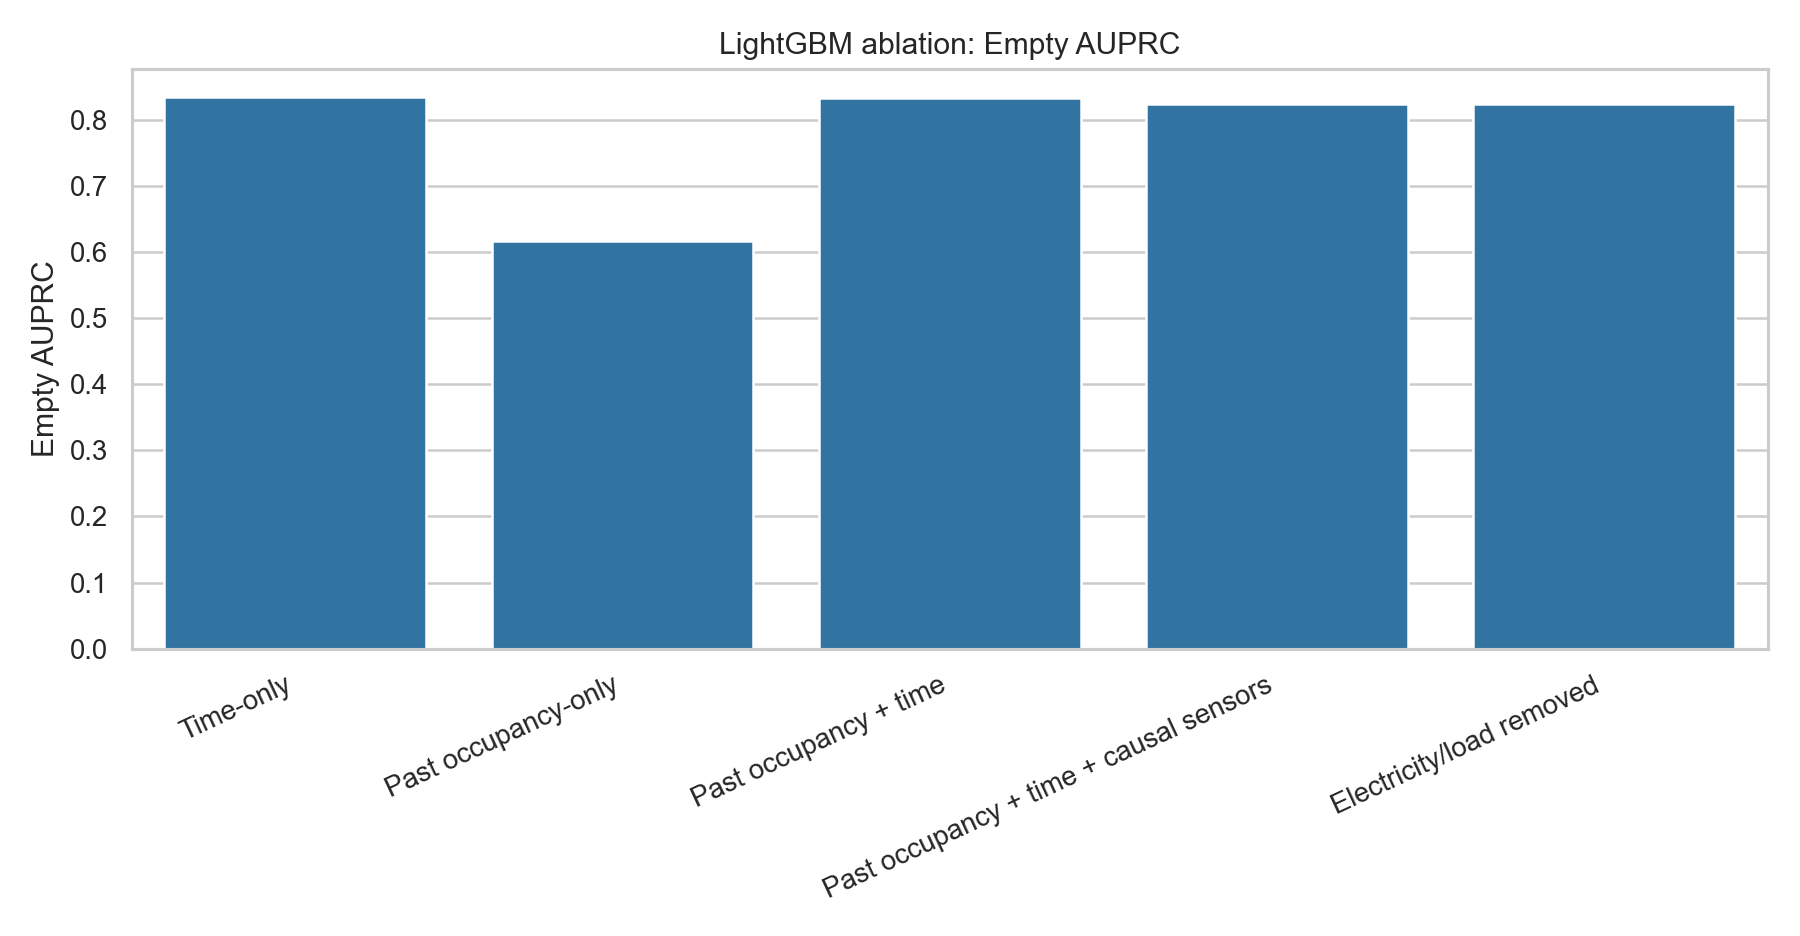

**figures/confusion_matrices_empty_selected.png**

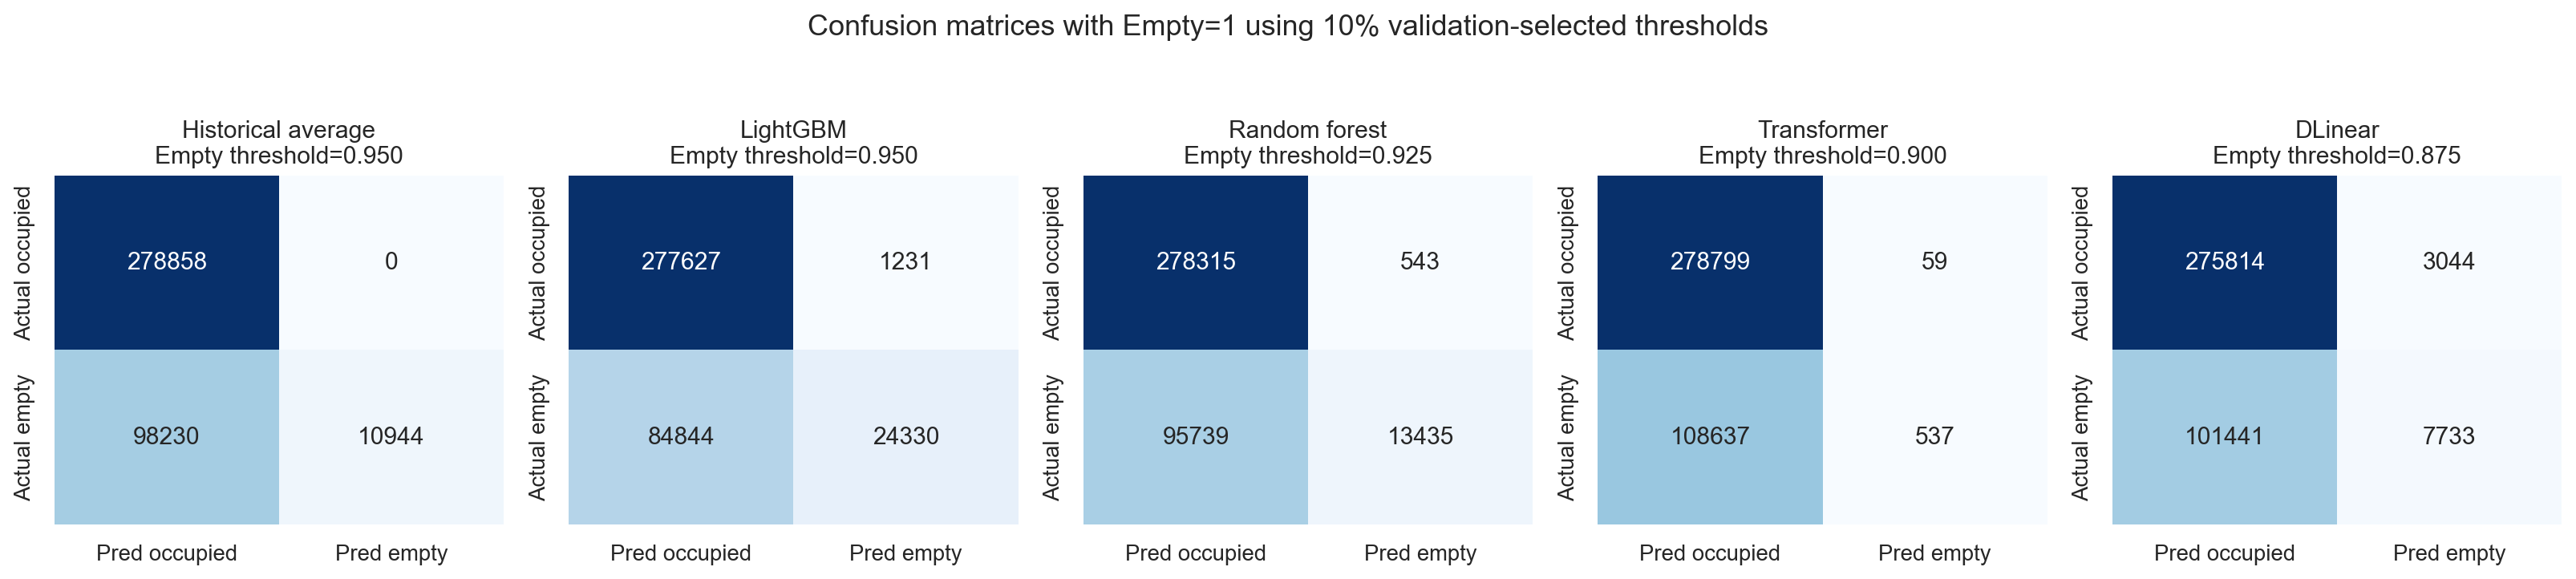

**figures/continuous_empty_window_conflict_rate.png**

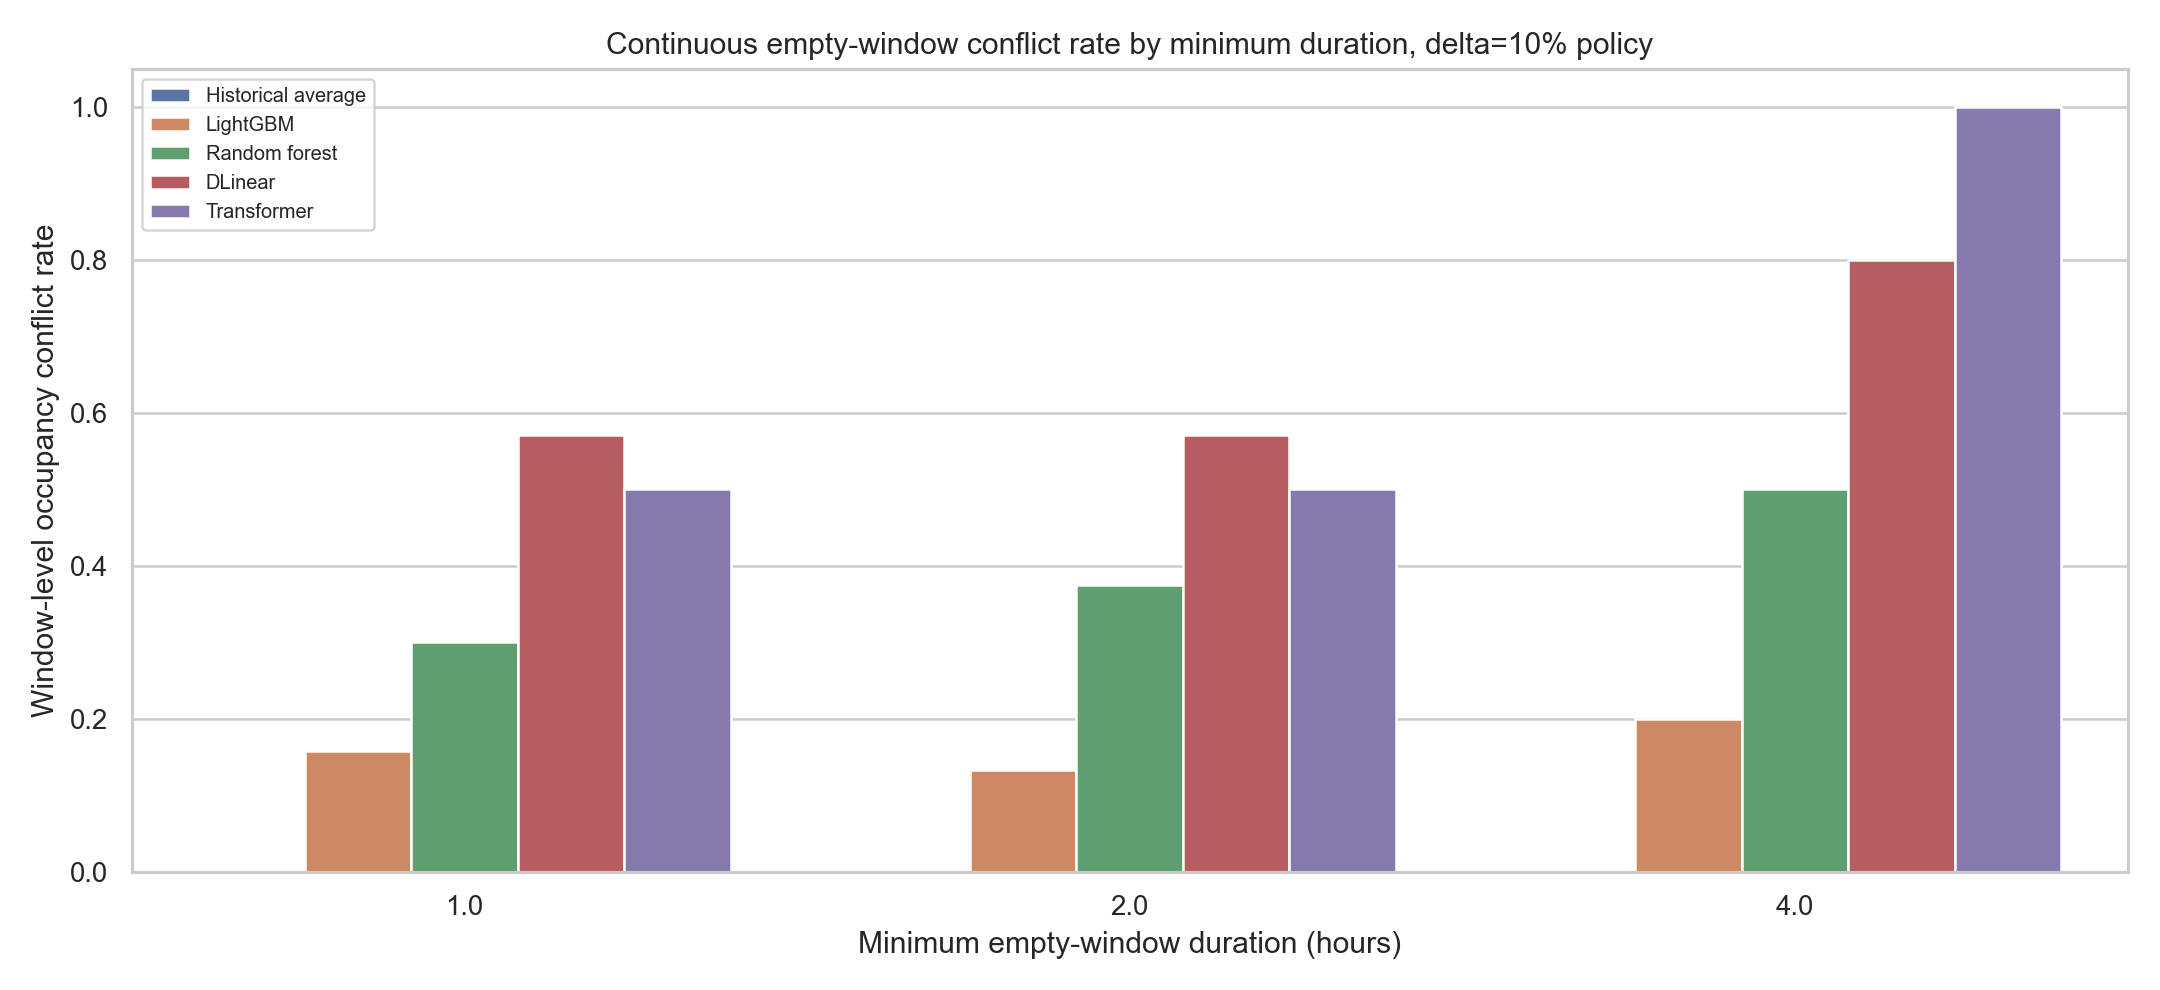

**figures/empty_class_model_metrics.png**

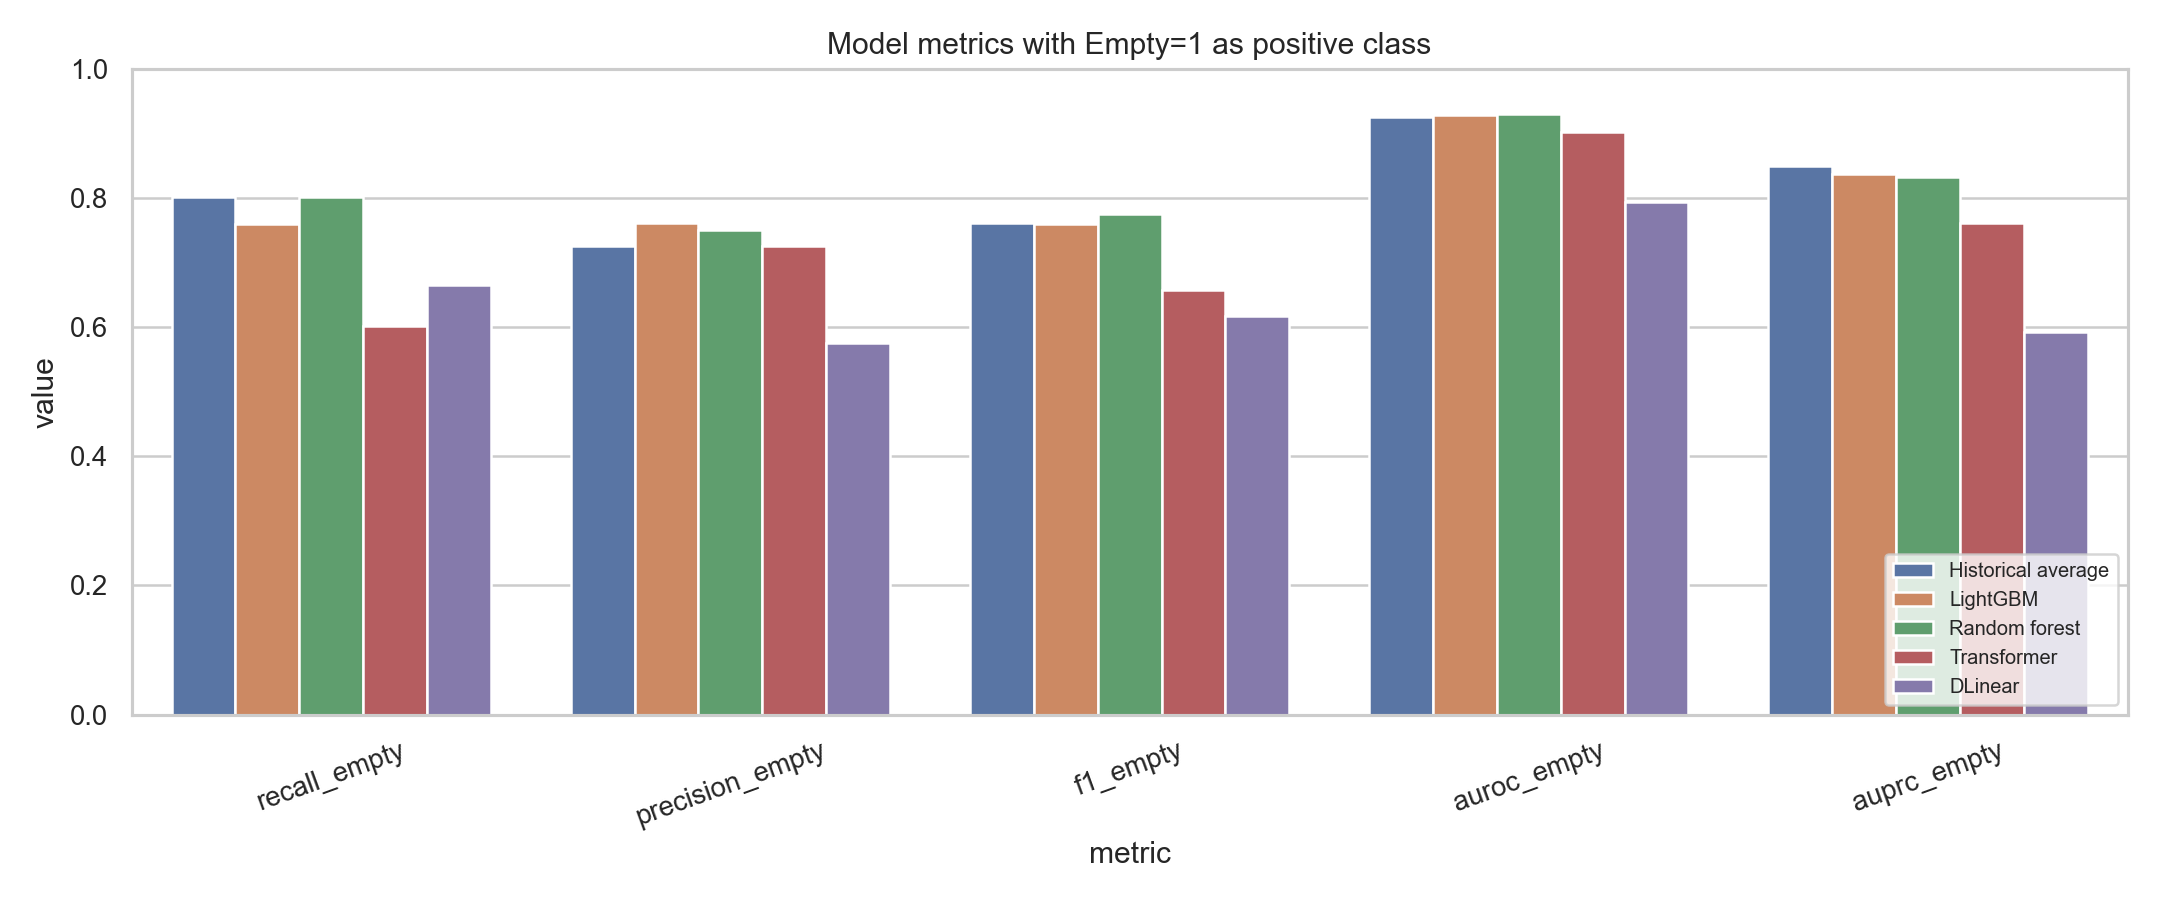

**figures/empty_precision_recall_curve.png**

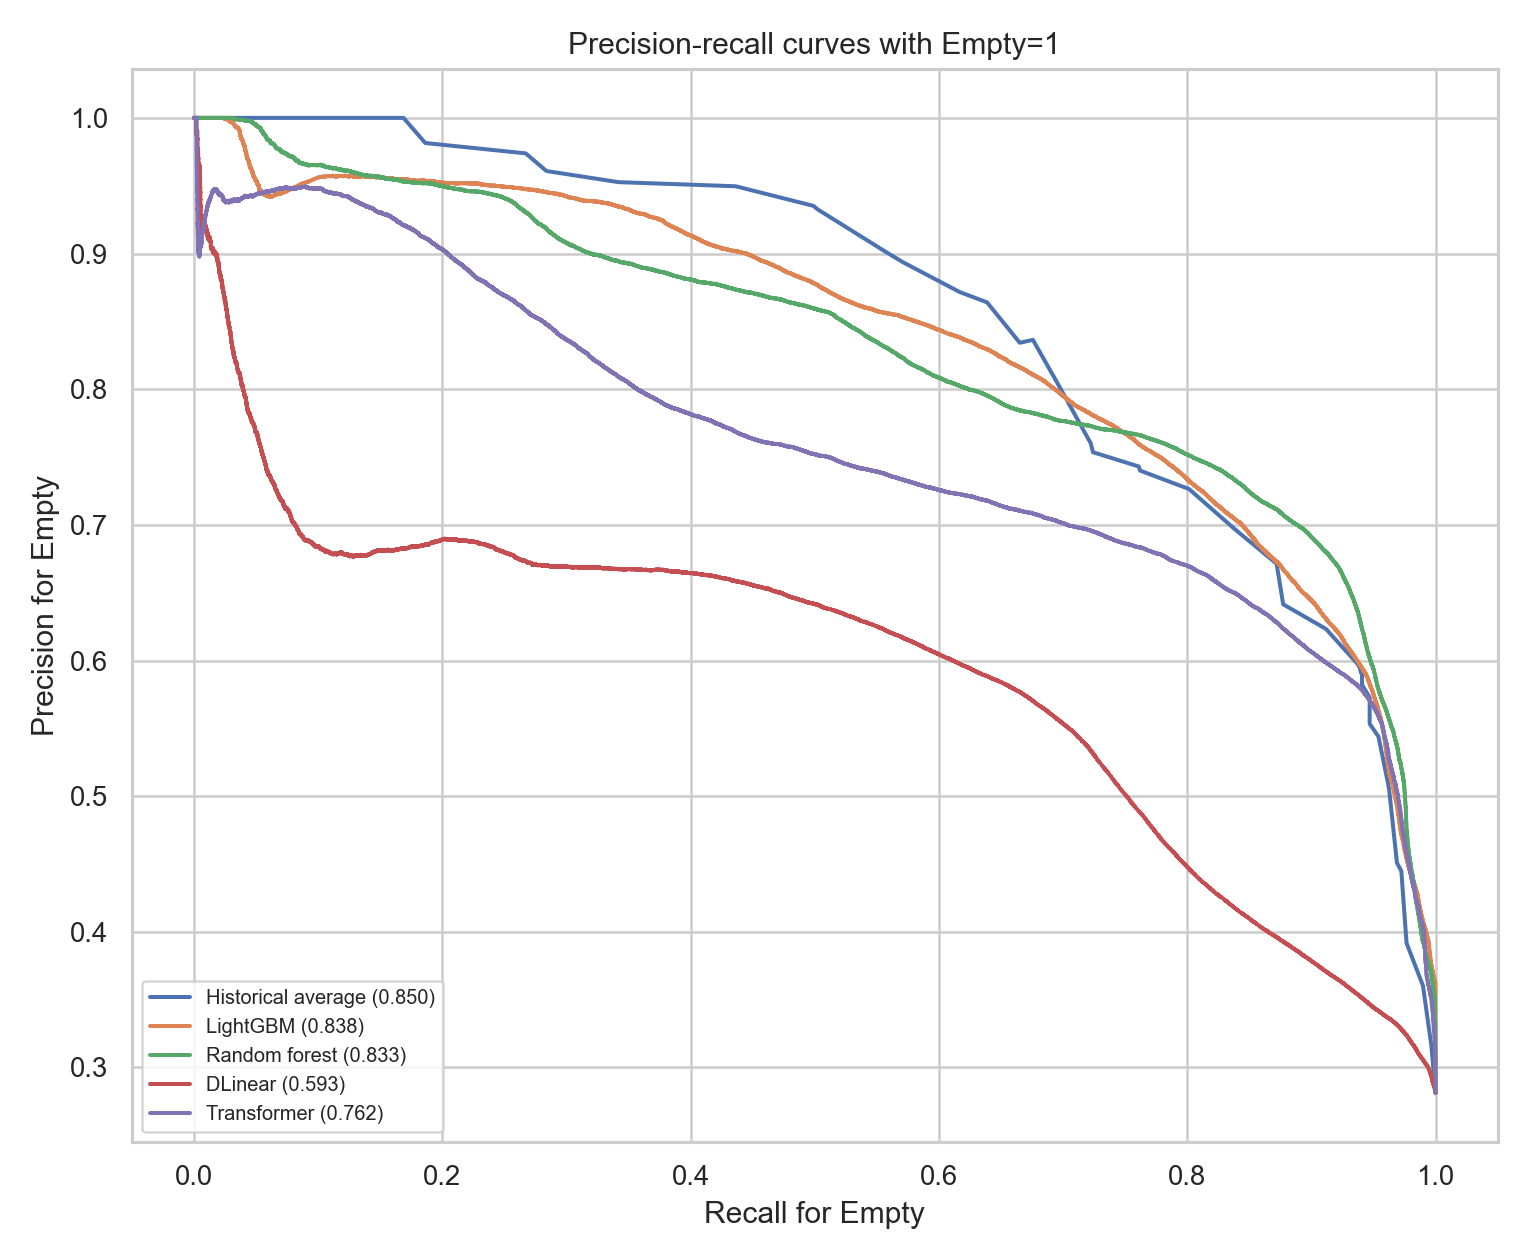

**figures/empty_reliability_curve.png**

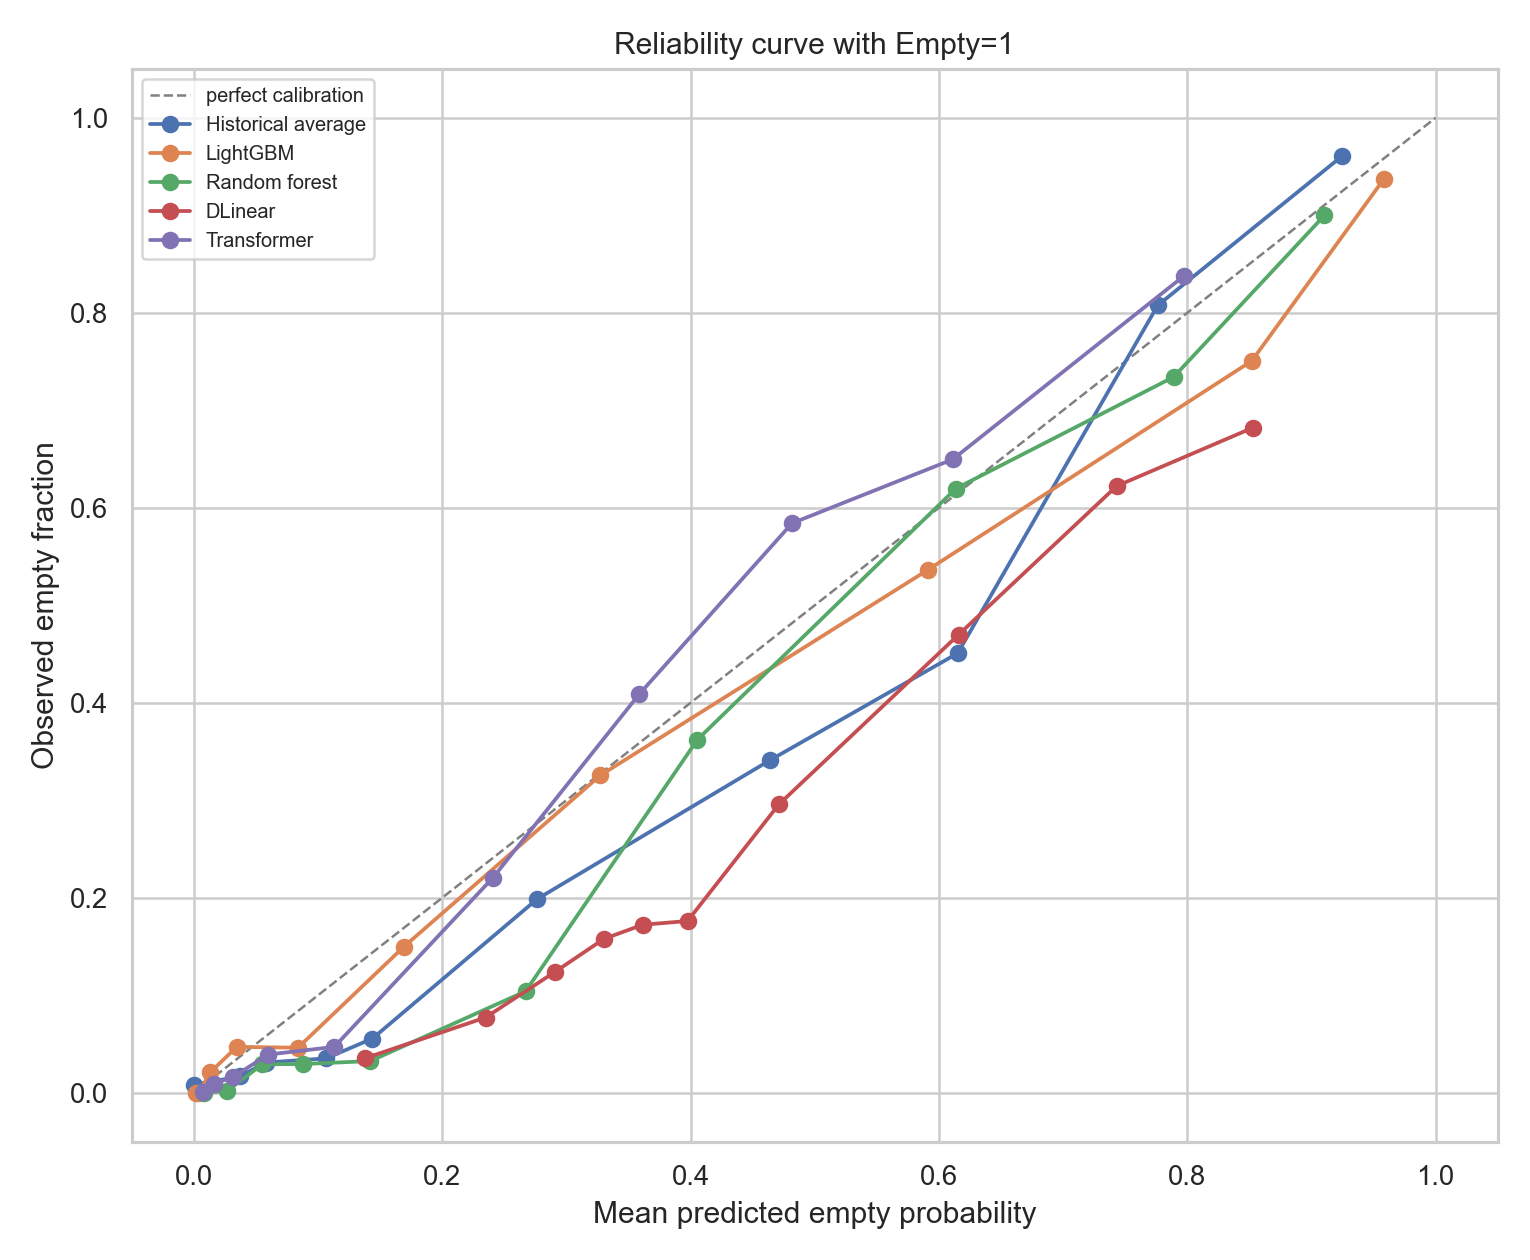

**figures/empty_roc_curve.png**

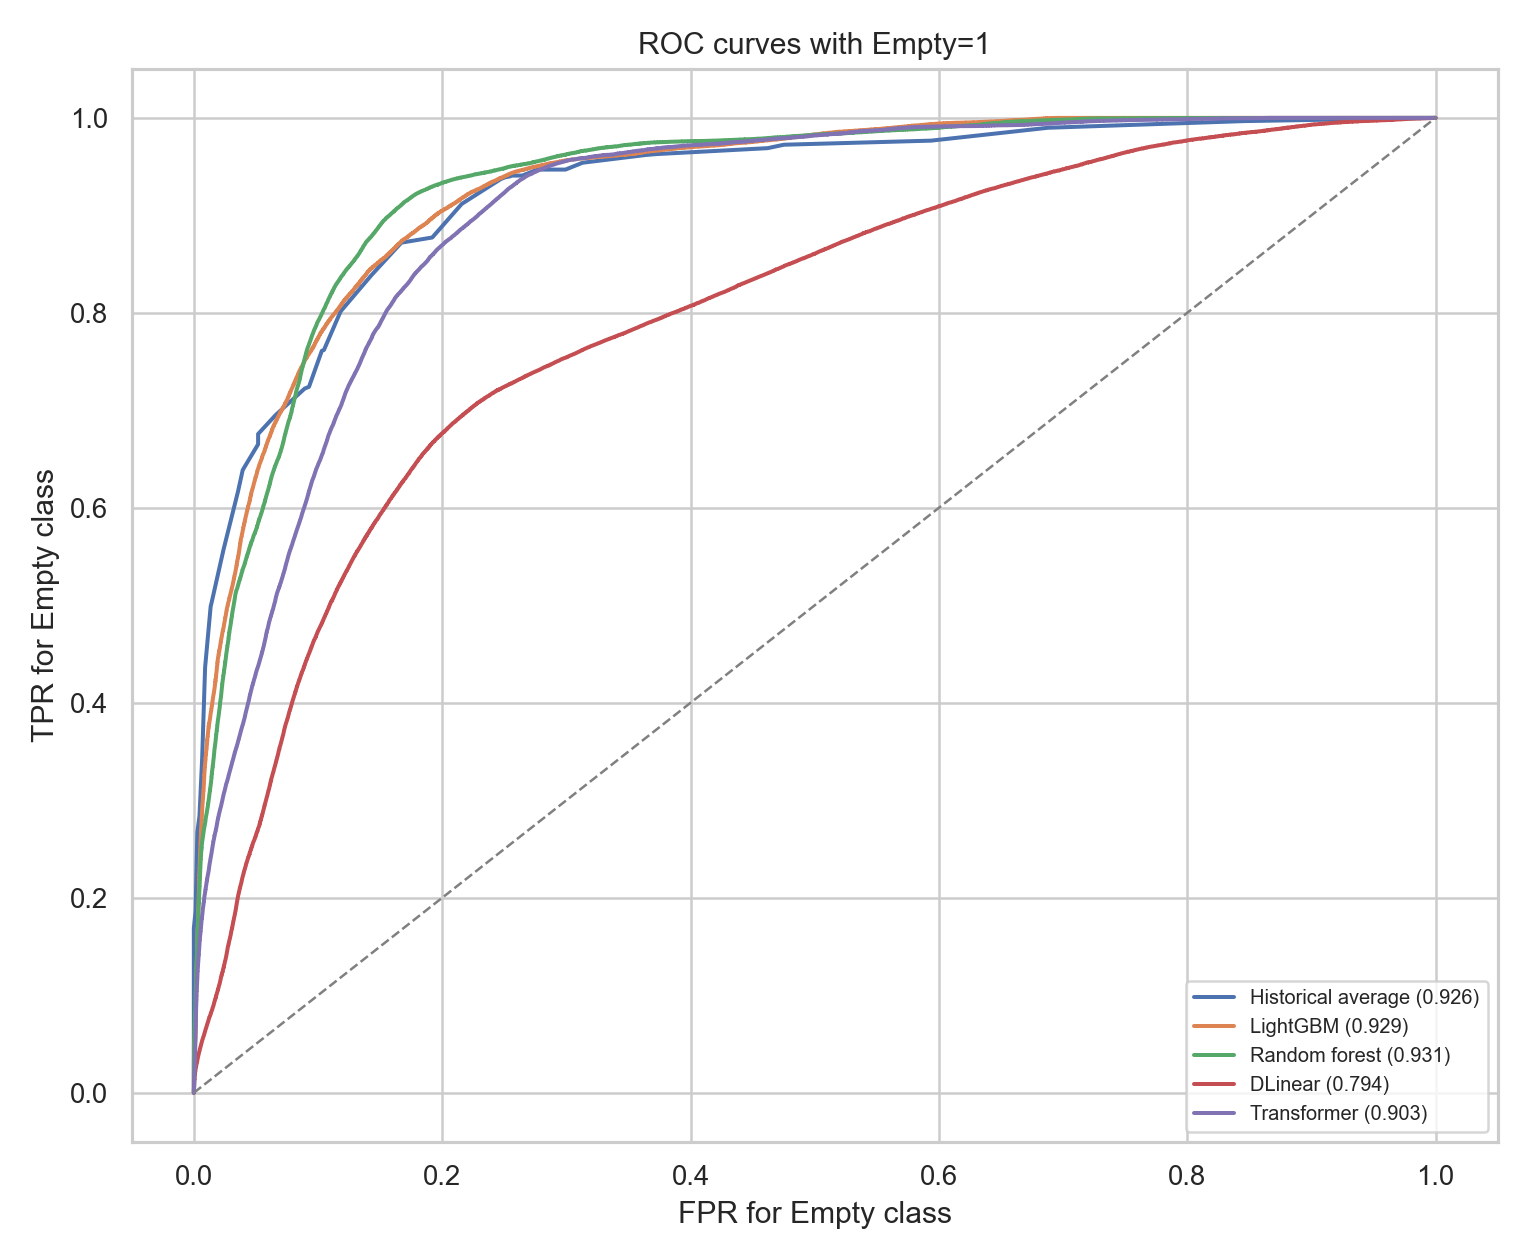

**figures/energy_risk_tradeoff_pareto.png**

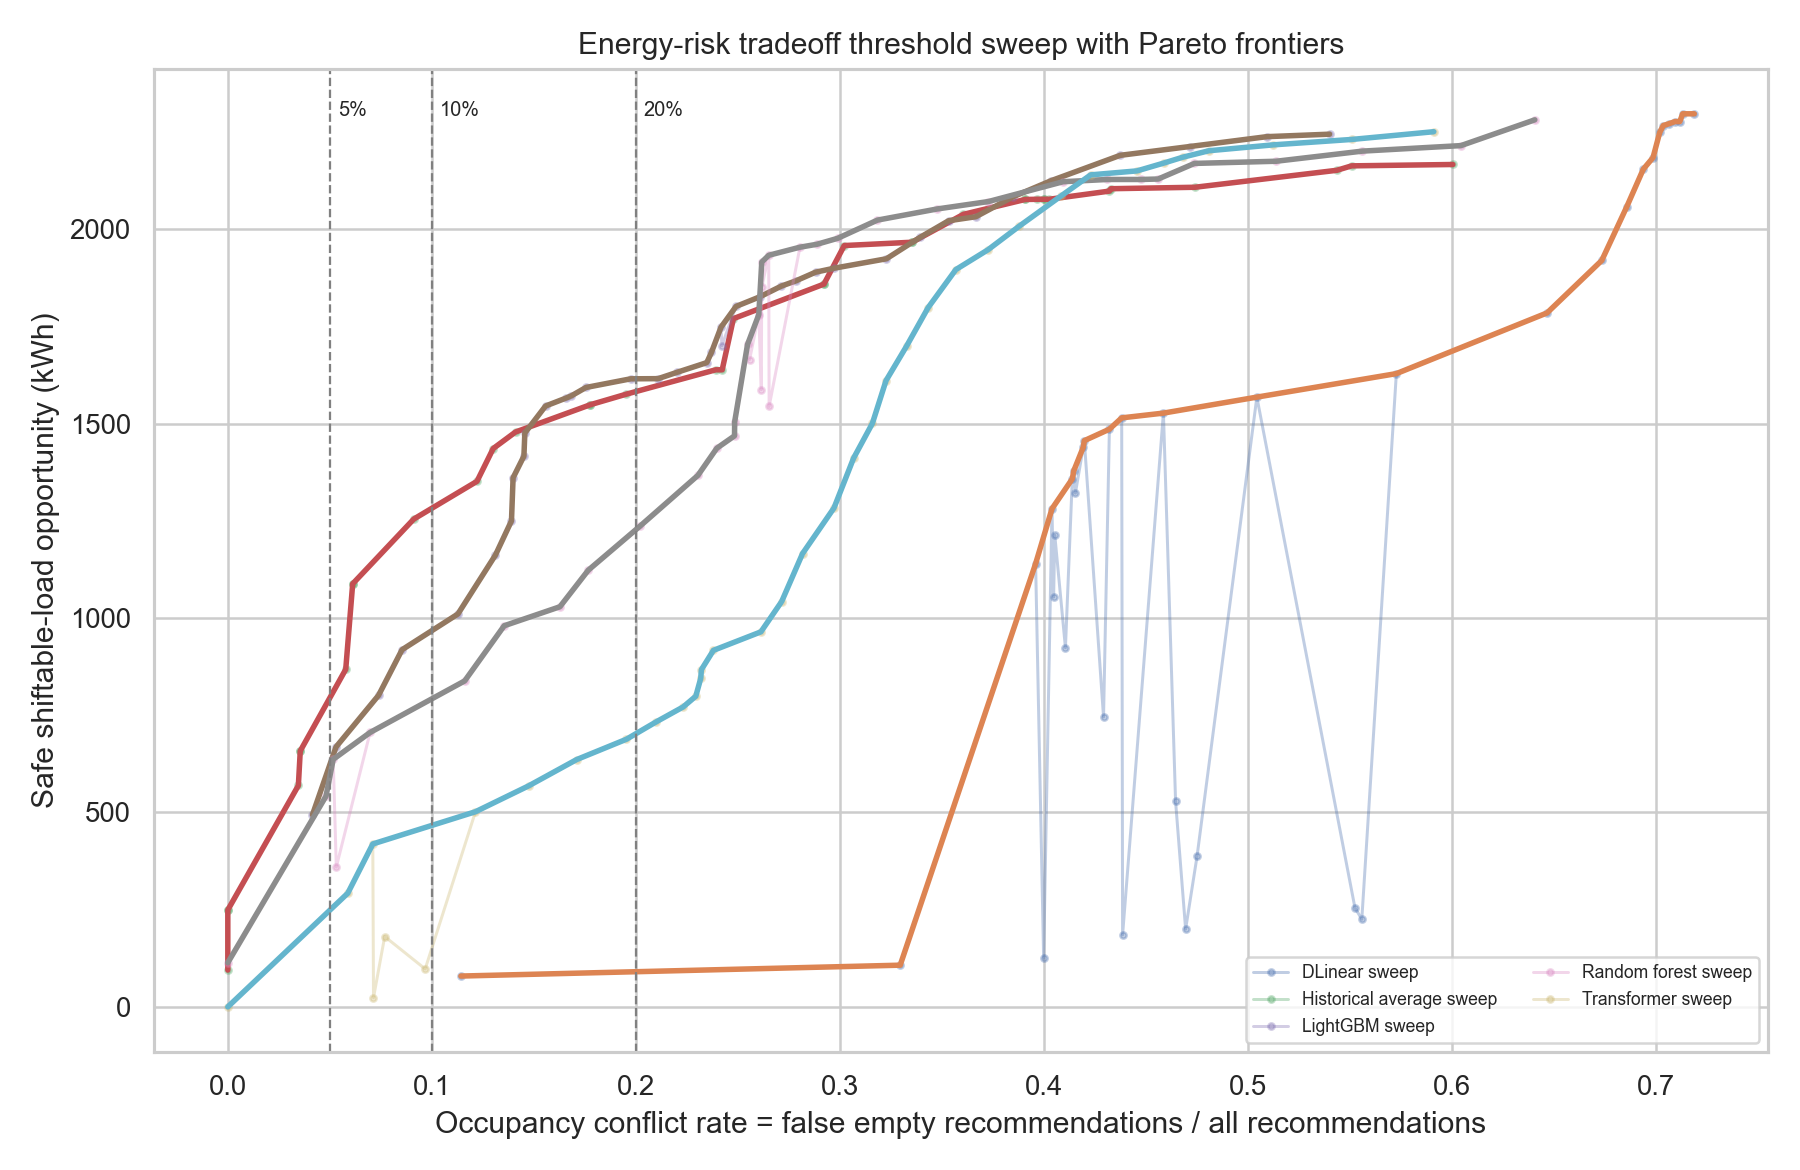

**figures/energy_sensitivity_analysis.png**

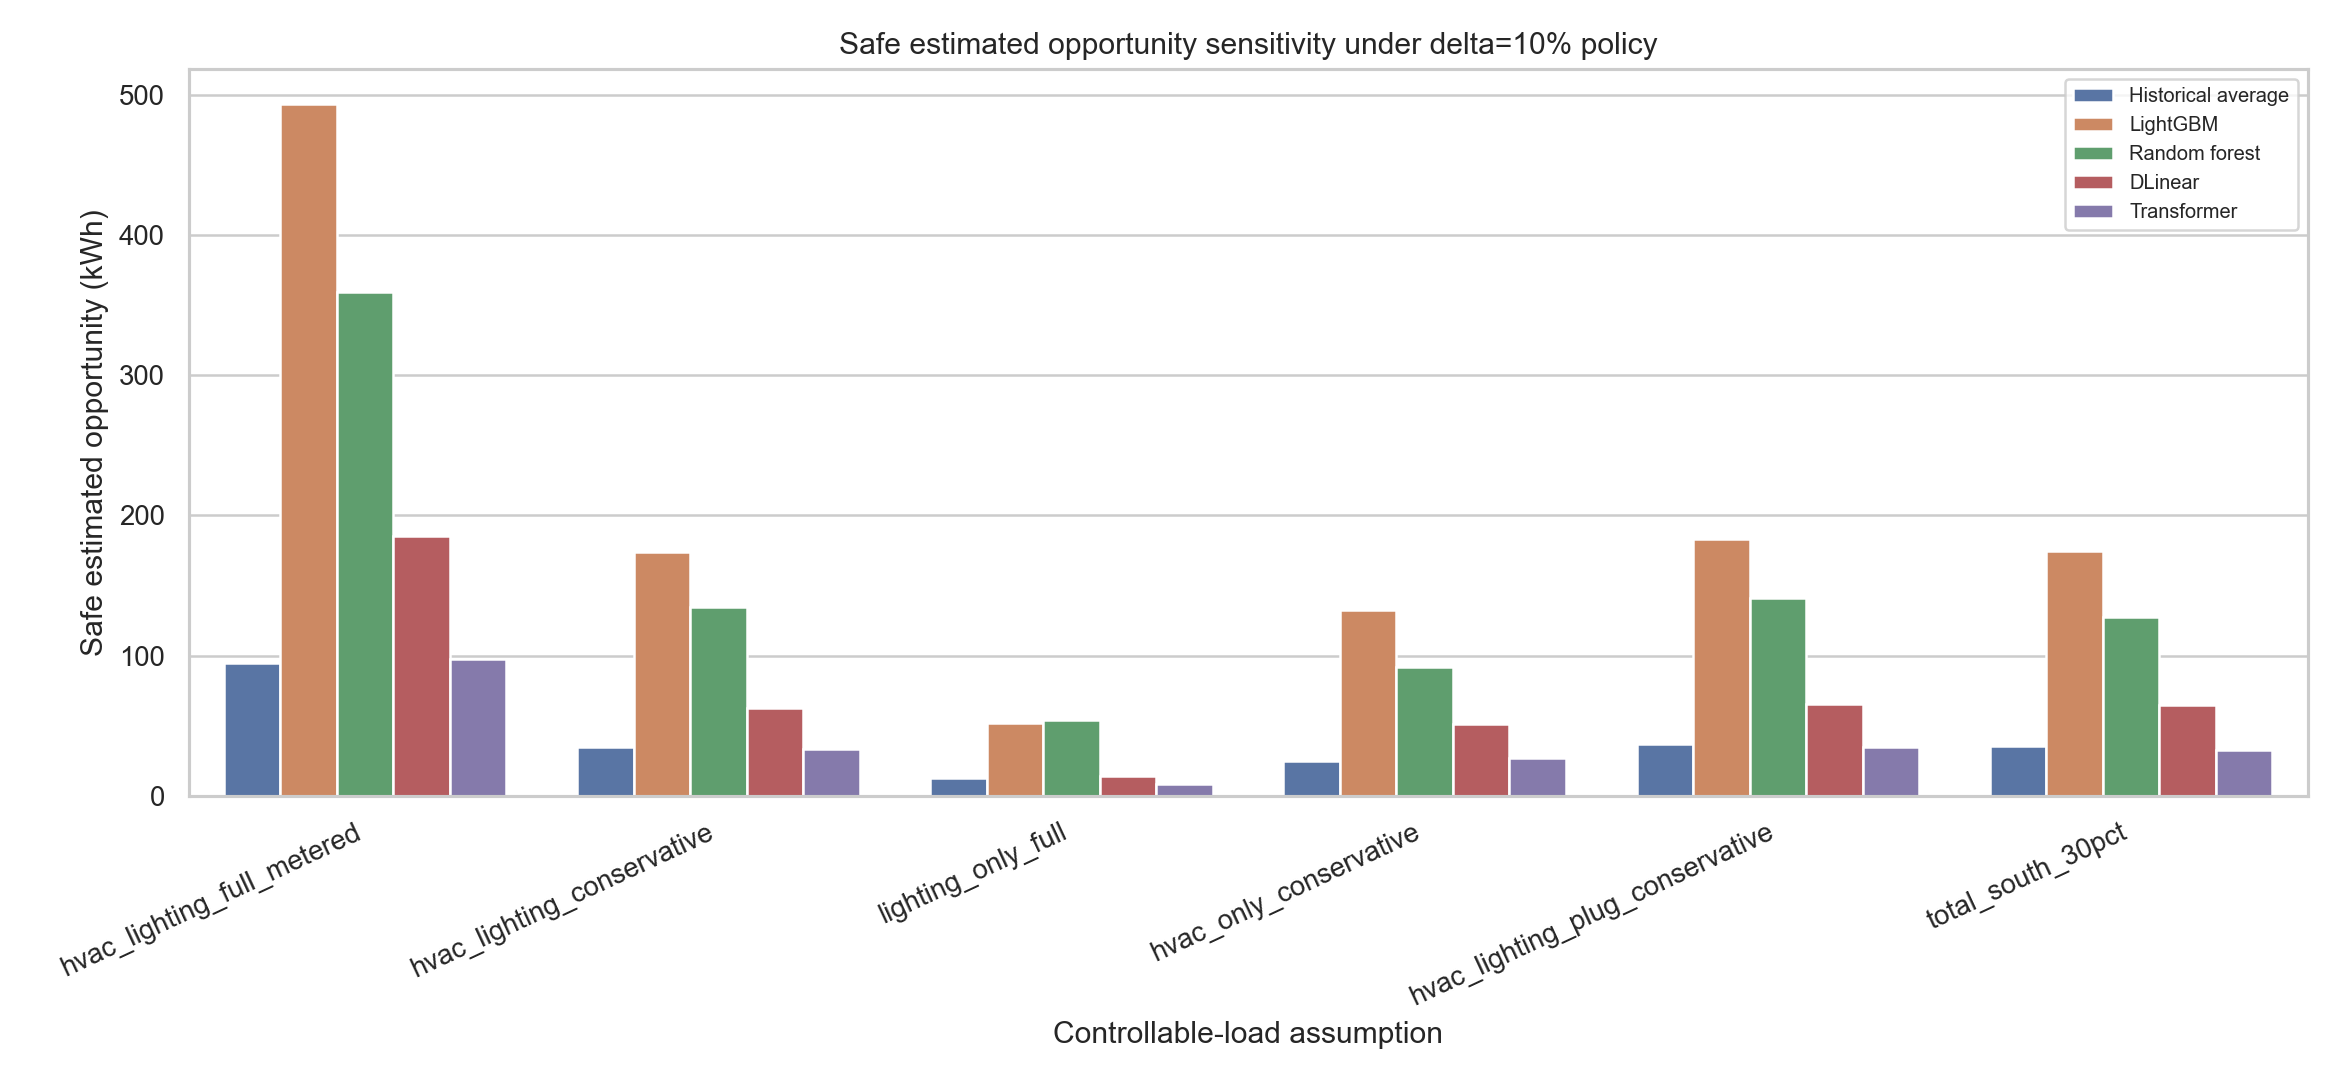

**figures/example_day_dlinear_conflict_failure.png**

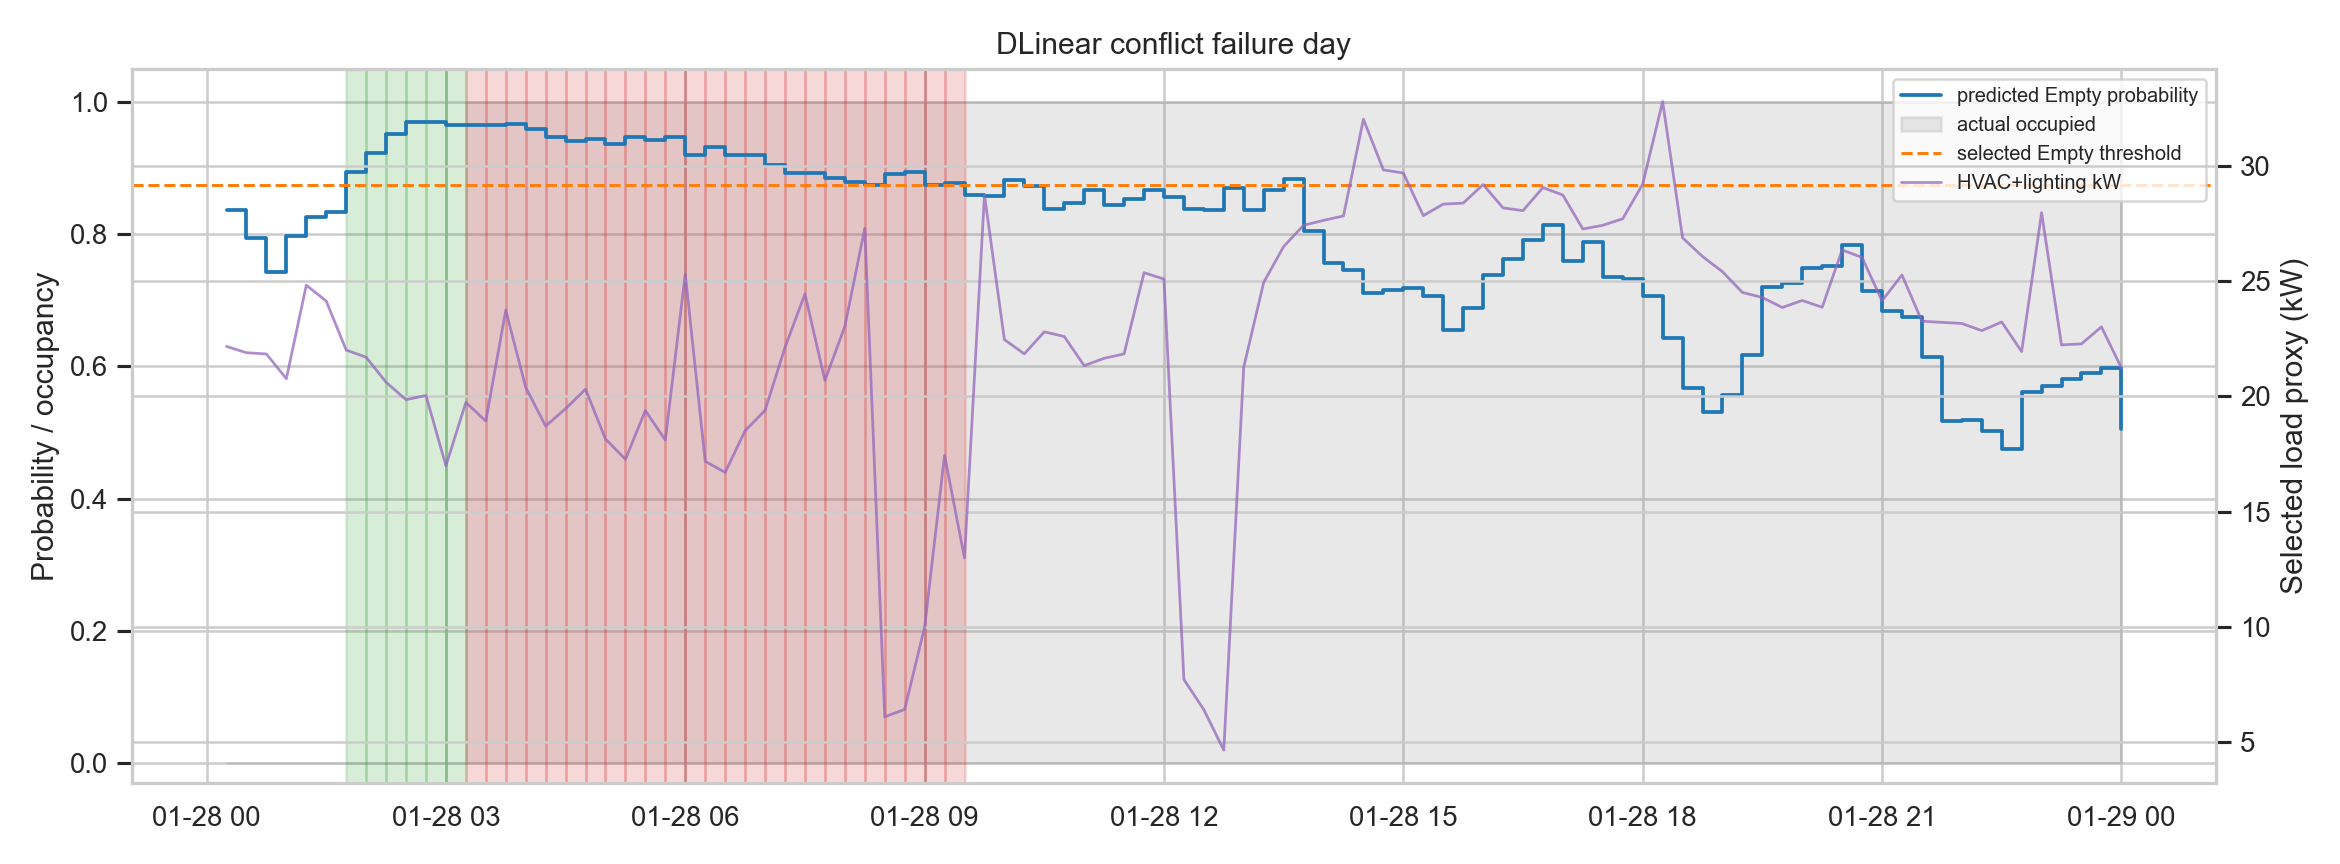

**figures/example_day_historical_average_missed_opportunity.png**

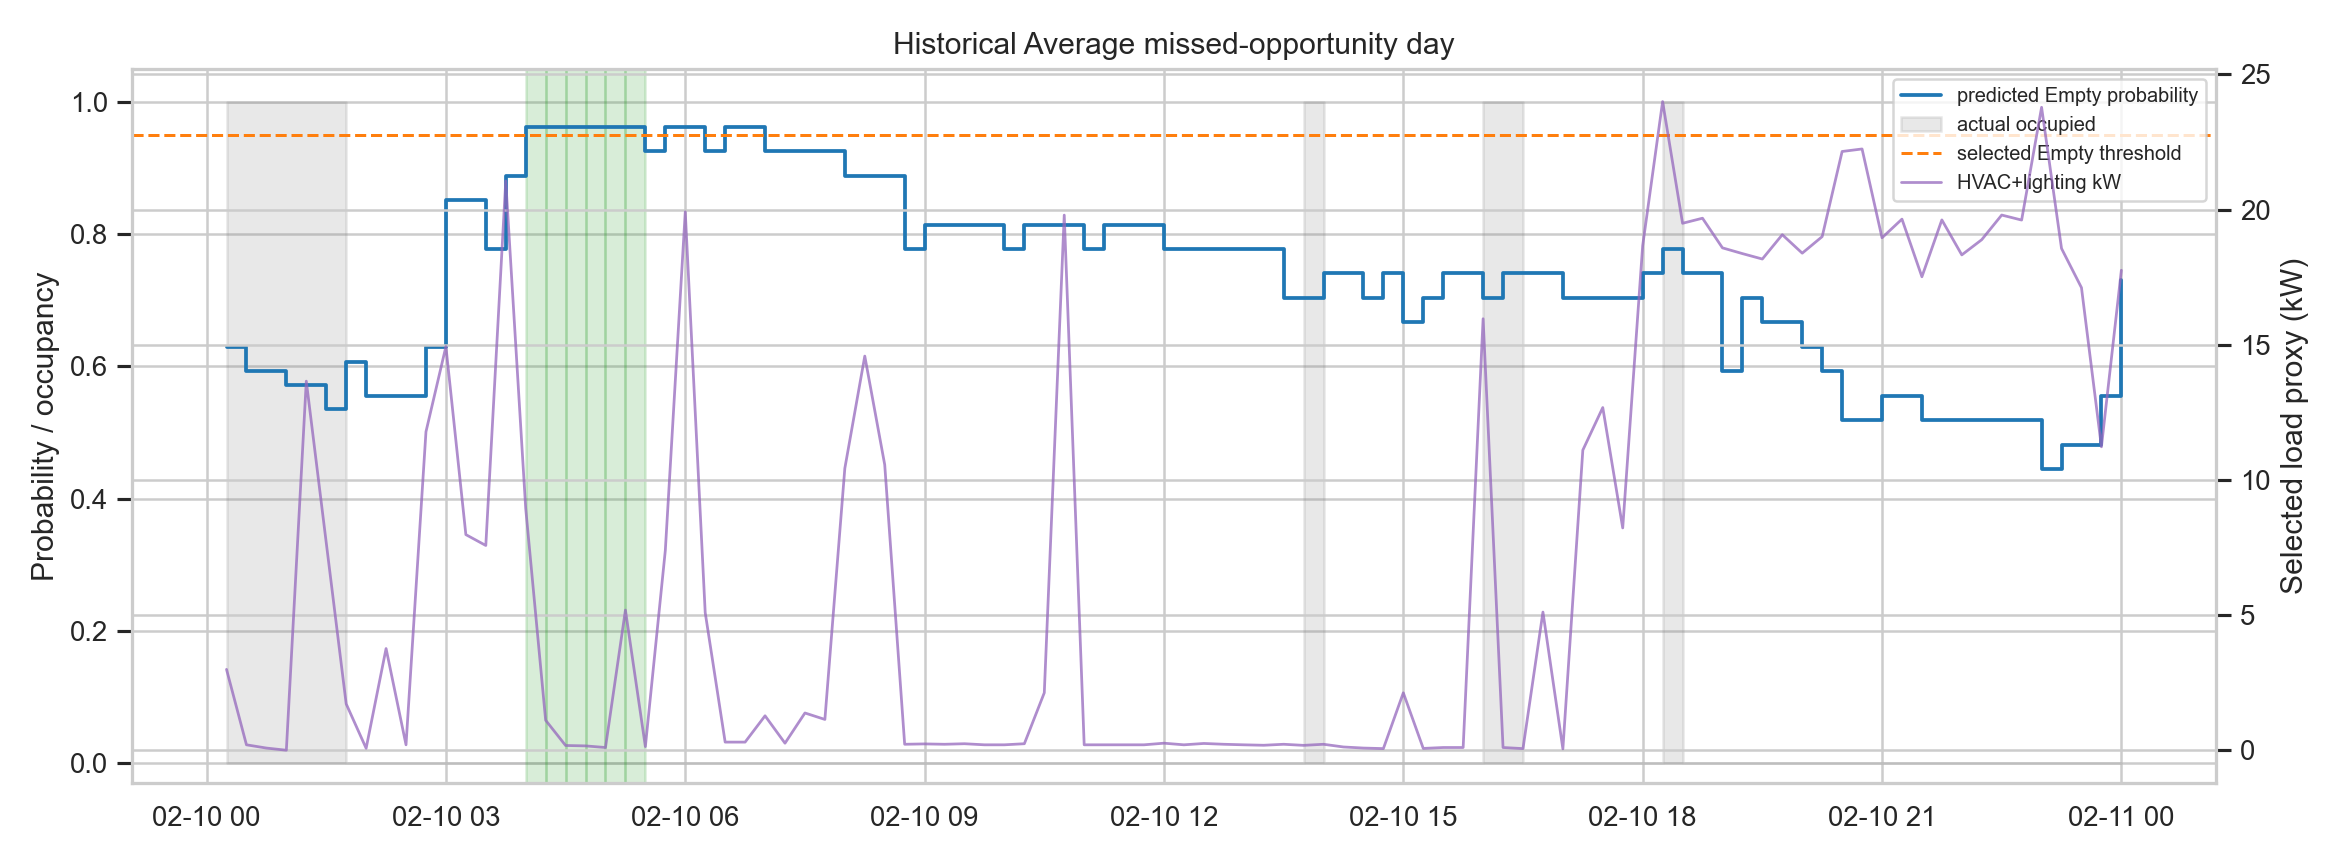

**figures/example_day_lightgbm_recommendation.png**

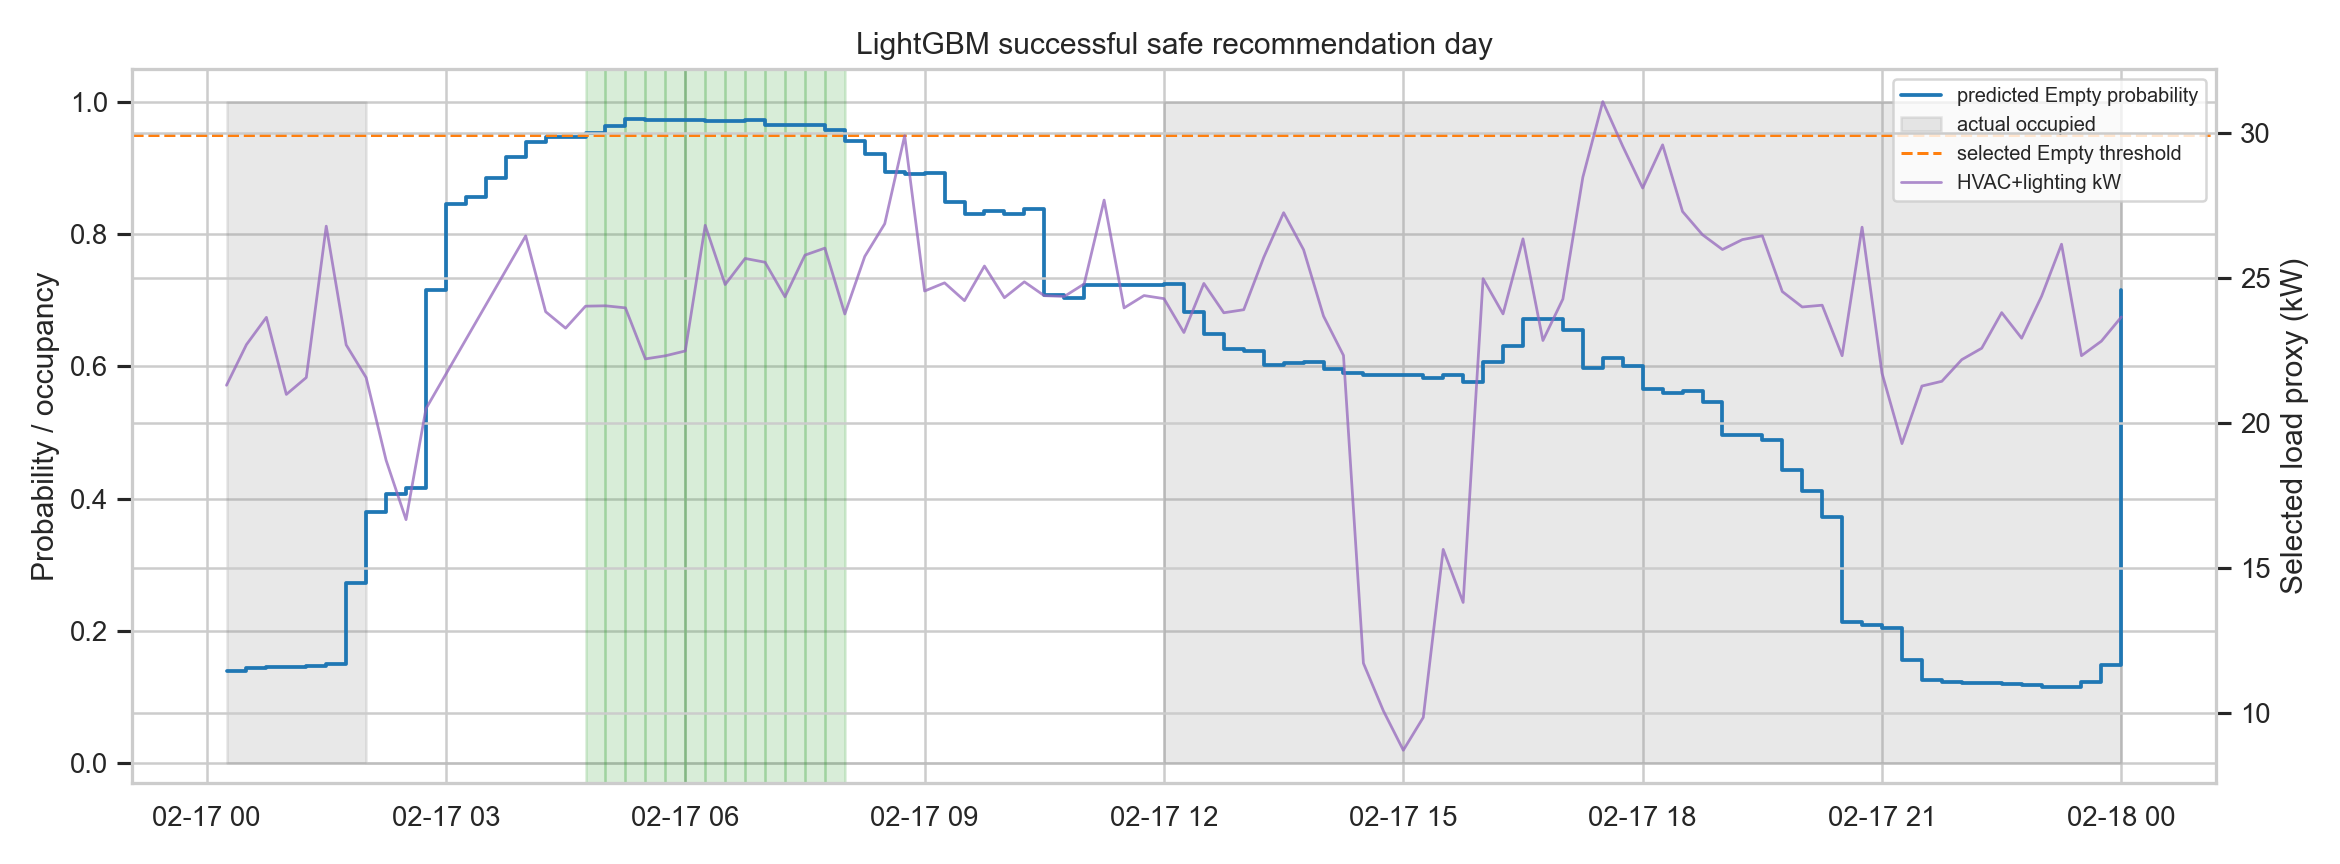

**figures/example_forecast_false_positive_recommendation_day.png**

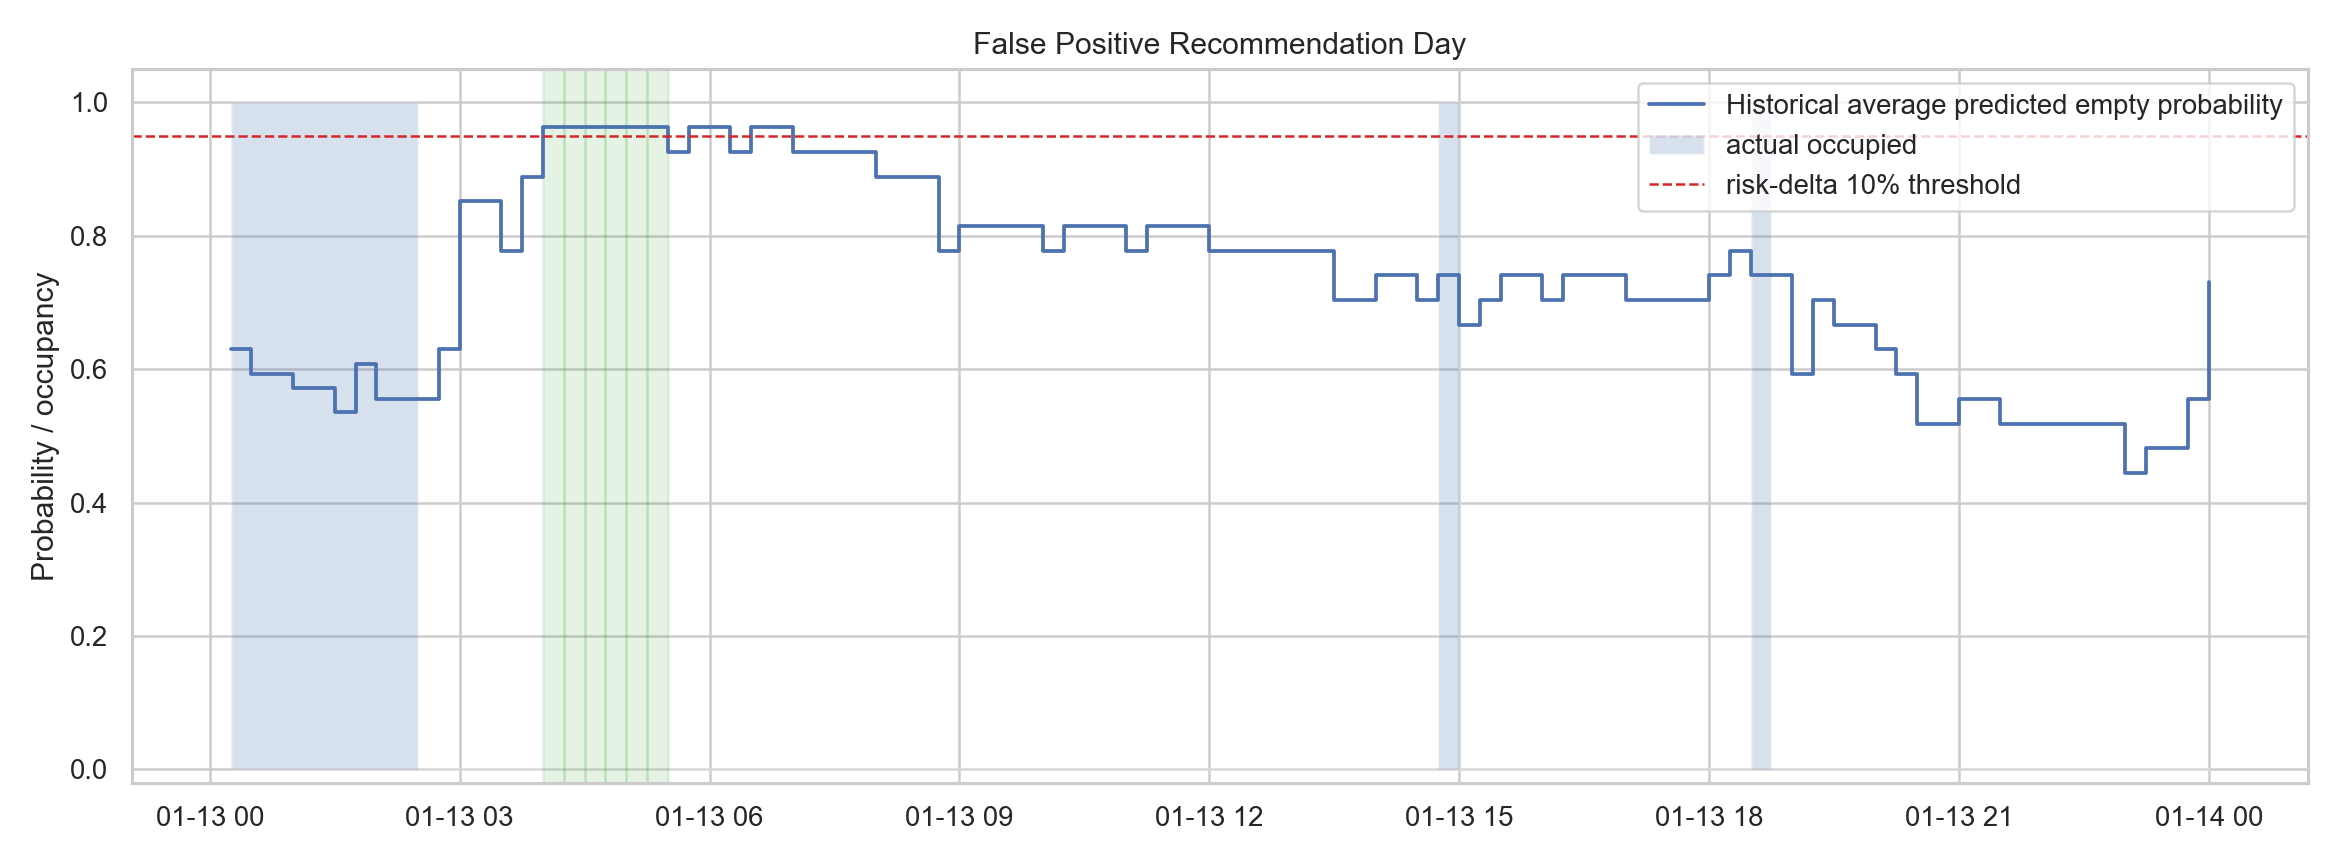

**figures/example_forecast_irregular_schedule_day.png**

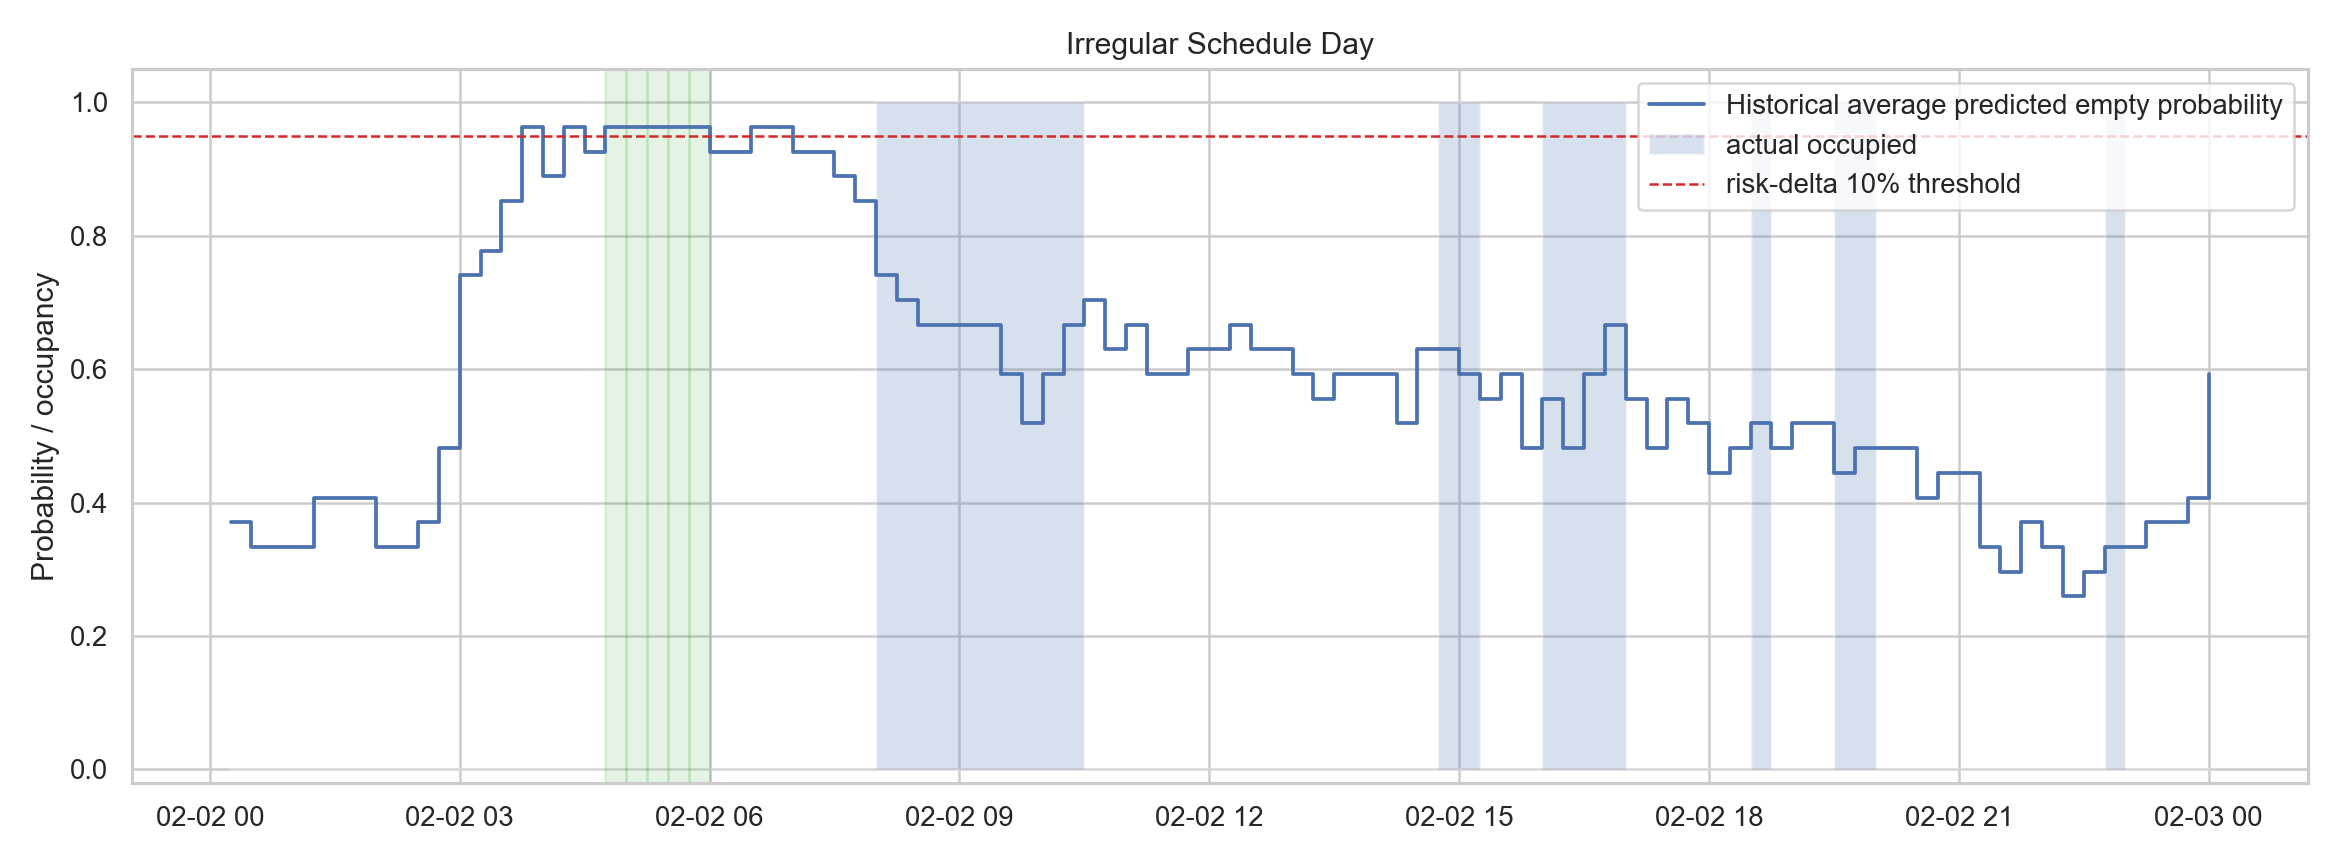

**figures/example_forecast_missed_opportunity_day.png**

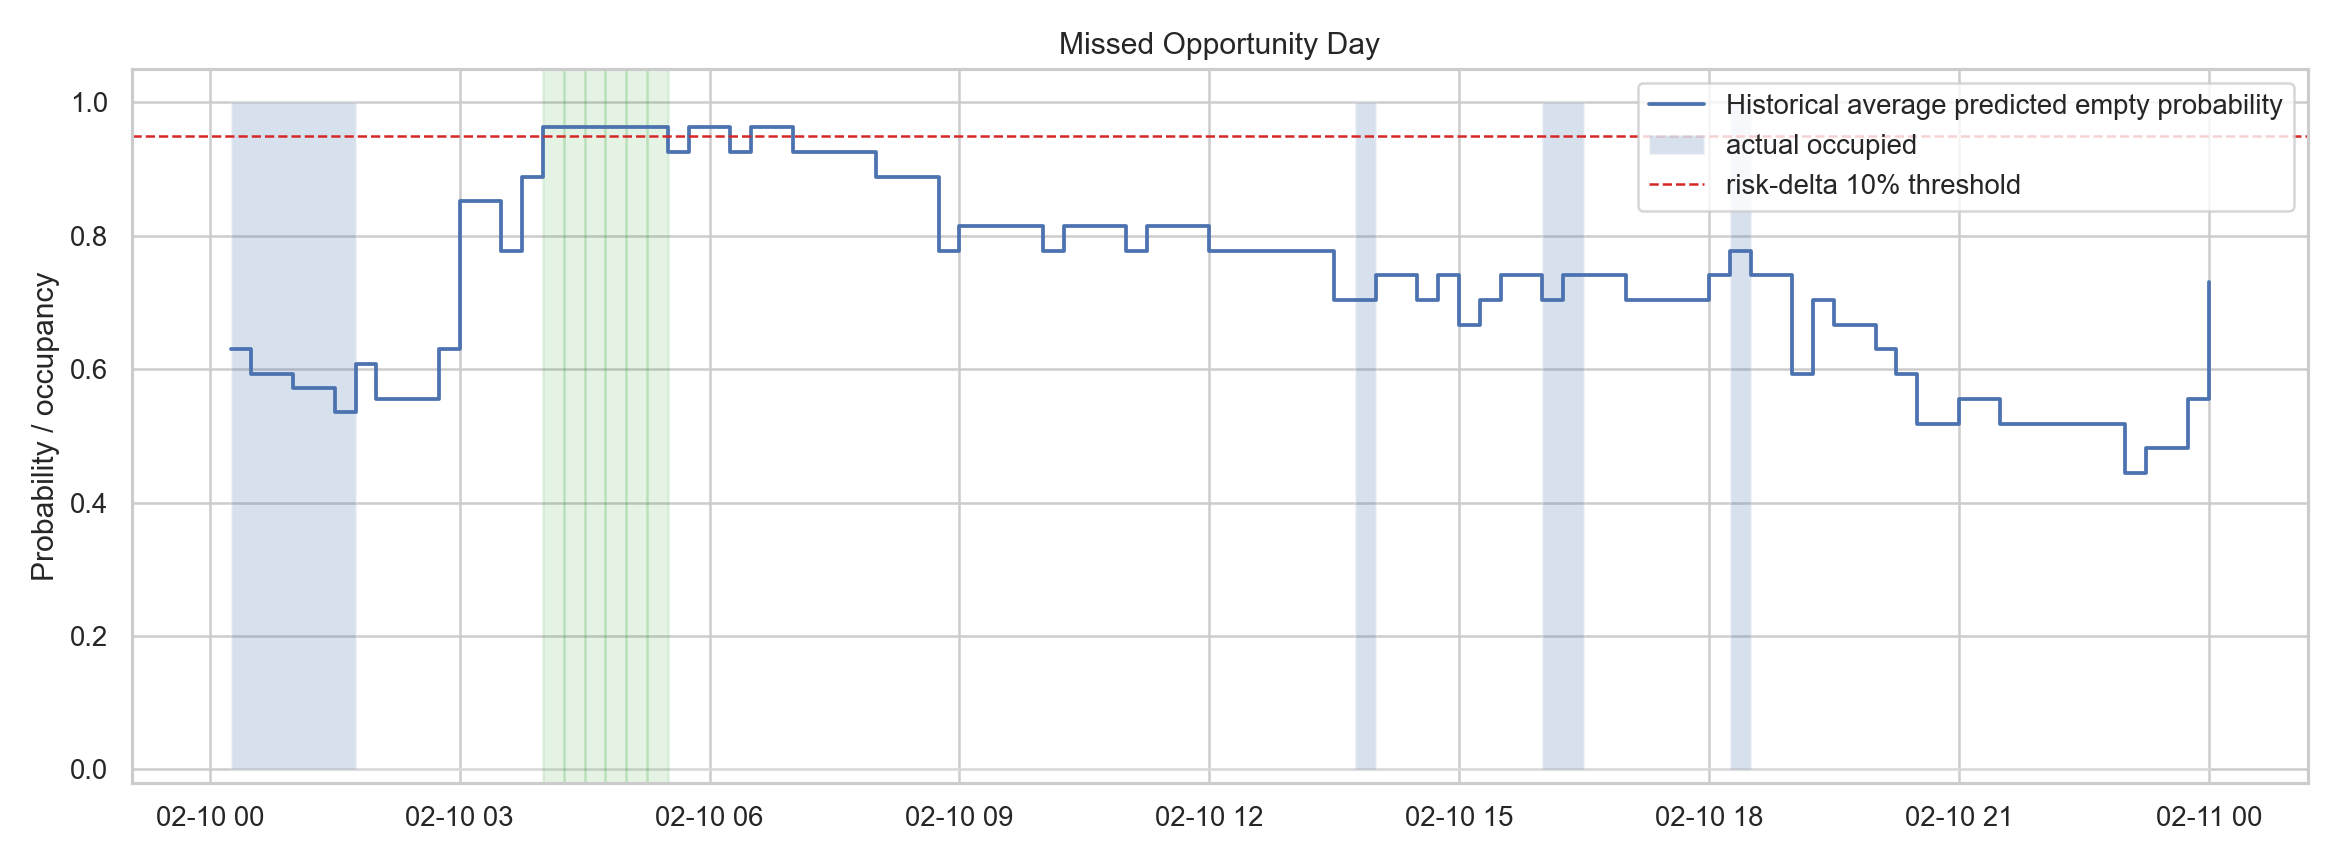

**figures/example_forecast_successful_recommendation_day.png**

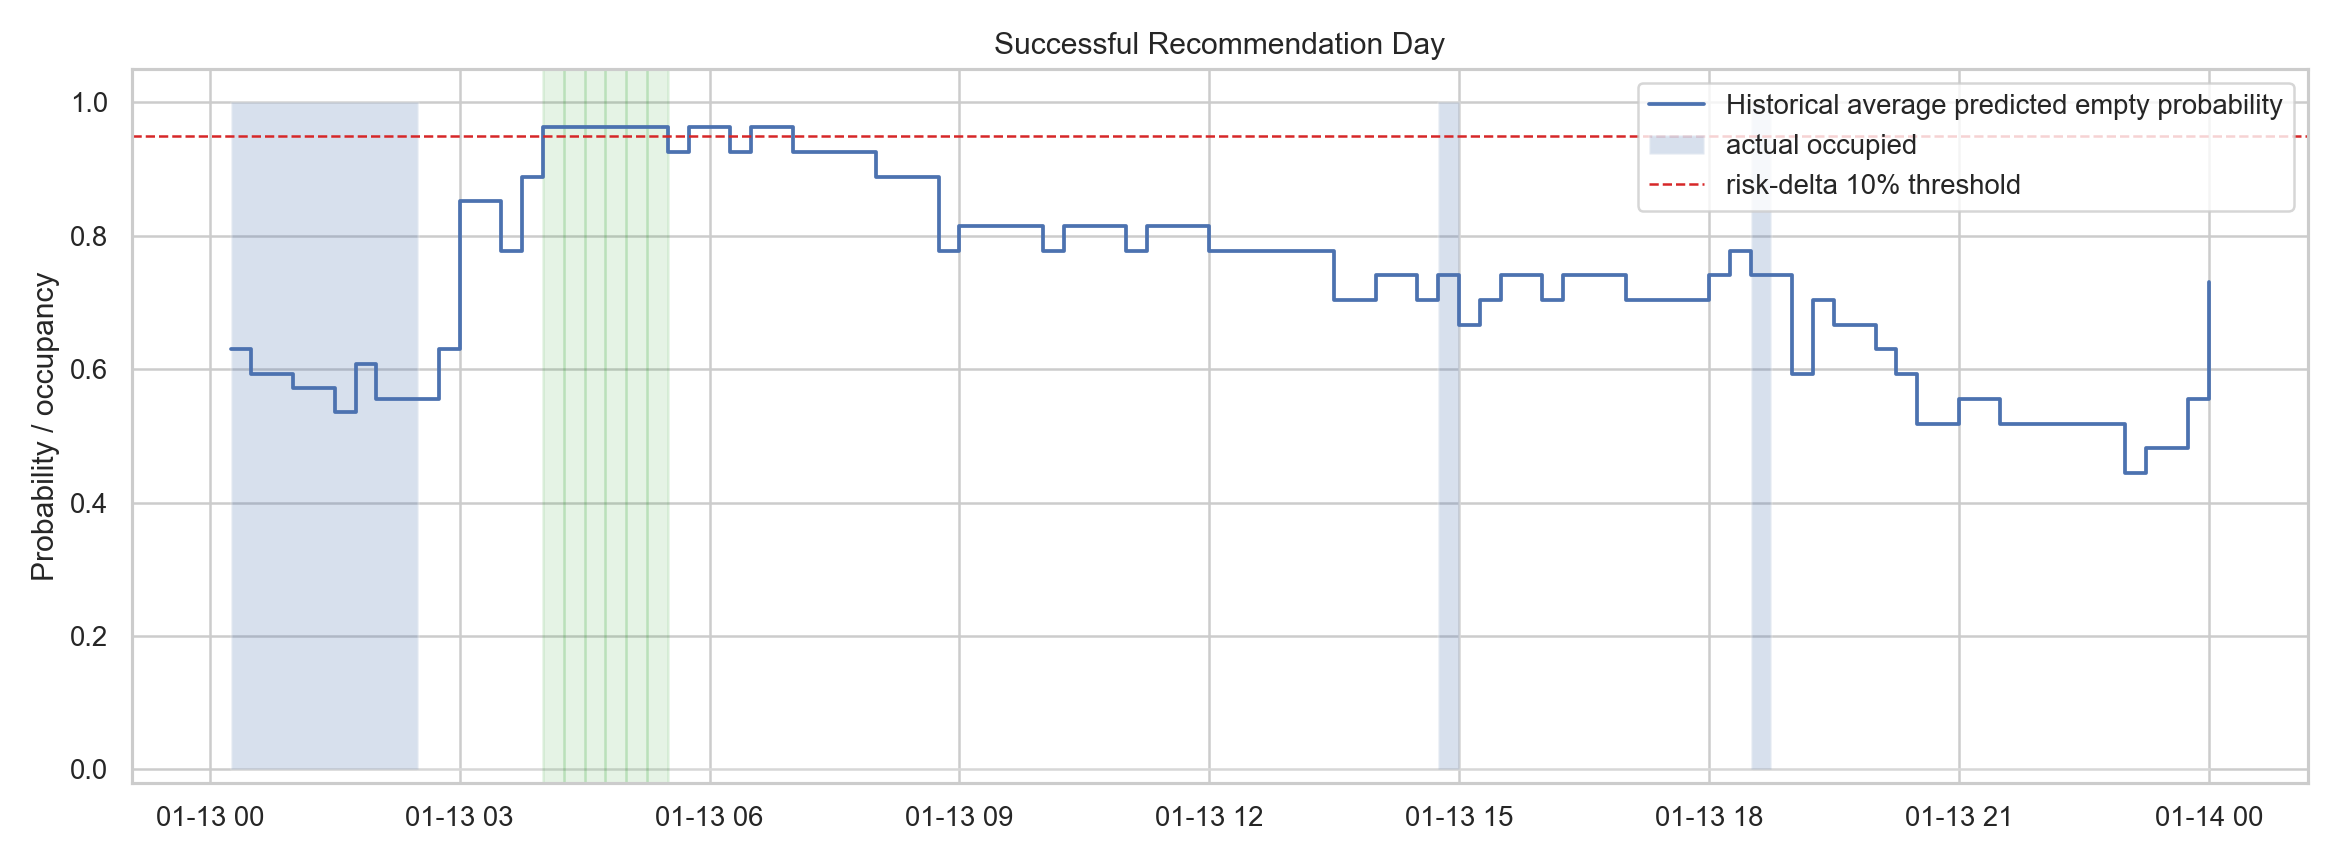

**figures/feature_importance_lightgbm.png**

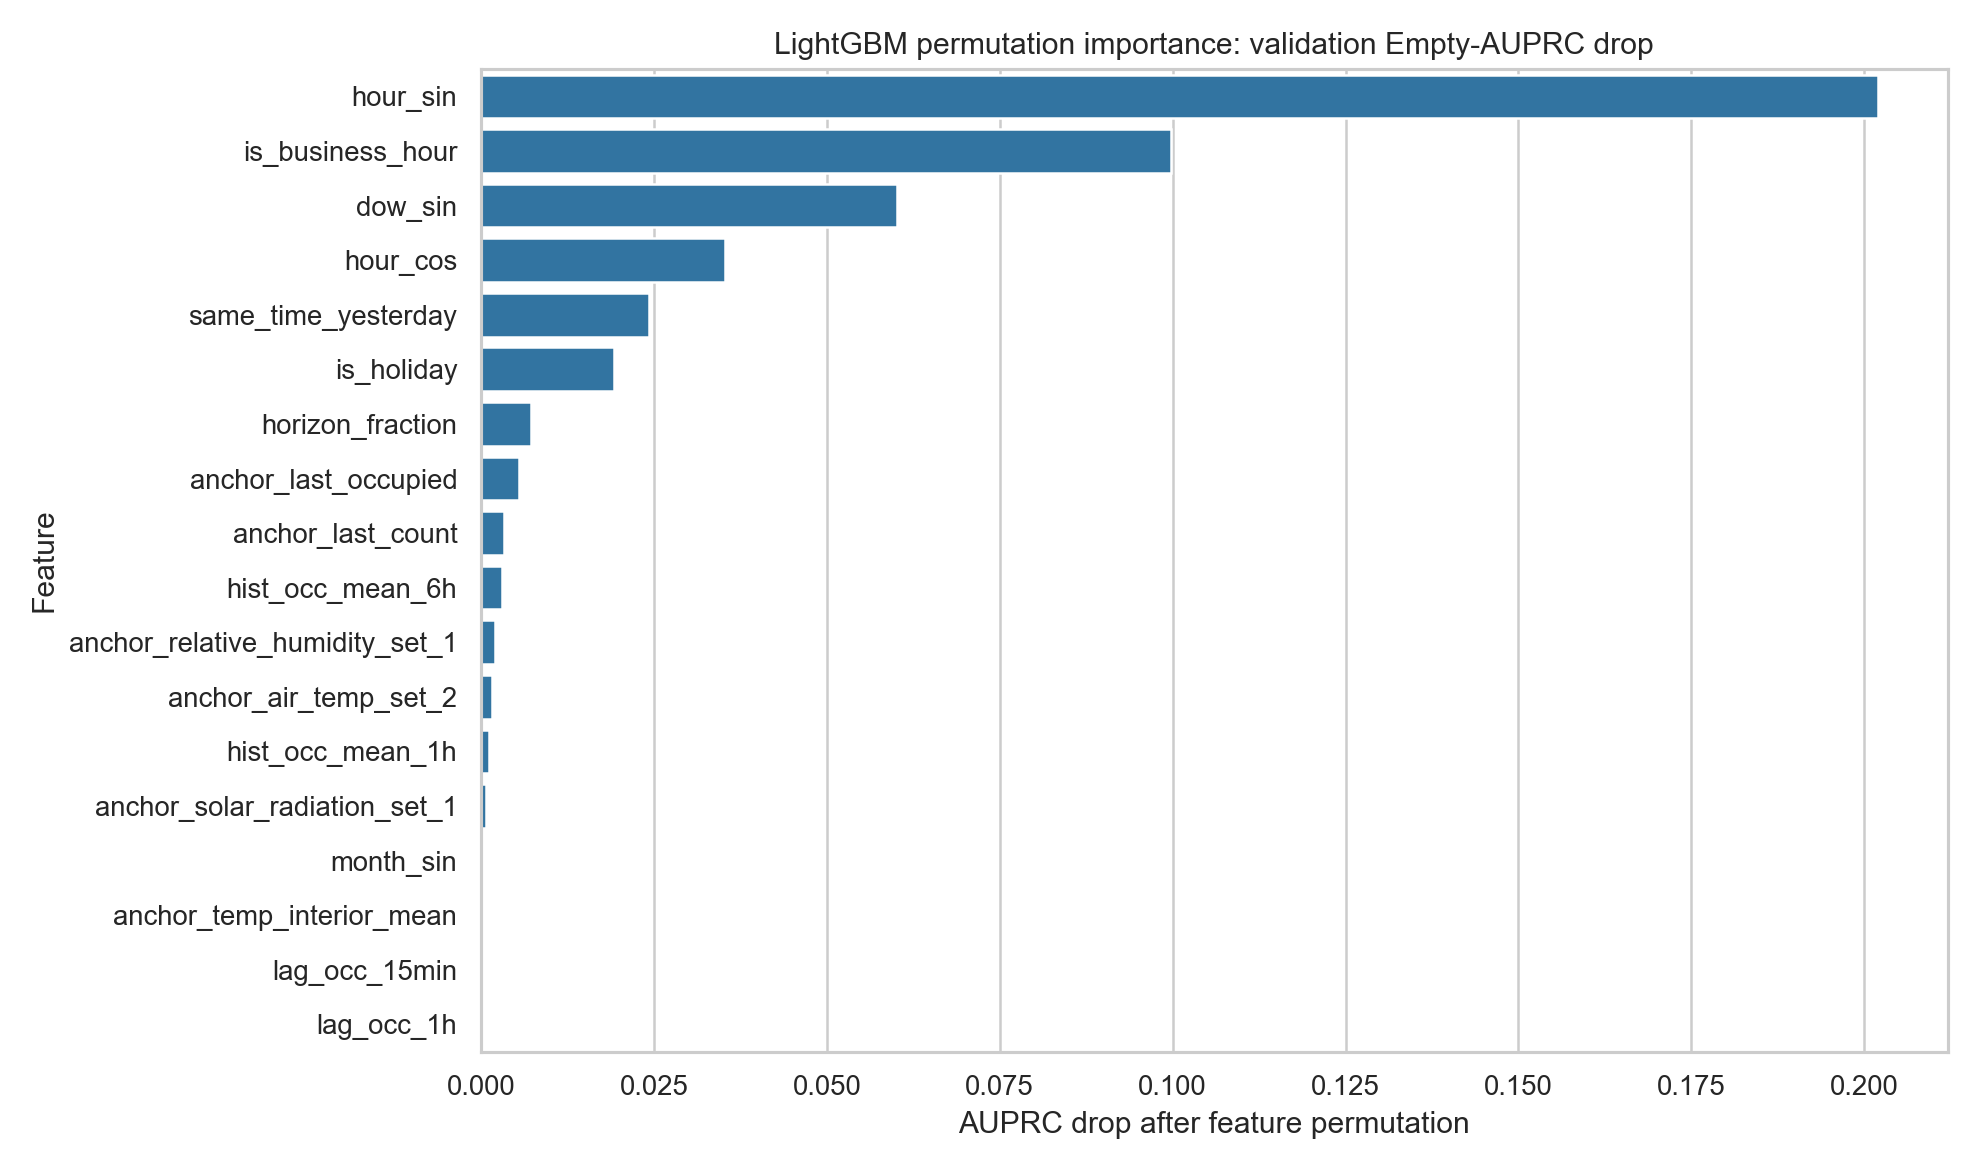

**figures/feature_importance_permutation_empty_auprc.png**

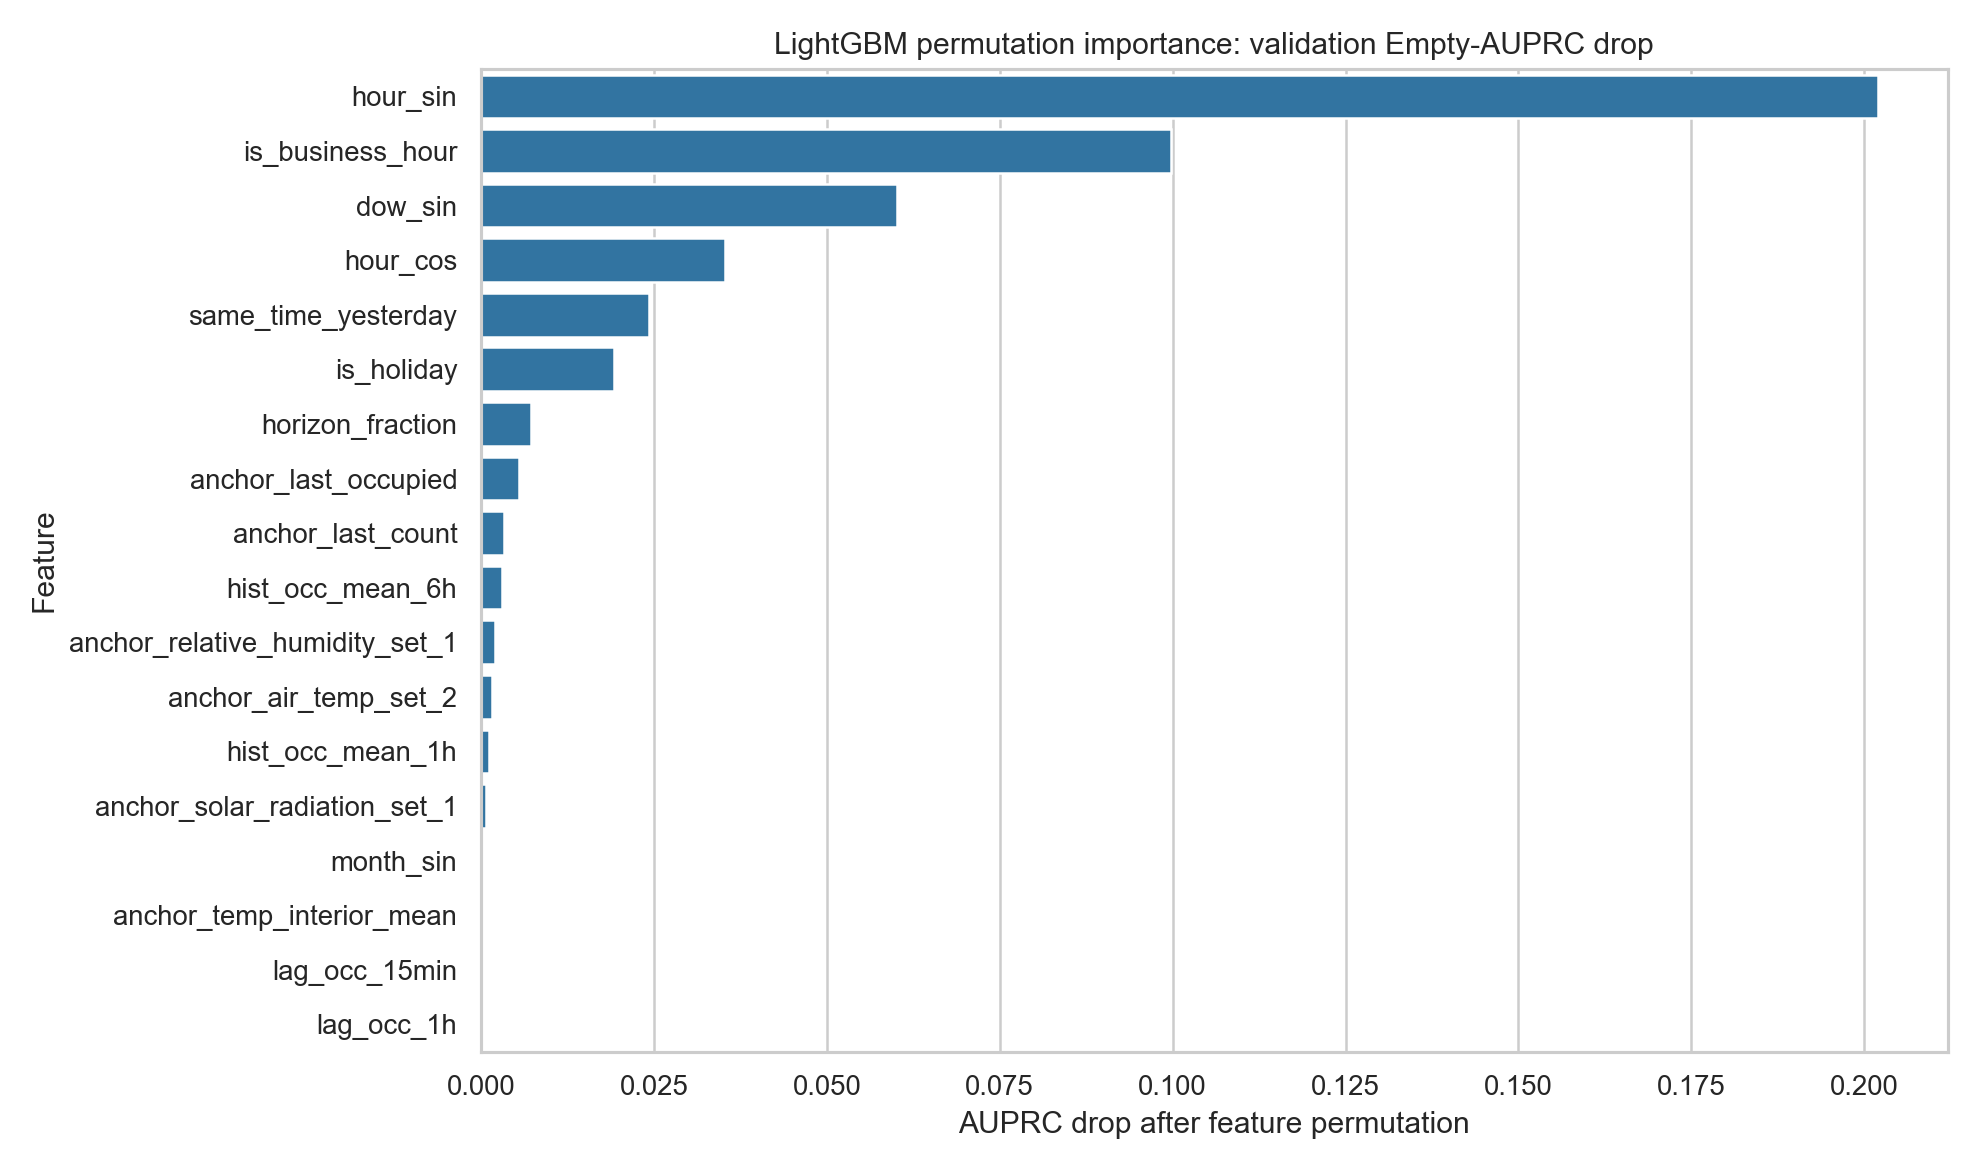

**figures/horizon_bucket_empty_auprc.png**

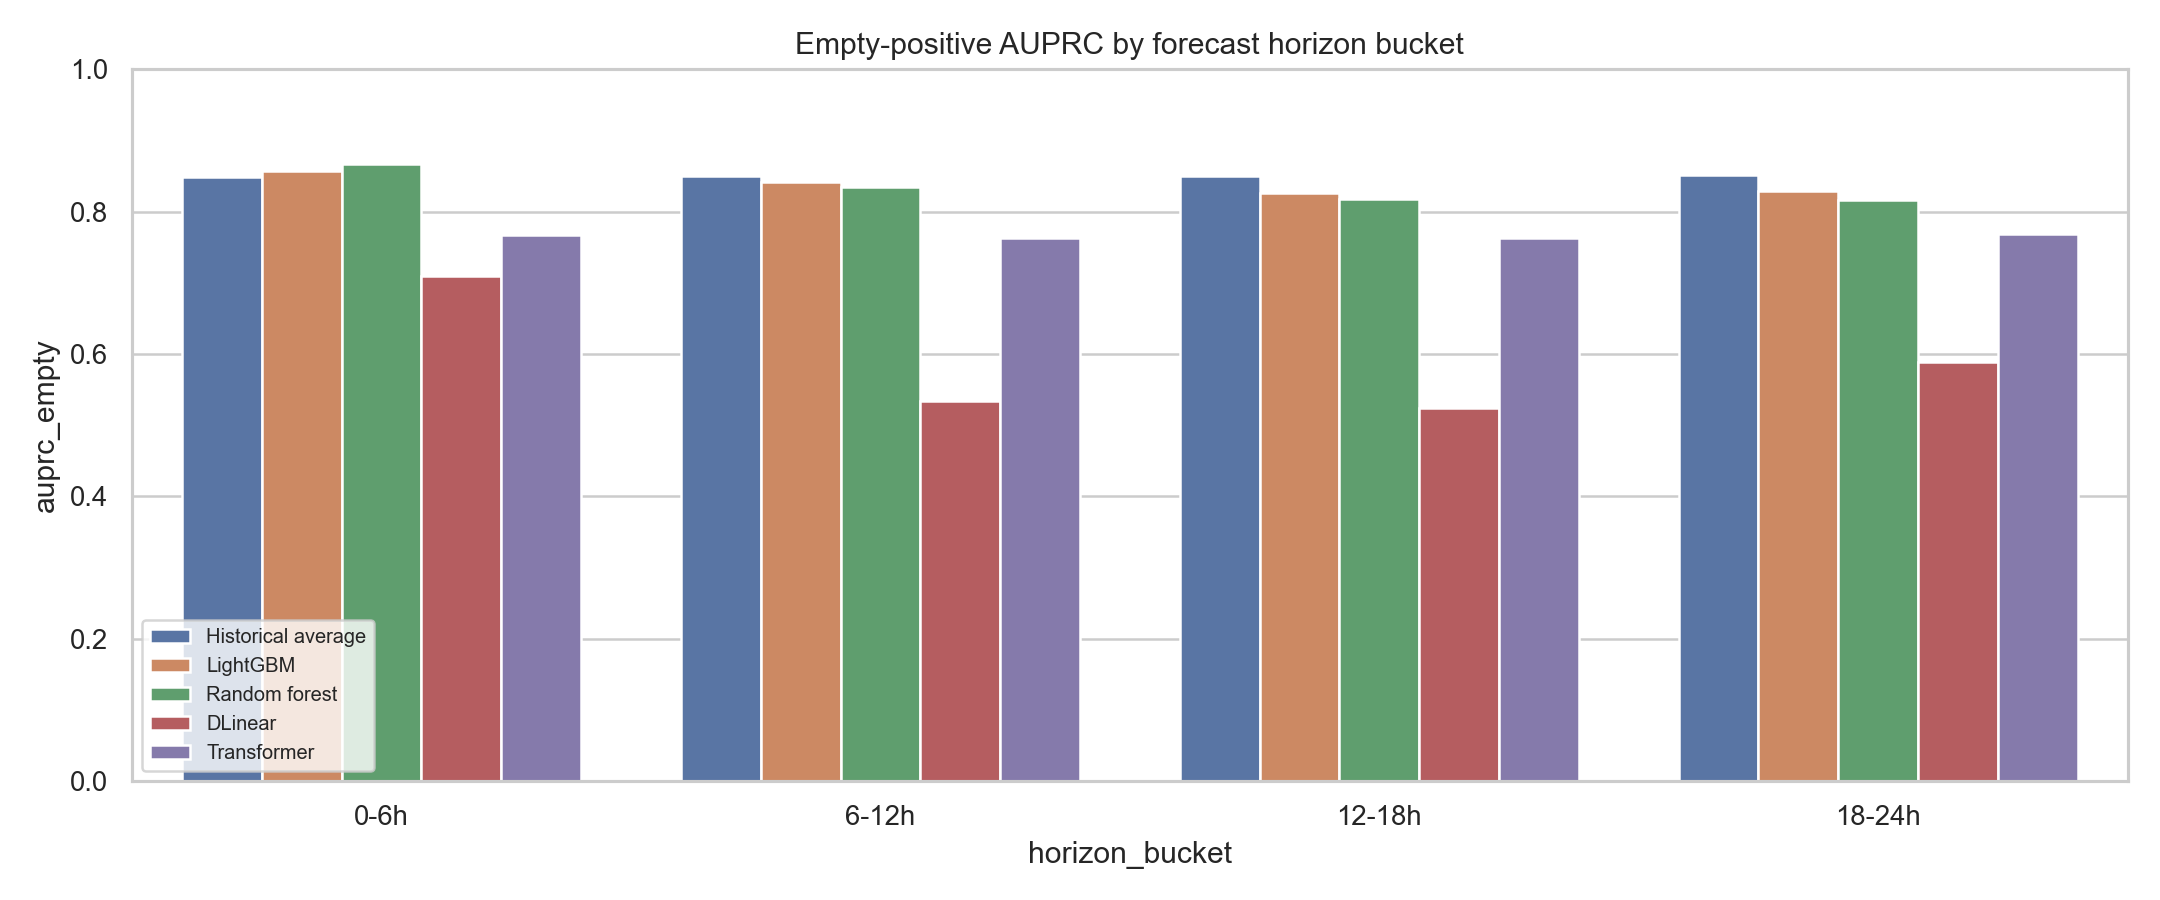

**figures/horizon_empty_auprc.png**

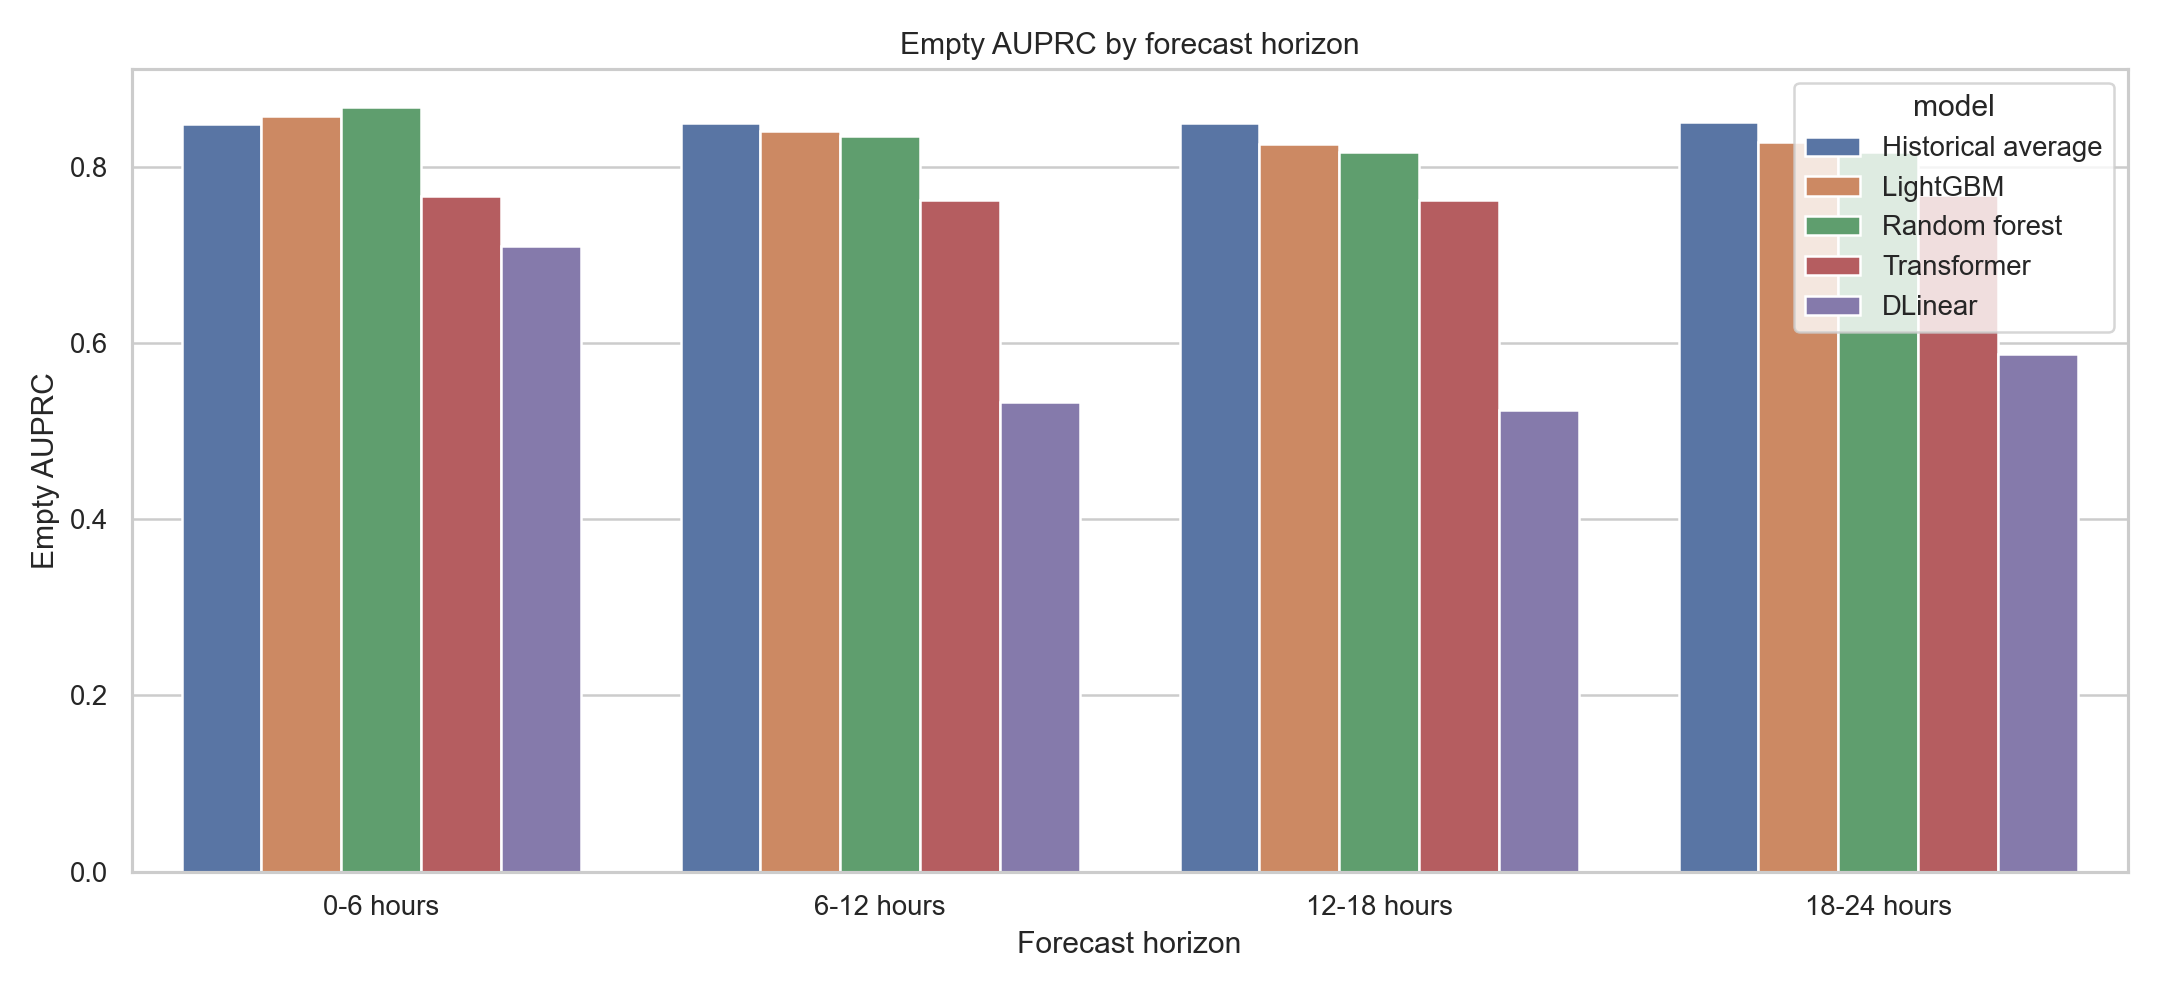

**figures/model_metrics_empty_positive.png**

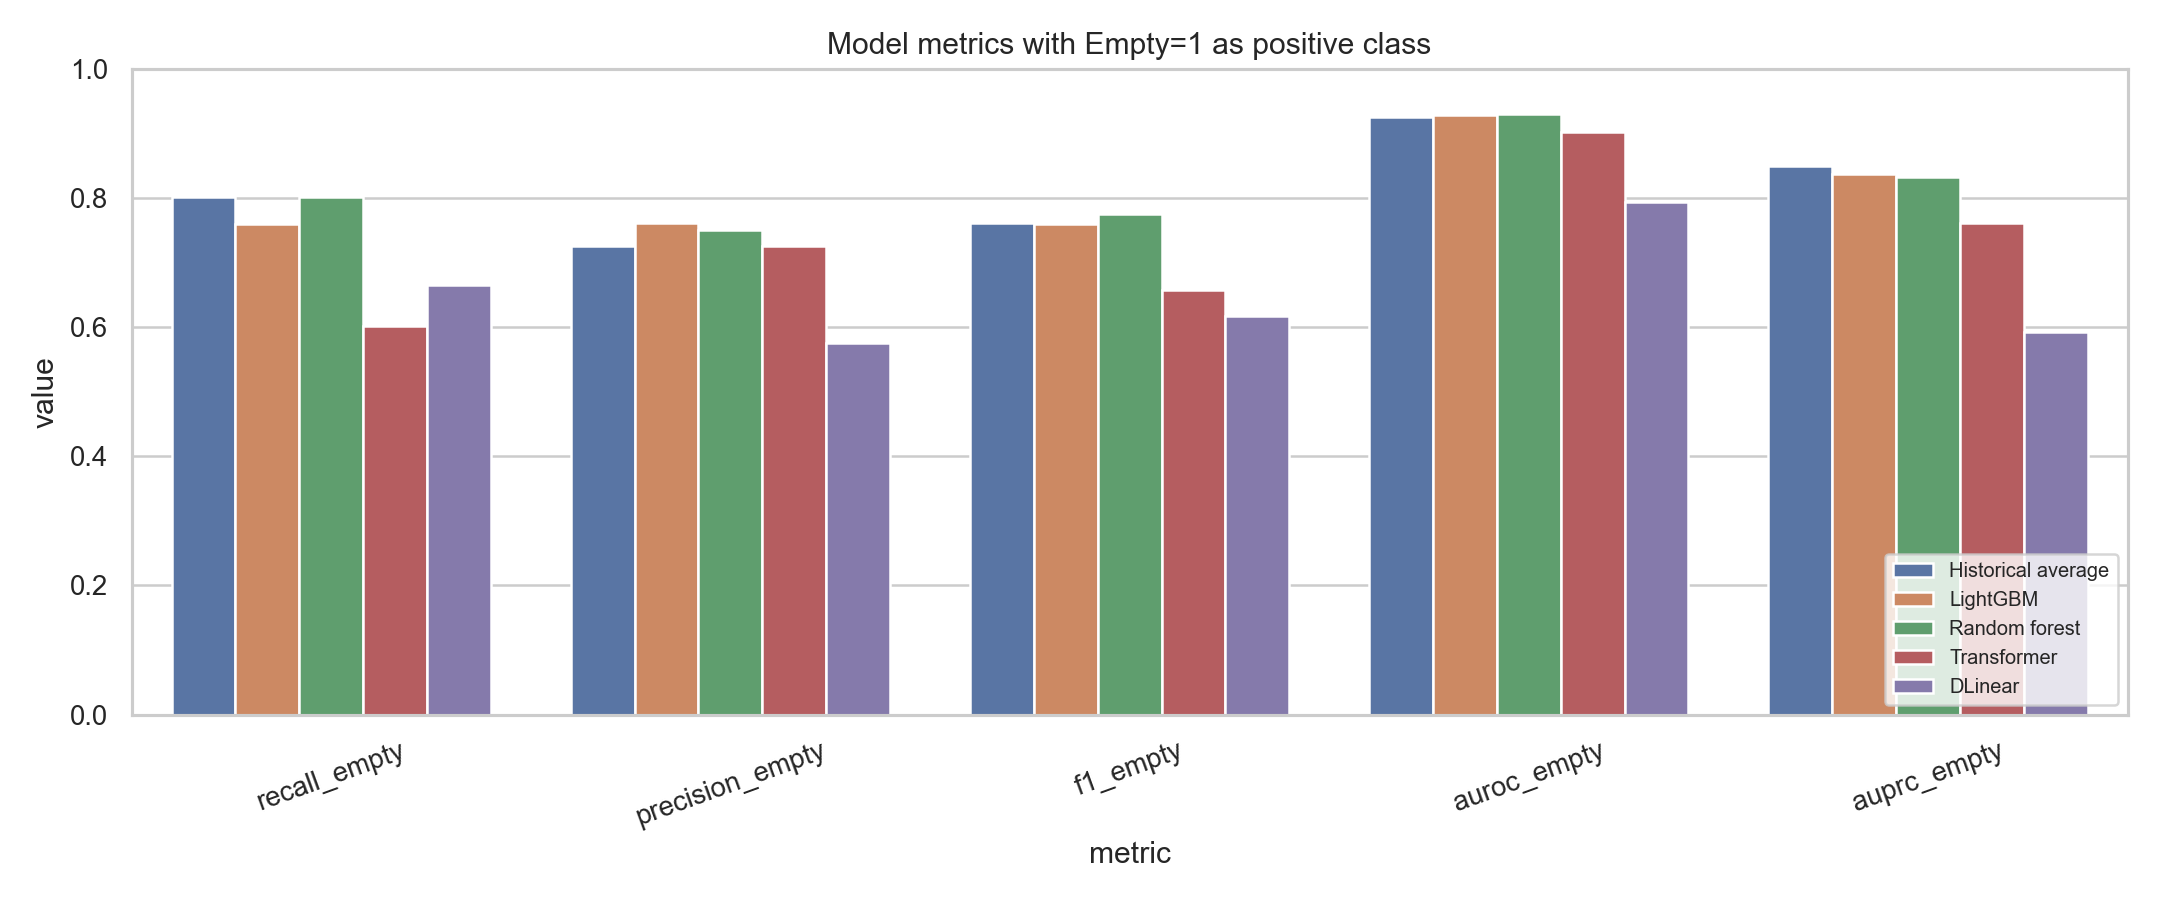

**figures/occupancy_profile_heatmap_pacific.png**

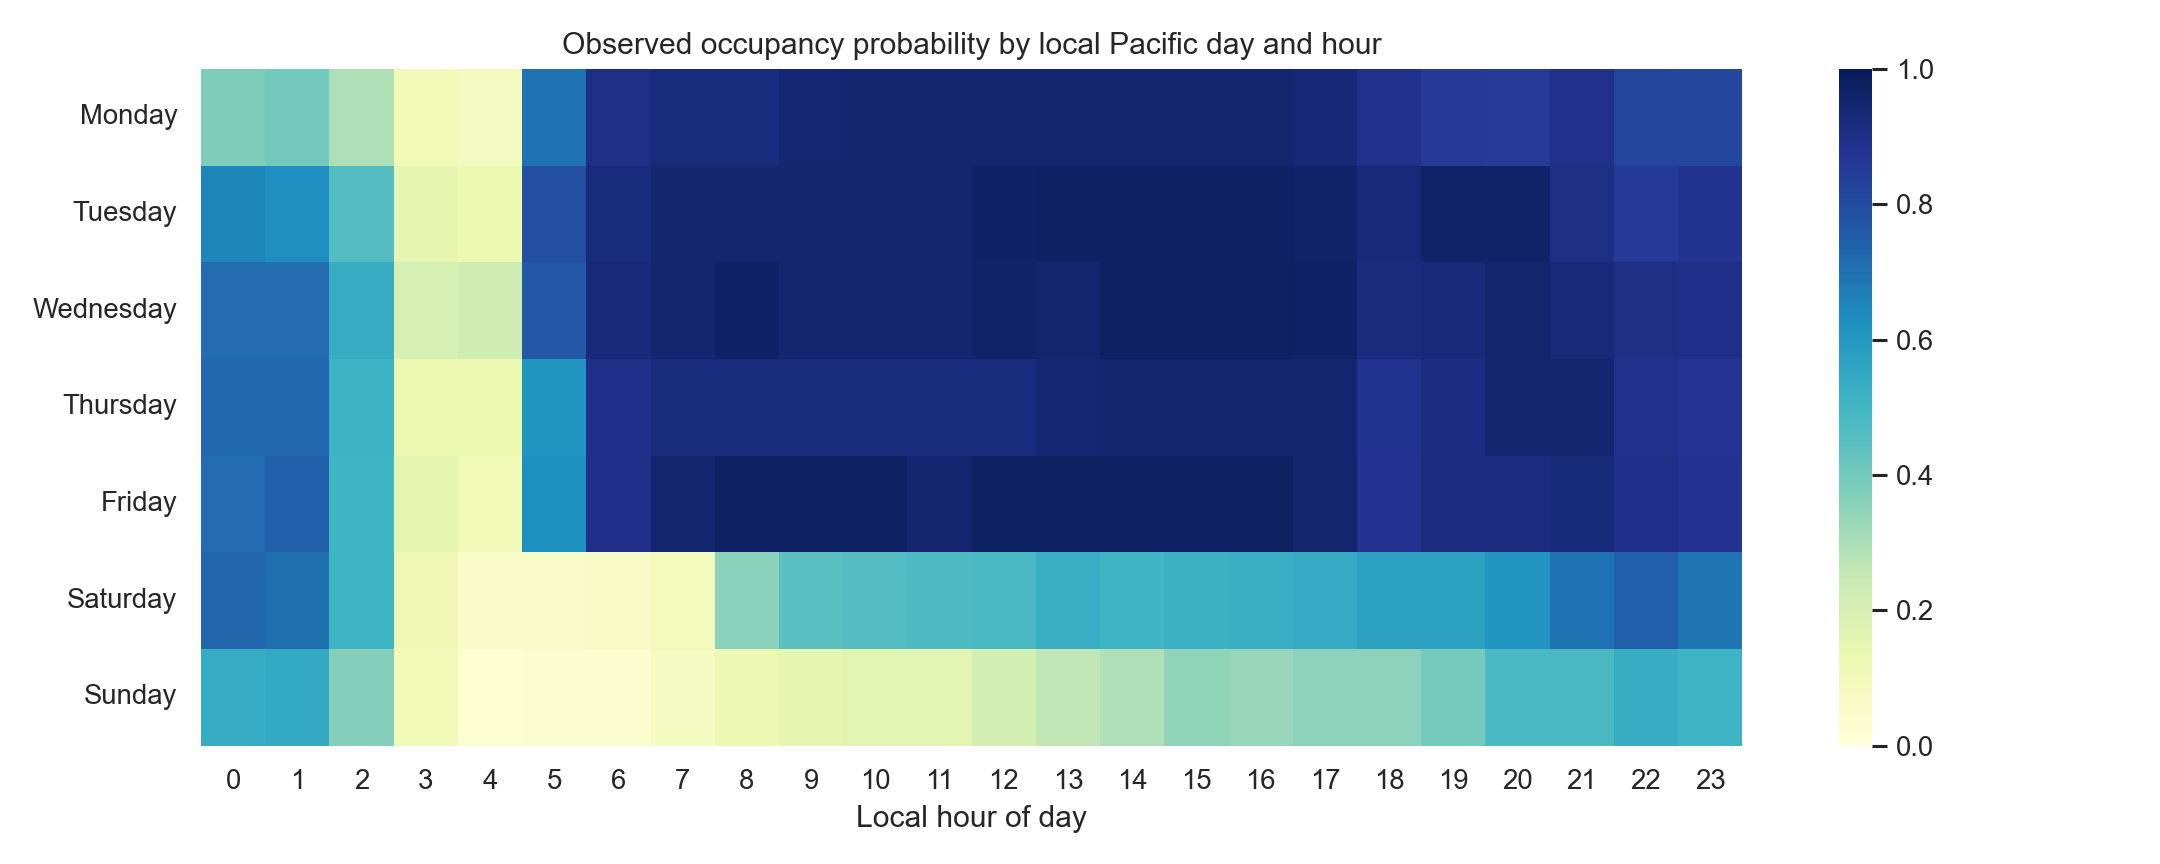

**figures/precision_recall_empty_positive.png**

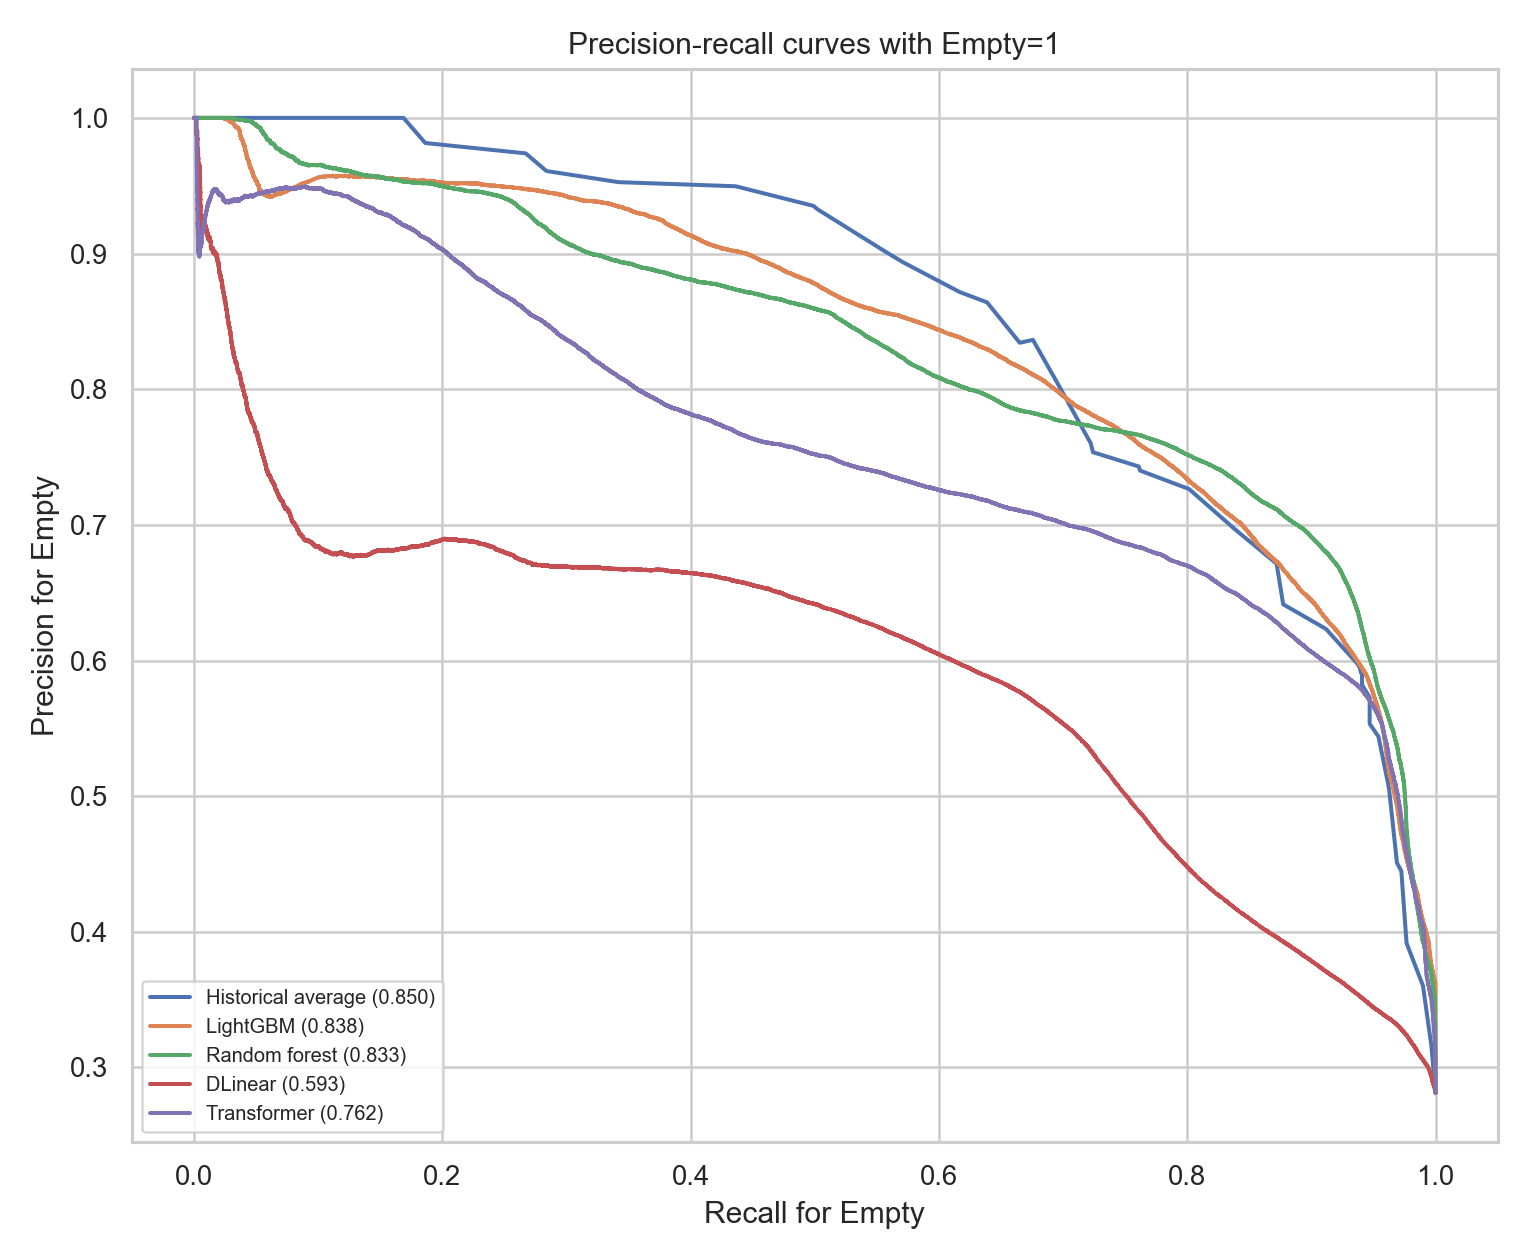

**figures/risk_energy_pareto_frontier.png**

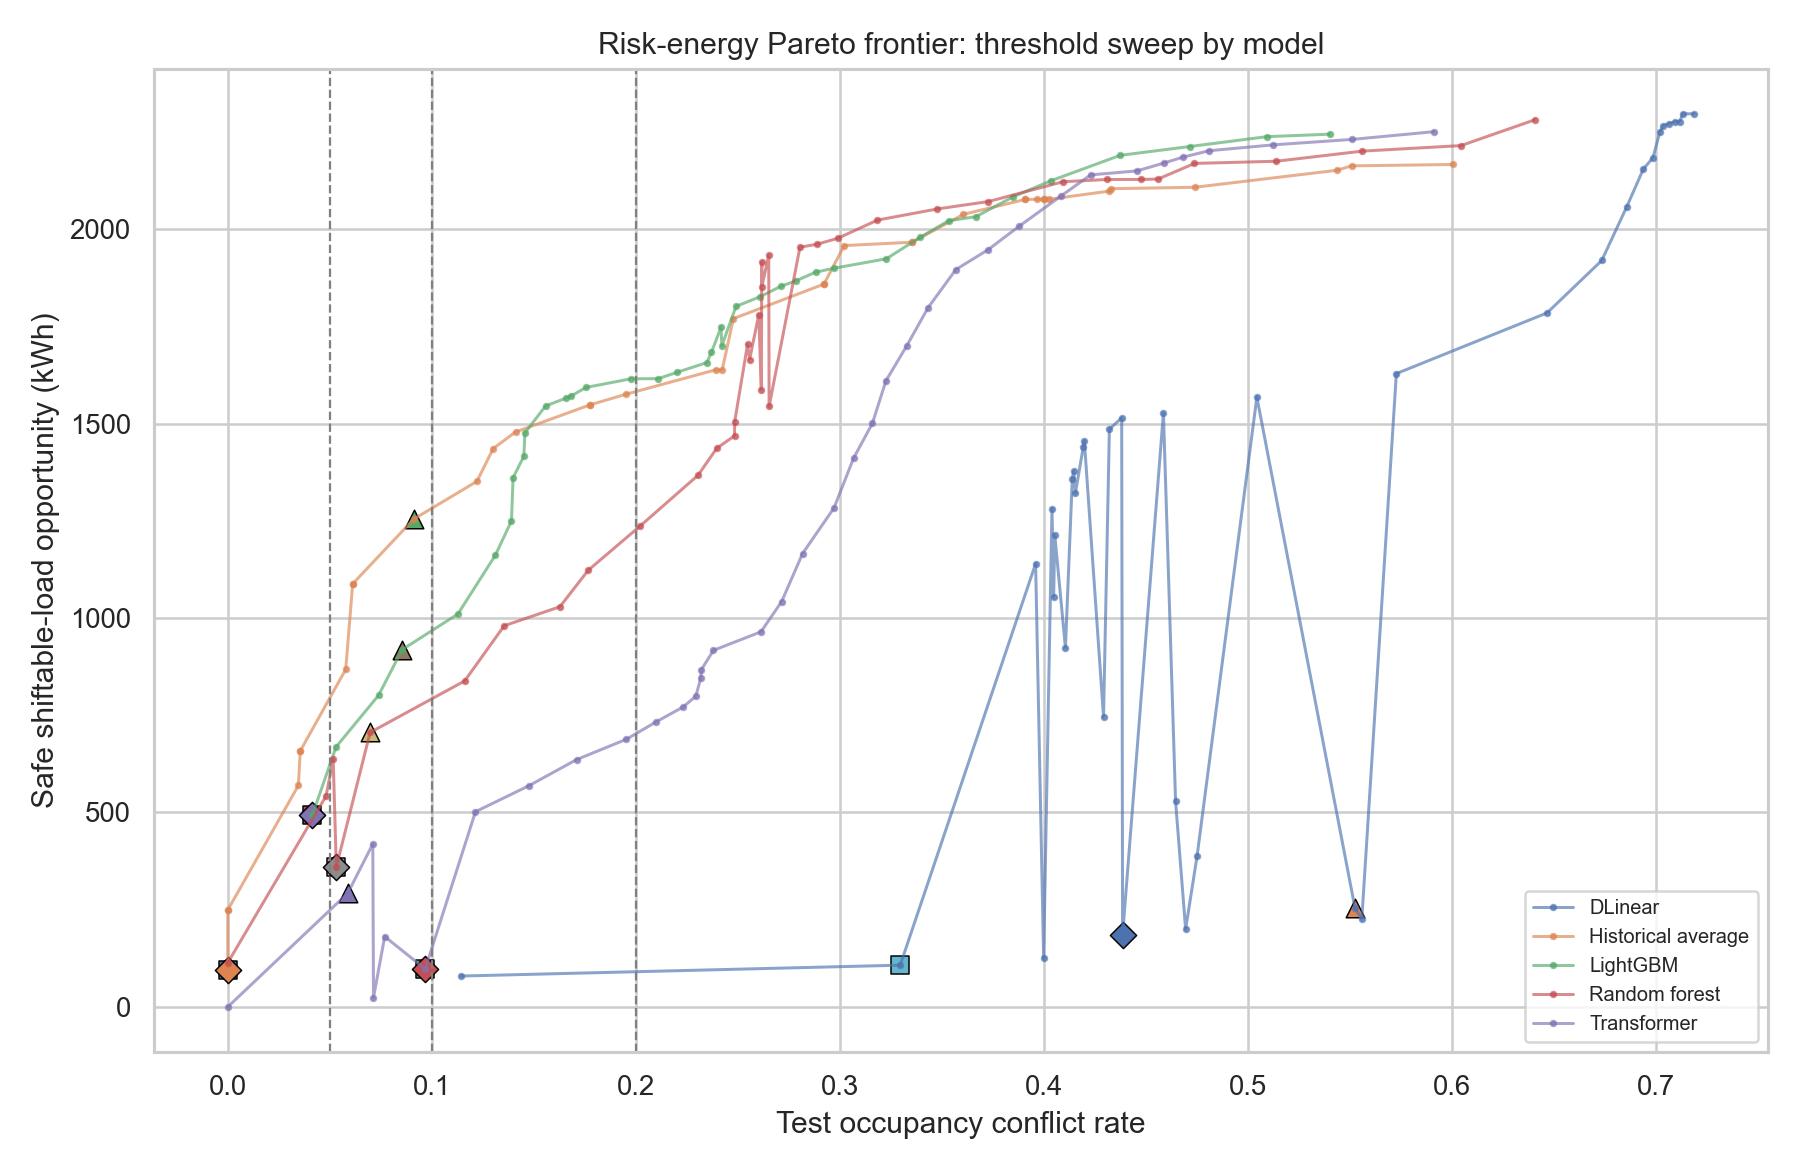

**figures/roc_empty_positive.png**

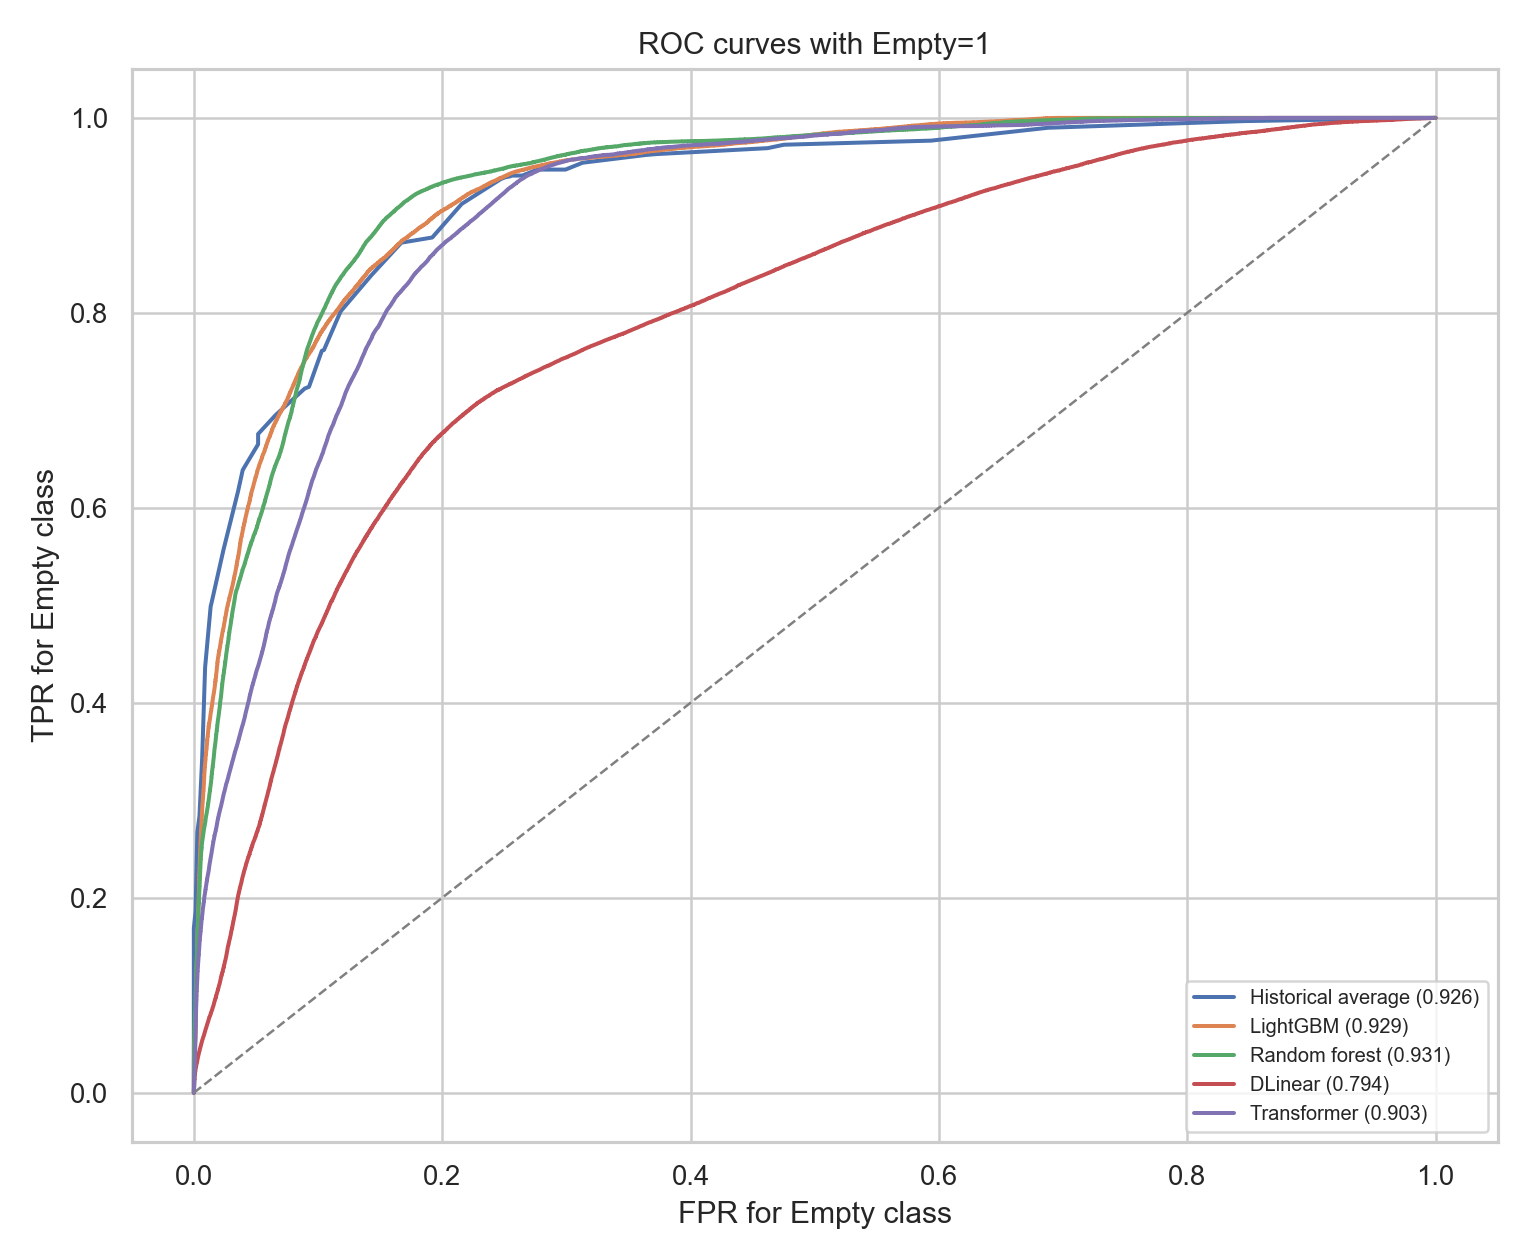

**figures/safe_shiftable_load_by_model.png**

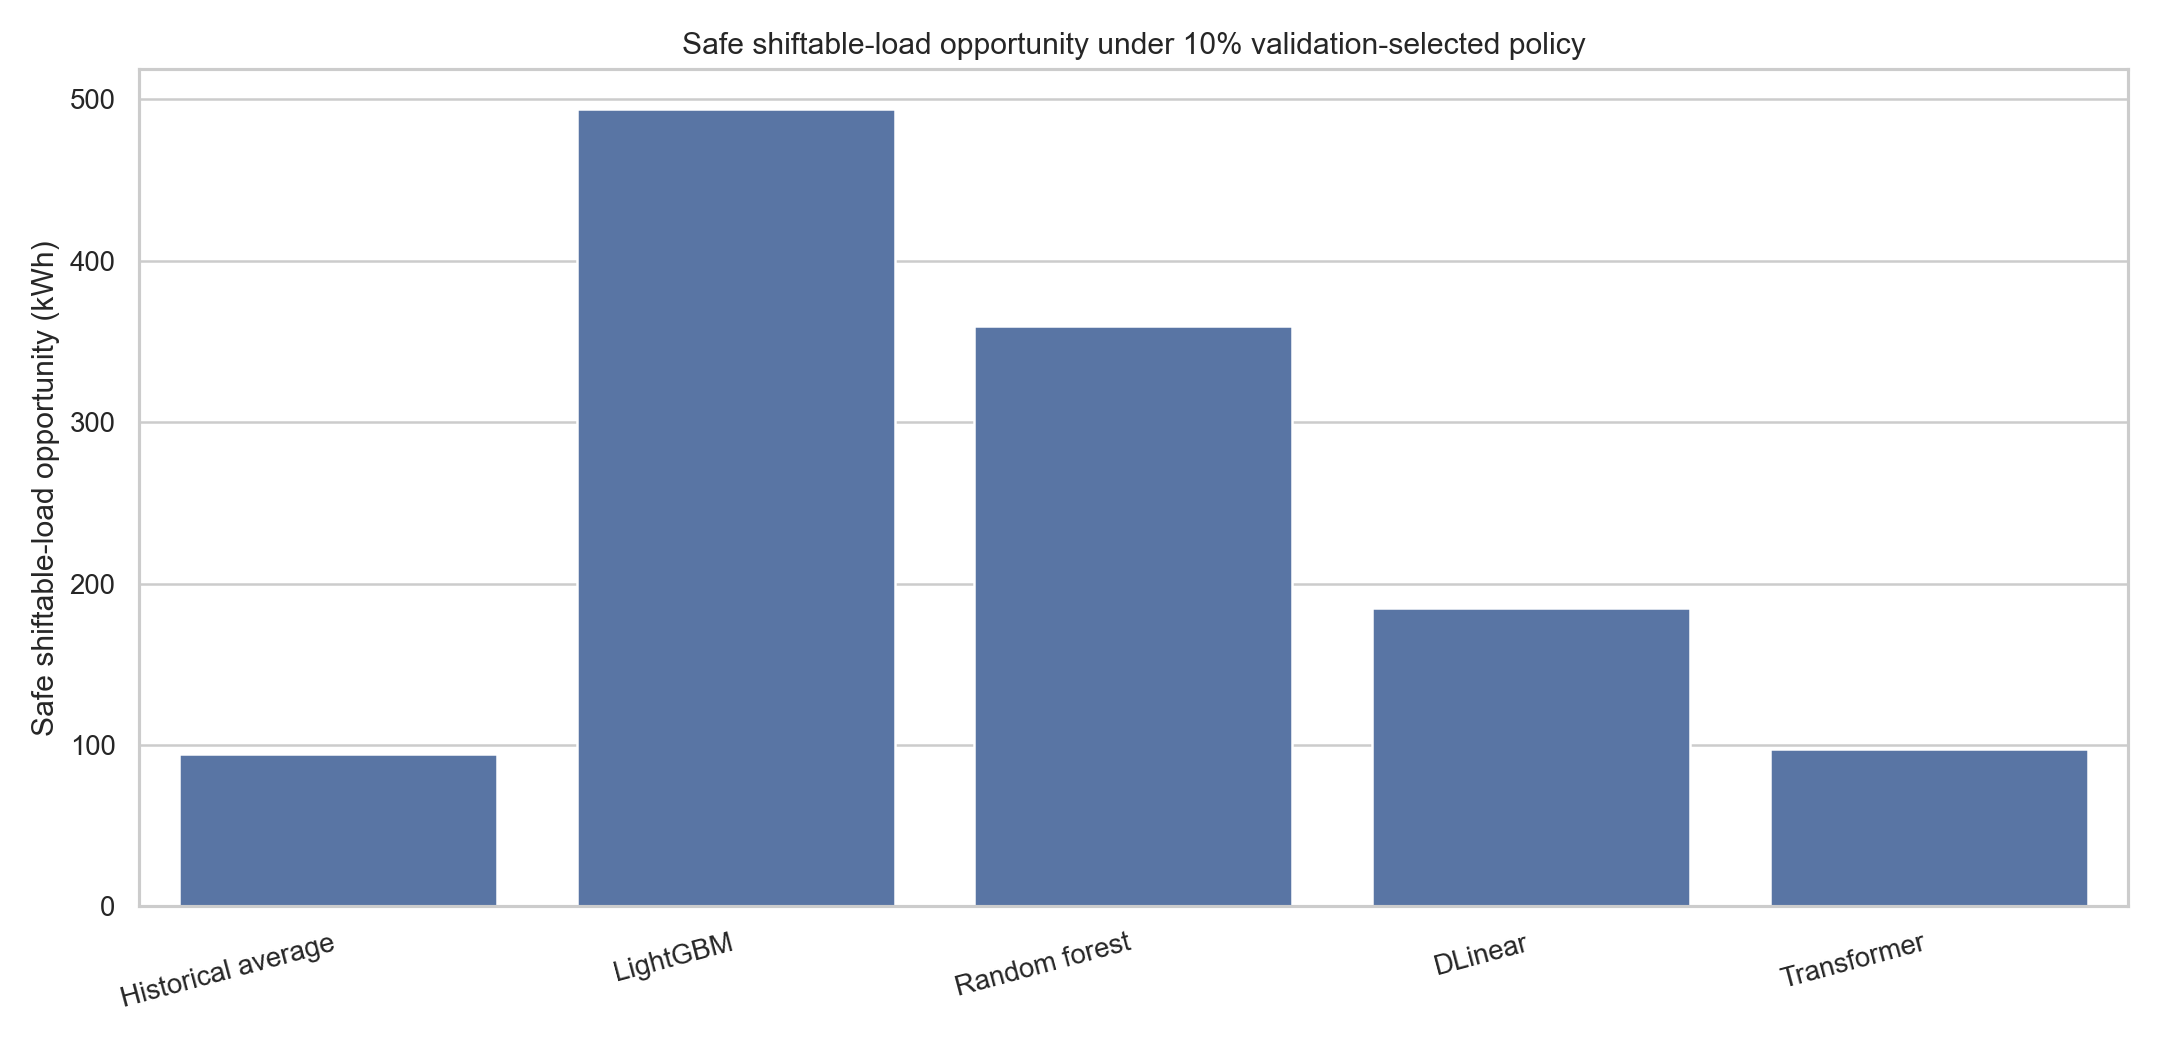

**figures/stable_window_sensitivity.png**

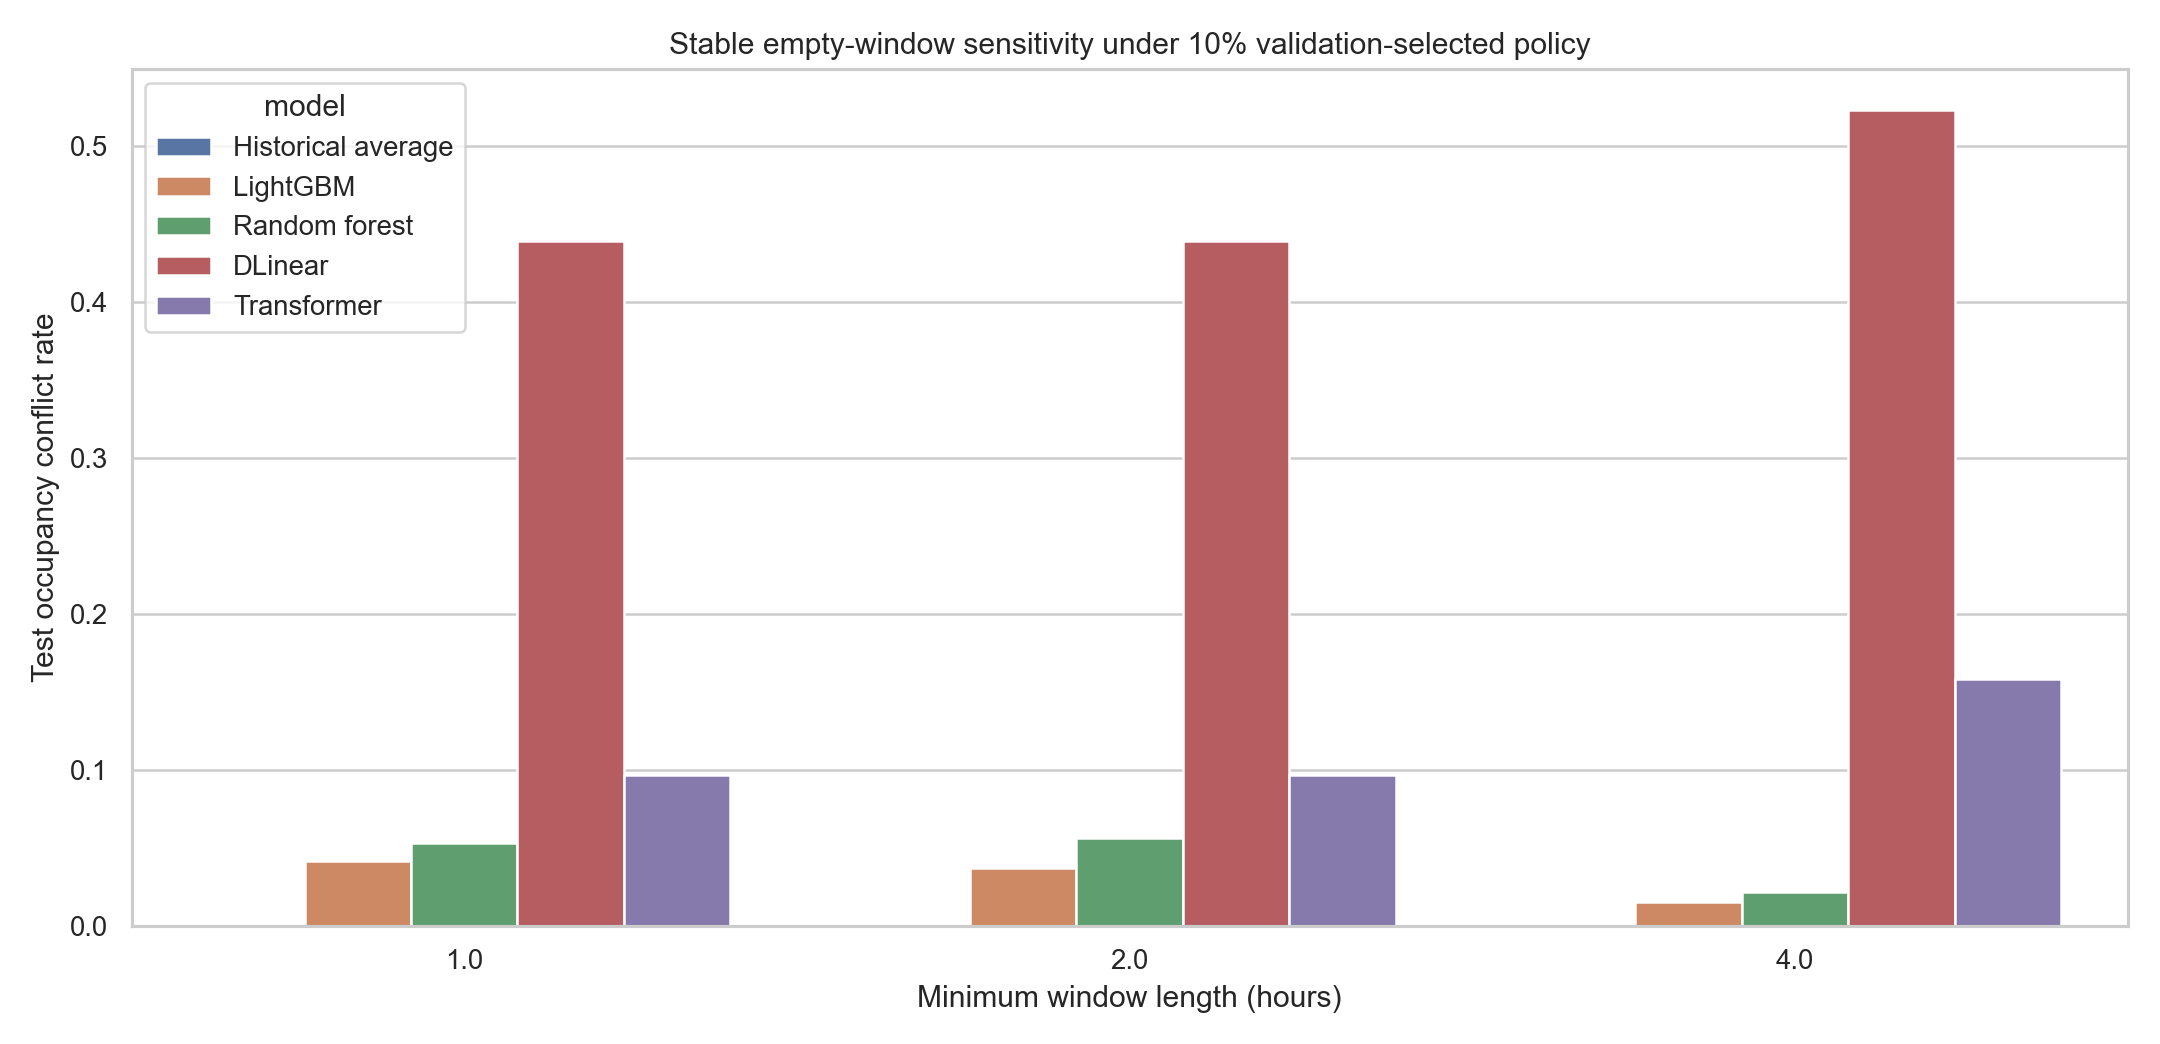

**figures/threshold_policy_occupancy_conflict.png**

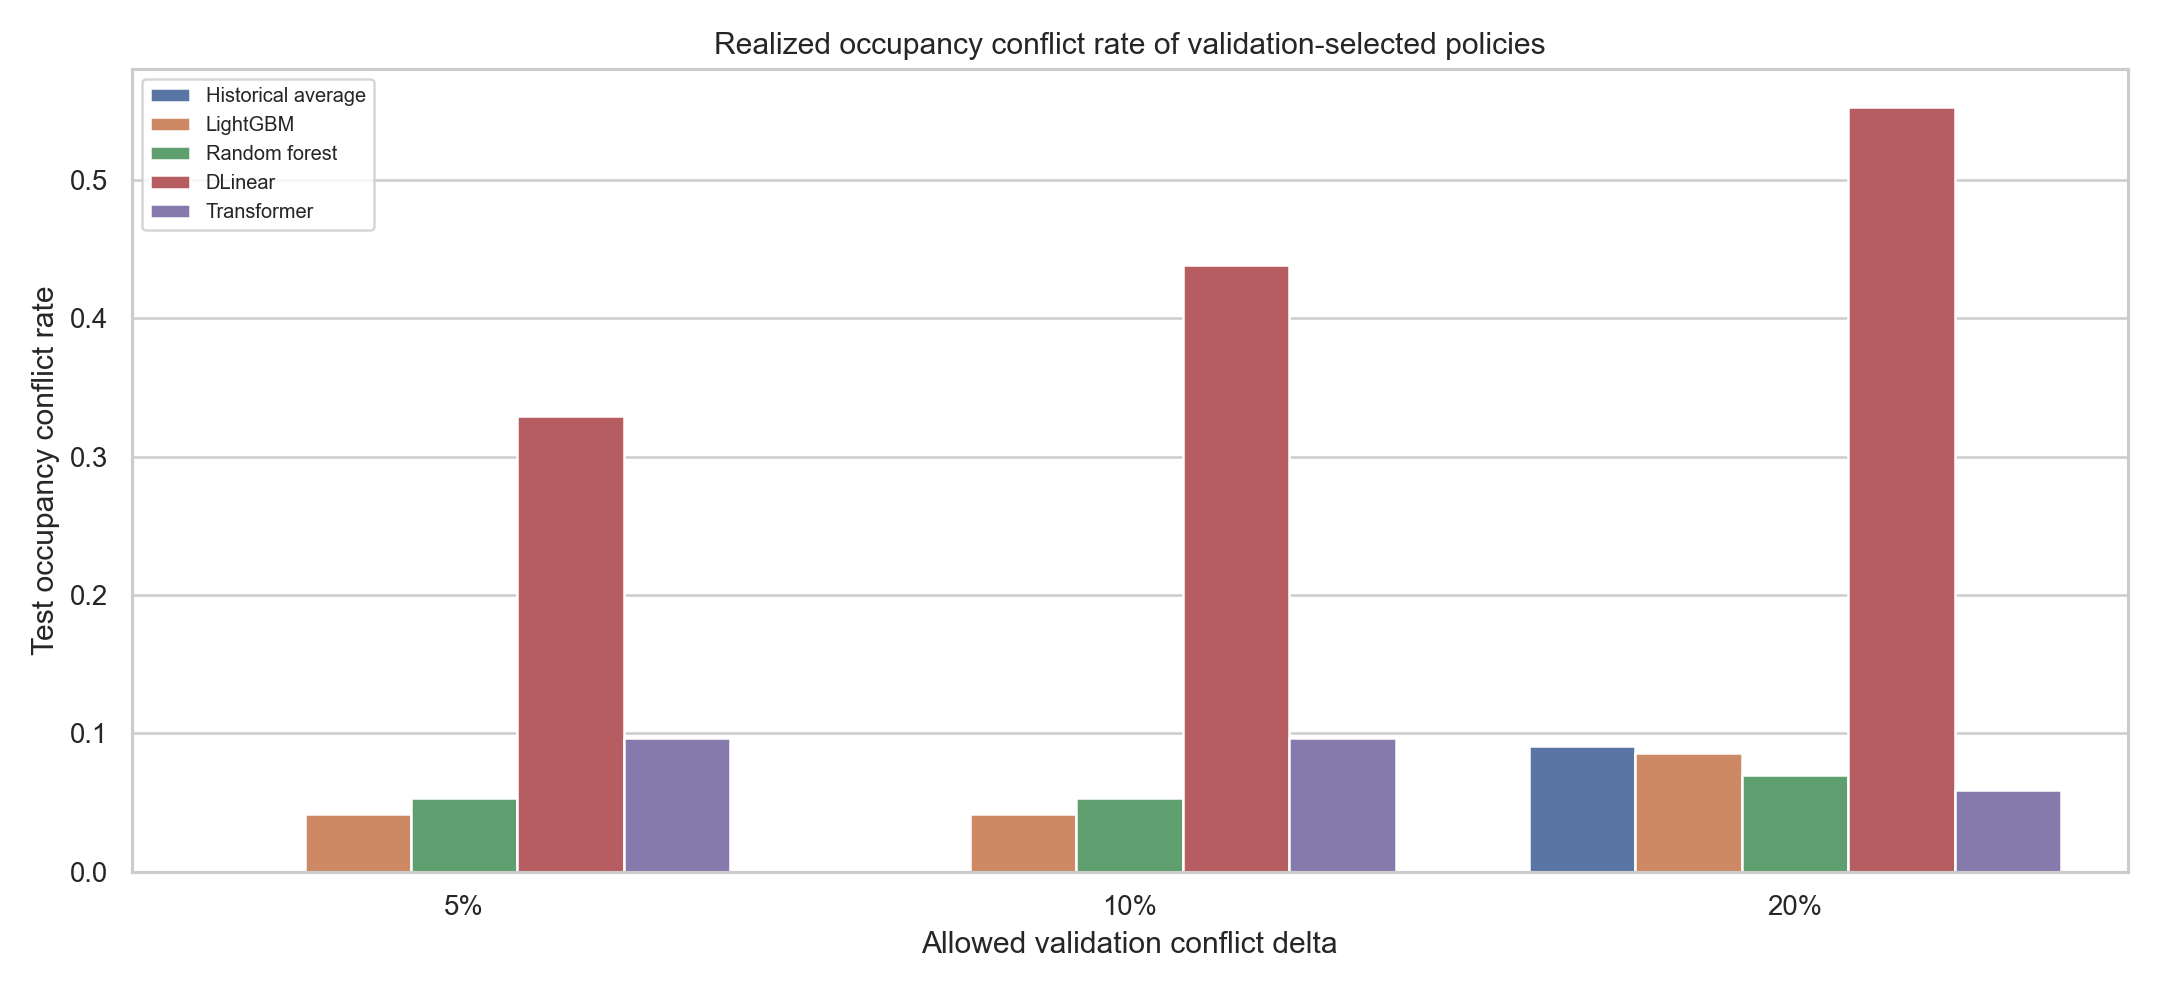

**figures/threshold_policy_safe_opportunity.png**

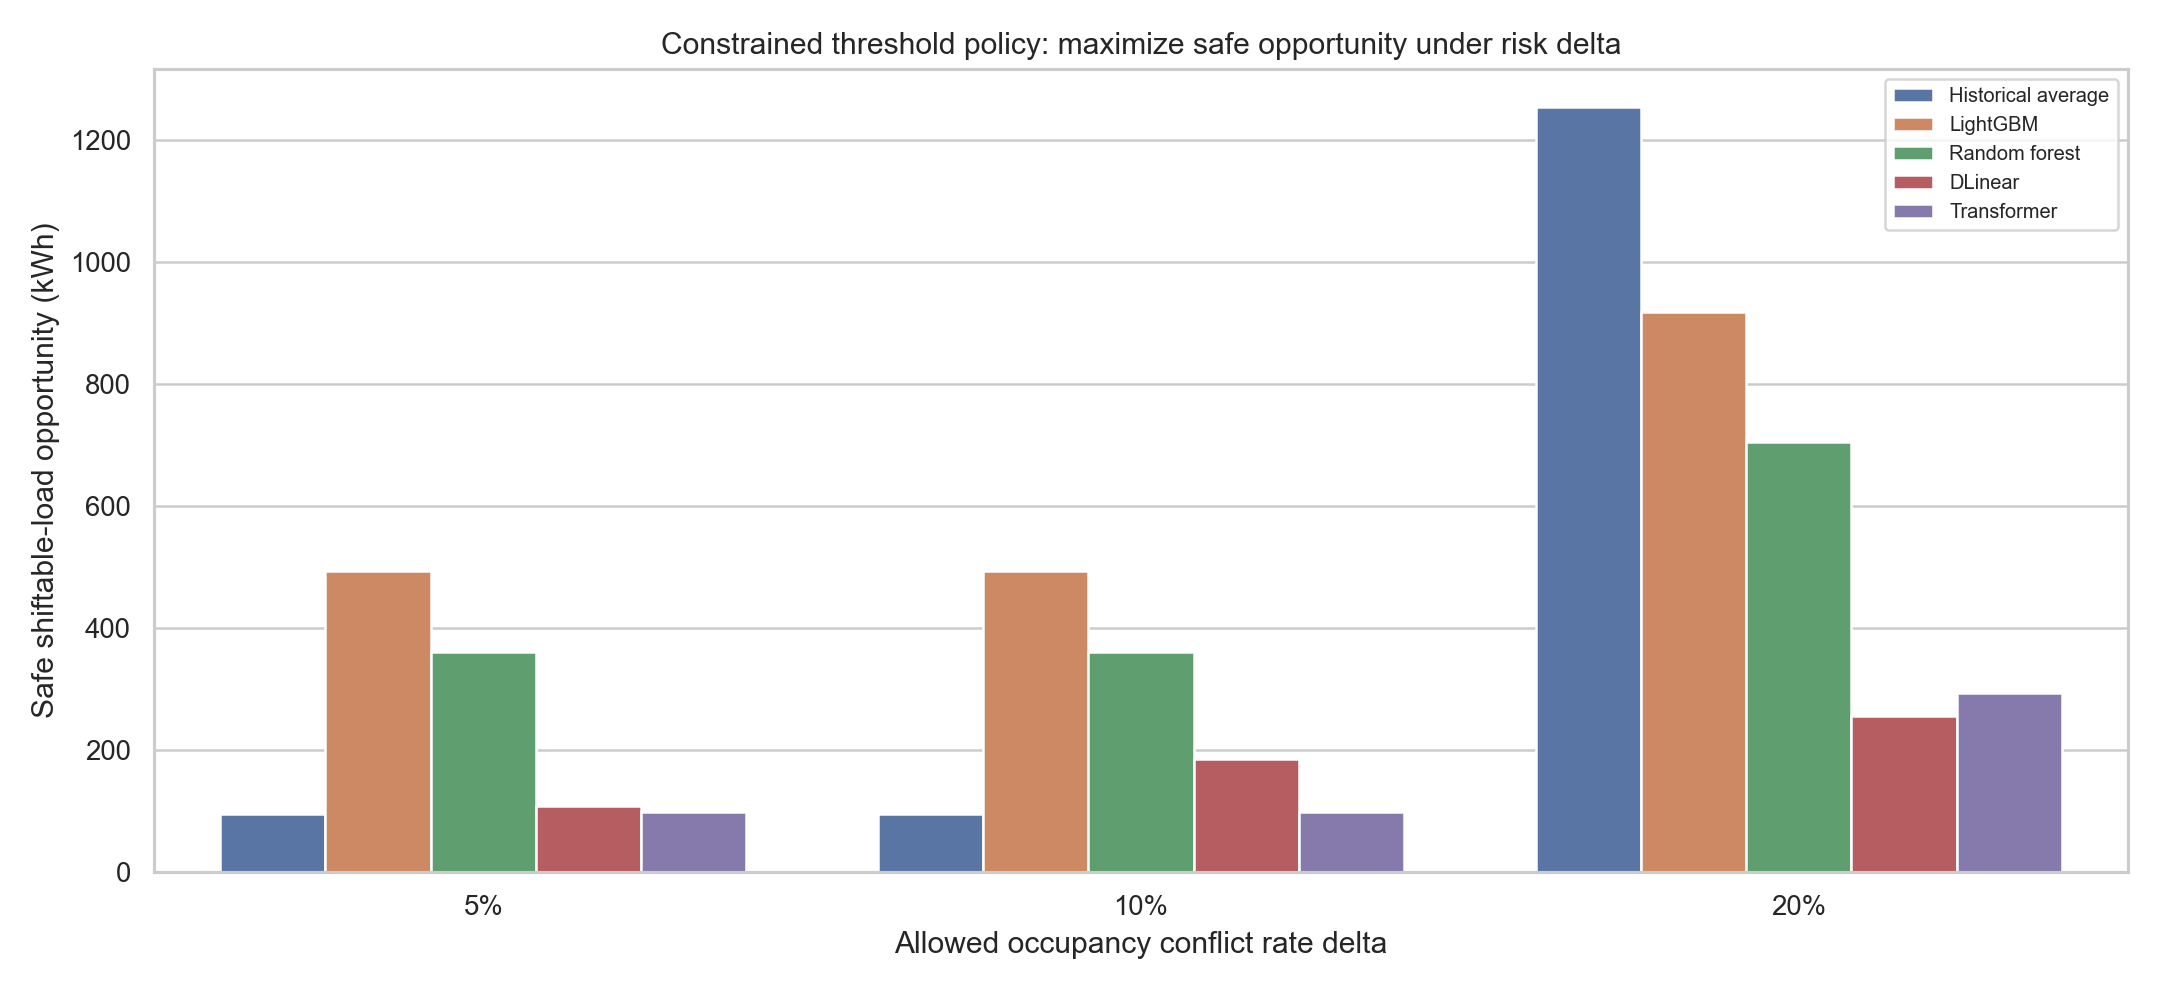

Saved result CSV files:
- results/ablation_results.csv
- results/appendix_model_note.csv
- results/block_bootstrap_confidence_intervals.csv
- results/continuous_empty_window_policy_results_test.csv
- results/continuous_empty_window_threshold_sweep.csv
- results/controllable_load_assumptions.csv
- results/controllable_load_inventory.csv
- results/current_run_manifest.csv
- results/data_split_summary.csv
- results/data_summary.csv
- results/delivery_manifest.csv
- results/empty_reliability_curve_points.csv
- results/energy_risk_pareto_frontier.csv
- results/energy_risk_tradeoff_threshold_sweep.csv
- results/energy_sensitivity_analysis.csv
- results/example_case_days.csv
- results/example_false_positive_recommendation_day.csv
- results/example_irregular_schedule_day.csv
- results/example_missed_opportunity_day.csv
- results/example_successful_recommendation_day.csv
- results/feature_availability_policy.csv
- results/feature_coverage.csv
- results/feature_metadata.csv
- results/forecast_pr

In [8]:
def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.close()

# Local-time occupancy profile.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
profile = df.assign(day=df.index.day_name(), hour=df.index.hour).groupby(['day', 'hour'])['occupied'].mean().unstack('hour').reindex(day_order)
plt.figure(figsize=(12, 4.8))
sns.heatmap(profile, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Observed occupancy probability by local Pacific day and hour')
plt.xlabel('Local hour of day')
plt.ylabel('')
save_fig(Path(cfg.figure_dir) / 'occupancy_profile_heatmap_pacific.png')

# Empty-positive model metrics.
plt.figure(figsize=(12, 5))
metric_long = model_metrics_df.melt(id_vars='model', value_vars=['recall_empty', 'precision_empty', 'f1_empty', 'auroc_empty', 'auprc_empty'], var_name='metric', value_name='value')
sns.barplot(data=metric_long, x='metric', y='value', hue='model')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.title('Model metrics with Empty=1 as positive class')
plt.legend(loc='lower right', fontsize=8)
save_fig(Path(cfg.figure_dir) / 'model_metrics_empty_positive.png')

# Horizon buckets using Empty=1.
bucket_defs = [(1, 24, '0-6h'), (25, 48, '6-12h'), (49, 72, '12-18h'), (73, 96, '18-24h')]
bucket_rows = []
for name, prob in predictions.items():
    for start, end, label in bucket_defs:
        idx = np.arange(start - 1, end)
        yh = y_test[:, idx].ravel().astype(int)
        ph = prob[:, idx].ravel()
        row = empty_model_metrics(name, yh.reshape(-1, 1), ph.reshape(-1, 1))
        row['horizon_bucket'] = label
        bucket_rows.append(row)
horizon_bucket_metrics_df = pd.DataFrame(bucket_rows)
horizon_bucket_metrics_df.to_csv(Path(cfg.result_dir) / 'horizon_bucket_metrics_empty_positive.csv', index=False, encoding='utf-8-sig')
plt.figure(figsize=(12, 5))
sns.barplot(data=horizon_bucket_metrics_df, x='horizon_bucket', y='auprc_empty', hue='model')
plt.ylim(0, 1)
plt.title('Empty-positive AUPRC by forecast horizon bucket')
plt.legend(fontsize=8, loc='lower left')
save_fig(Path(cfg.figure_dir) / 'horizon_bucket_empty_auprc.png')

# Energy-risk threshold sweep and Pareto frontier.
pareto_rows = []
plt.figure(figsize=(10, 6.5))
for model, part in test_sweep_df.groupby('model'):
    part = part.sort_values('occupancy_conflict_rate')
    plt.plot(part['occupancy_conflict_rate'], part['safe_shiftable_load_opportunity_kwh'], marker='o', markersize=2.5, linewidth=1.2, alpha=0.35, label=f'{model} sweep')
    frontier = part.loc[part['safe_shiftable_load_opportunity_kwh'].cummax() == part['safe_shiftable_load_opportunity_kwh']].copy()
    frontier['pareto_frontier'] = True
    pareto_rows.append(frontier)
    plt.plot(frontier['occupancy_conflict_rate'], frontier['safe_shiftable_load_opportunity_kwh'], linewidth=2.2)
for delta in cfg.risk_deltas:
    plt.axvline(delta, color='gray', linestyle='--', linewidth=0.9)
    plt.text(delta + 0.004, plt.ylim()[1] * 0.95, f'{delta:.0%}', fontsize=8)
plt.xlabel('Occupancy conflict rate = false empty recommendations / all recommendations')
plt.ylabel('Safe shiftable-load opportunity (kWh)')
plt.title('Energy-risk tradeoff threshold sweep with Pareto frontiers')
plt.legend(fontsize=7, ncol=2)
save_fig(Path(cfg.figure_dir) / 'energy_risk_tradeoff_pareto.png')
pareto_frontier_df = pd.concat(pareto_rows, ignore_index=True) if pareto_rows else pd.DataFrame()
pareto_frontier_df.to_csv(Path(cfg.result_dir) / 'energy_risk_pareto_frontier.csv', index=False, encoding='utf-8-sig')

# Threshold policy results under constrained optimization.
policy_plot = policy_results_df.copy()
policy_plot['risk_delta_label'] = (policy_plot['risk_delta'] * 100).round().astype(int).astype(str) + '%'
plt.figure(figsize=(12, 5.5))
sns.barplot(data=policy_plot, x='risk_delta_label', y='safe_shiftable_load_opportunity_kwh', hue='model')
plt.title('Constrained threshold policy: maximize safe opportunity under risk delta')
plt.xlabel('Allowed occupancy conflict rate delta')
plt.ylabel('Safe shiftable-load opportunity (kWh)')
plt.legend(fontsize=8)
save_fig(Path(cfg.figure_dir) / 'threshold_policy_safe_opportunity.png')

plt.figure(figsize=(12, 5.5))
sns.barplot(data=policy_plot, x='risk_delta_label', y='occupancy_conflict_rate', hue='model')
plt.title('Realized occupancy conflict rate of validation-selected policies')
plt.xlabel('Allowed validation conflict delta')
plt.ylabel('Test occupancy conflict rate')
plt.legend(fontsize=8)
save_fig(Path(cfg.figure_dir) / 'threshold_policy_occupancy_conflict.png')

# Continuous window and controllable-load sensitivity plots.
window_plot = continuous_window_policy_df[np.isclose(continuous_window_policy_df['risk_delta'], 0.10)].copy()
if len(window_plot):
    plt.figure(figsize=(12, 5.5))
    sns.barplot(data=window_plot, x='minimum_empty_window_hours', y='window_level_occupancy_conflict_rate', hue='model')
    plt.title('Continuous empty-window conflict rate by minimum duration, delta=10% policy')
    plt.xlabel('Minimum empty-window duration (hours)')
    plt.ylabel('Window-level occupancy conflict rate')
    plt.legend(fontsize=8)
    save_fig(Path(cfg.figure_dir) / 'continuous_empty_window_conflict_rate.png')

sens_plot = energy_sensitivity_df[np.isclose(energy_sensitivity_df['risk_delta'], 0.10)].copy()
if len(sens_plot):
    plt.figure(figsize=(13, 6))
    sns.barplot(data=sens_plot, x='load_assumption', y='safe_estimated_opportunity_kwh', hue='model')
    plt.title('Safe estimated opportunity sensitivity under delta=10% policy')
    plt.xlabel('Controllable-load assumption')
    plt.ylabel('Safe estimated opportunity (kWh)')
    plt.xticks(rotation=25, ha='right')
    plt.legend(fontsize=8)
    save_fig(Path(cfg.figure_dir) / 'energy_sensitivity_analysis.png')

# Permutation importance.
if len(permutation_importance_df):
    top_perm = permutation_importance_df.head(18).copy()
    plt.figure(figsize=(11, 6.5))
    sns.barplot(data=top_perm, x='importance', y='feature', color='tab:blue')
    plt.title('LightGBM permutation importance: validation Empty-AUPRC drop')
    plt.xlabel('AUPRC drop after feature permutation')
    plt.ylabel('Feature')
    save_fig(Path(cfg.figure_dir) / 'feature_importance_permutation_empty_auprc.png')

# Calibration / PR / ROC curves for Empty=1.
y_empty_flat = 1 - y_test.ravel().astype(int)

reliability_rows = []
plt.figure(figsize=(8.5, 7))
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='perfect calibration')
for name, prob in predictions.items():
    p_empty = np.clip(1.0 - prob.ravel(), 1e-6, 1 - 1e-6)
    frac_pos, mean_pred = calibration_curve(y_empty_flat, p_empty, n_bins=10, strategy='quantile')
    for bin_id, (mp, fp) in enumerate(zip(mean_pred, frac_pos), start=1):
        reliability_rows.append({'model': name, 'positive_class': 'empty', 'bin': bin_id, 'mean_predicted_empty_probability': mp, 'observed_empty_fraction': fp})
    plt.plot(mean_pred, frac_pos, marker='o', linewidth=1.5, label=name)
plt.xlabel('Mean predicted empty probability')
plt.ylabel('Observed empty fraction')
plt.title('Reliability curve with Empty=1')
plt.legend(fontsize=8, loc='upper left')
save_fig(Path(cfg.figure_dir) / 'empty_reliability_curve.png')
empty_reliability_df = pd.DataFrame(reliability_rows)
empty_reliability_df.to_csv(Path(cfg.result_dir) / 'empty_reliability_curve_points.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(8.5, 7))
for name, prob in predictions.items():
    p_empty = np.clip(1.0 - prob.ravel(), 1e-6, 1 - 1e-6)
    precision, recall, _ = precision_recall_curve(y_empty_flat, p_empty)
    ap = average_precision_score(y_empty_flat, p_empty)
    plt.plot(recall, precision, linewidth=1.6, label=f'{name} ({ap:.3f})')
plt.xlabel('Recall for Empty')
plt.ylabel('Precision for Empty')
plt.title('Precision-recall curves with Empty=1')
plt.legend(fontsize=8, loc='lower left')
save_fig(Path(cfg.figure_dir) / 'precision_recall_empty_positive.png')

plt.figure(figsize=(8.5, 7))
for name, prob in predictions.items():
    p_empty = np.clip(1.0 - prob.ravel(), 1e-6, 1 - 1e-6)
    fpr, tpr, _ = roc_curve(y_empty_flat, p_empty)
    auc = roc_auc_score(y_empty_flat, p_empty)
    plt.plot(fpr, tpr, linewidth=1.6, label=f'{name} ({auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
plt.xlabel('FPR for Empty class')
plt.ylabel('TPR for Empty class')
plt.title('ROC curves with Empty=1')
plt.legend(fontsize=8, loc='lower right')
save_fig(Path(cfg.figure_dir) / 'roc_empty_positive.png')

# Four non-cherry-picked case-study days selected algorithmically.
best_daily_pred = predictions[best_model][test_daily_idx]
best_daily_y = y_test[test_daily_idx]
best_daily_empty_prob = 1.0 - best_daily_pred
best_daily_rec = stable_empty_mask_from_prob(best_daily_empty_prob, best_threshold, cfg.stable_empty_min_steps)
case_rows = []
for local_i, global_i in enumerate(test_daily_idx):
    yy = best_daily_y[local_i].astype(int)
    rec = best_daily_rec[local_i]
    actual_empty = yy == 0
    actual_occ = yy == 1
    conflict_count = int((rec & actual_occ).sum())
    safe_count = int((rec & actual_empty).sum())
    missed_count = int(((~rec) & actual_empty).sum())
    transitions = int(np.abs(np.diff(yy)).sum())
    case_rows.append({
        'daily_local_index': local_i,
        'test_anchor_index': int(global_i),
        'anchor_time': df.index[splits['test'][global_i]],
        'safe_count': safe_count,
        'conflict_count': conflict_count,
        'missed_count': missed_count,
        'recommendation_count': int(rec.sum()),
        'actual_empty_count': int(actual_empty.sum()),
        'transitions': transitions,
    })
case_df = pd.DataFrame(case_rows)
case_choices = []
valid_success = case_df[(case_df['safe_count'] > 0) & (case_df['conflict_count'] == 0)]
if len(valid_success):
    case_choices.append(('successful_recommendation_day', valid_success.sort_values('safe_count', ascending=False).iloc[0]))
else:
    case_choices.append(('successful_recommendation_day', case_df.sort_values(['safe_count', 'conflict_count'], ascending=[False, True]).iloc[0]))
case_choices.append(('false_positive_recommendation_day', case_df.sort_values(['conflict_count', 'recommendation_count'], ascending=False).iloc[0]))
case_choices.append(('missed_opportunity_day', case_df.sort_values(['missed_count', 'actual_empty_count'], ascending=False).iloc[0]))
case_choices.append(('irregular_schedule_day', case_df.sort_values(['transitions', 'actual_empty_count'], ascending=False).iloc[0]))

chosen_rows = []
for label, row in case_choices:
    chosen = row.to_dict()
    chosen['case_type'] = label
    chosen_rows.append(chosen)
case_choice_df = pd.DataFrame(chosen_rows)
case_choice_df.to_csv(Path(cfg.result_dir) / 'example_case_days.csv', index=False, encoding='utf-8-sig')

for label, row in case_choices:
    global_i = int(row['test_anchor_index'])
    pos = future_positions(np.array([splits['test'][global_i]]), cfg.horizon_steps)[0]
    dates = df.index.take(pos)
    actual = df['occupied'].to_numpy()[pos]
    empty_prob = 1.0 - predictions[best_model][global_i]
    rec = stable_empty_mask_from_prob(empty_prob.reshape(1, -1), best_threshold, cfg.stable_empty_min_steps)[0]
    example = pd.DataFrame({'date': dates, 'actual_occupied': actual, 'predicted_empty_probability': empty_prob, 'recommend_empty_stable': rec})
    example.to_csv(Path(cfg.result_dir) / f'example_{label}.csv', index=False, encoding='utf-8-sig')
    fig, ax = plt.subplots(figsize=(13, 4.8))
    ax.step(example['date'], example['predicted_empty_probability'], where='post', label=f'{best_model} predicted empty probability')
    ax.fill_between(example['date'], 0, example['actual_occupied'], step='post', alpha=0.22, label='actual occupied')
    for i, is_rec in enumerate(rec):
        if is_rec:
            start = example['date'].iloc[i]
            ax.axvspan(start, start + pd.Timedelta(cfg.freq), color='tab:green', alpha=0.12)
    ax.axhline(best_threshold, color='tab:red', linestyle='--', linewidth=1, label='risk-delta 10% threshold')
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(label.replace('_', ' ').title())
    ax.set_ylabel('Probability / occupancy')
    ax.legend(loc='upper right')
    save_fig(Path(cfg.figure_dir) / f'example_forecast_{label}.png')

figure_files = sorted(Path(cfg.figure_dir).glob('*.png'))
display(Markdown('## Saved figures'))
for p in figure_files:
    display(Markdown(f'**{p.as_posix()}**'))
    display(Image(filename=str(p)))

manifest_rows = []
for folder in [Path(cfg.result_dir), Path(cfg.figure_dir)]:
    for p in sorted(folder.glob('*')):
        if p.is_file():
            manifest_rows.append({'folder': folder.as_posix(), 'file': p.name, 'relative_path': p.as_posix(), 'bytes': p.stat().st_size, 'modified_time': pd.Timestamp.fromtimestamp(p.stat().st_mtime)})
current_run_manifest_df = pd.DataFrame(manifest_rows).sort_values(['folder', 'file'])
current_run_manifest_df.to_csv(Path(cfg.result_dir) / 'current_run_manifest.csv', index=False, encoding='utf-8-sig')

print('Saved result CSV files:')
for p in sorted(Path(cfg.result_dir).glob('*.csv')):
    print('-', p.as_posix())